In [1]:
# pip install statsmodels


In [2]:
# Import dependencies
import gc
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import seaborn as sns
import plotly.express as px

import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from statsmodels.graphics.mosaicplot import mosaic

In [3]:
# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)  # Display only the first 10 rows in output

In [4]:
# df_leads = None  # Clear the DataFrame
# df_opps = None  # Clear the DataFrame
# df_leads2 = None  # Clear the DataFrame
# df_leads2 = None  # Clear the DataFrame
# import gc
# gc.collect()  # Force garbage collection to remove old references

In [5]:
# Load the Salesforce report exports from Excel files
df = pd.read_excel('forYargiAnalysisCAAllOpportunities20241009.xlsx')
SWX2023Revenuedf = pd.read_excel('2023RevenueDataPowerBIforLineChart.xlsx')
SWX2024Revenuedf = pd.read_excel('2024RevenueDataPowerBIforLineChart.xlsx')


In [6]:
print(df.columns)
print(SWX2023Revenuedf.columns)
print(SWX2024Revenuedf.columns)

Index(['OpportunityOwner', 'OpportunityID', 'Opportunity Name', 'AccountName',
       'Type', 'CreatedDate', 'CloseDate', 'CloseDateMinusCreatedDate',
       'LastModifiedDate', 'Stage', 'StageDuration', 'Amount',
       'ExpectedRevenue', 'DaysOverdue', 'Probability', 'ProbabilityCleaned',
       'ForecastCategory', 'OpportunitiesCount', 'OpportunityReference'],
      dtype='object')
Index([     'BusinessUnit', 2023-01-01 00:00:00, 2023-02-01 00:00:00,
       2023-03-01 00:00:00, 2023-04-01 00:00:00, 2023-05-01 00:00:00,
       2023-06-01 00:00:00, 2023-07-01 00:00:00, 2023-08-01 00:00:00,
       2023-09-01 00:00:00, 2023-10-01 00:00:00, 2023-11-01 00:00:00,
       2023-12-01 00:00:00],
      dtype='object')
Index([     'BusinessUnit', 2024-01-01 00:00:00, 2024-02-01 00:00:00,
       2024-03-01 00:00:00, 2024-04-01 00:00:00, 2024-05-01 00:00:00,
       2024-06-01 00:00:00, 2024-07-01 00:00:00, 2024-08-01 00:00:00,
       2024-09-01 00:00:00, 2024-10-01 00:00:00, 2024-11-01 00:00:00,
 

In [7]:
# plt.close('all')  # This closes all active figures to clear the plotting cache

In [8]:
# Convert date columns to datetime format for easier manipulation
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])
df['CloseDate'] = pd.to_datetime(df['CloseDate'])
df['LastModifiedDate'] = pd.to_datetime(df['LastModifiedDate'])

In [9]:
# Total number of opportunities, amount, and expected revenue
total_opps = df['OpportunityID'].nunique()
total_amount = df['Amount'].sum()
total_expected_revenue = df['ExpectedRevenue'].sum()

print(f"Total Opportunities: {total_opps}")
print(f"Total Amount: {total_amount}")
print(f"Total Expected Revenue: {total_expected_revenue}")


Total Opportunities: 4450
Total Amount: 53136931.919999994
Total Expected Revenue: 34030567.085


In [10]:
# Total number of unique opportunities, total amount, and total expected revenue
total_opps = df['OpportunityID'].nunique()
total_amount = df['Amount'].sum()
total_expected_revenue = df['ExpectedRevenue'].sum()

# Calculate total amount per stage
amount_per_stage = df.groupby('Stage')['Amount'].sum().reset_index()

# Display results
print(f"Total Opportunities: {total_opps}")
print(f"Total Amount: ${total_amount:,.0f}")
print(f"Total Expected Revenue: ${total_expected_revenue:,.0f}\n")

print("Total Amount by Stage:")
print(amount_per_stage)


Total Opportunities: 4450
Total Amount: $53,136,932
Total Expected Revenue: $34,030,567

Total Amount by Stage:
                    Stage       Amount
0             Closed Lost  11824649.59
1              Closed Won  28241449.04
2  Evaluation/Negotiation   3237722.56
3                Proposal   4233320.00
4             Prospecting   2544877.05
5              Qualifying   3054913.68


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1554901322.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_grouped, x='Amount', y='Type', palette='OrRd', orient='h')


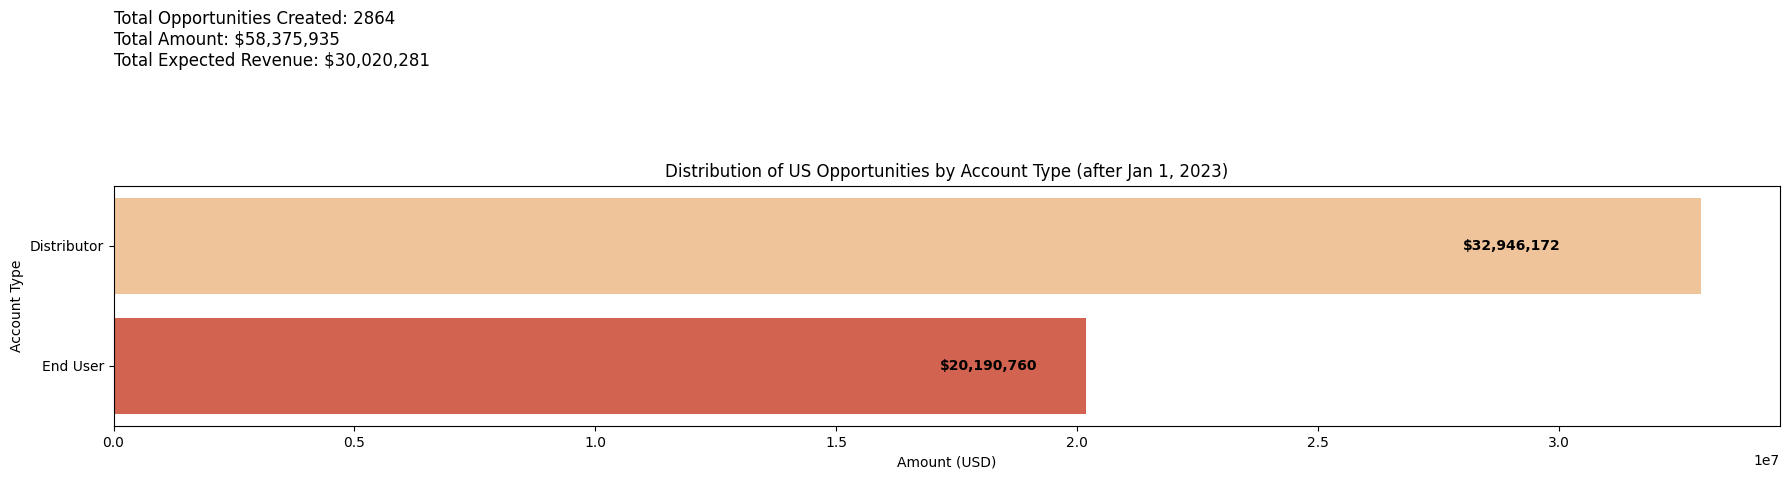

In [11]:
# Group by Type and sum Amount and Expected Revenue
type_grouped = df.groupby('Type')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Plot Total Amount by Account Type with custom colors
plt.figure(figsize=(18, 6))
sns.barplot(data=type_grouped, x='Amount', y='Type', palette='OrRd', orient='h')

# Annotate each bar with its value (including $ sign), positioned inside the bar and using black text
for i, value in enumerate(type_grouped['Amount']):
    plt.text(value * 0.85, i, f'${value:,.0f}', va='center', color='black', fontweight='bold')  # Add $ sign to the formatted value

# Customizing the chart with new axis labels and title
plt.title('Distribution of US Opportunities by Account Type (after Jan 1, 2023)')
plt.xlabel('Amount (USD)')
plt.ylabel('Account Type')
# Adding custom note below the plot
plt.text(0, -1.5, 'Total Opportunities Created: 2864\nTotal Amount: $58,375,935\nTotal Expected Revenue: $30,020,281', 
         fontsize=12, ha='left')

# Adjust layout to make space for the note
plt.tight_layout()
plt.show()




C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2322243319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_grouped, x='Amount', y='Type', palette='OrRd', orient='h')


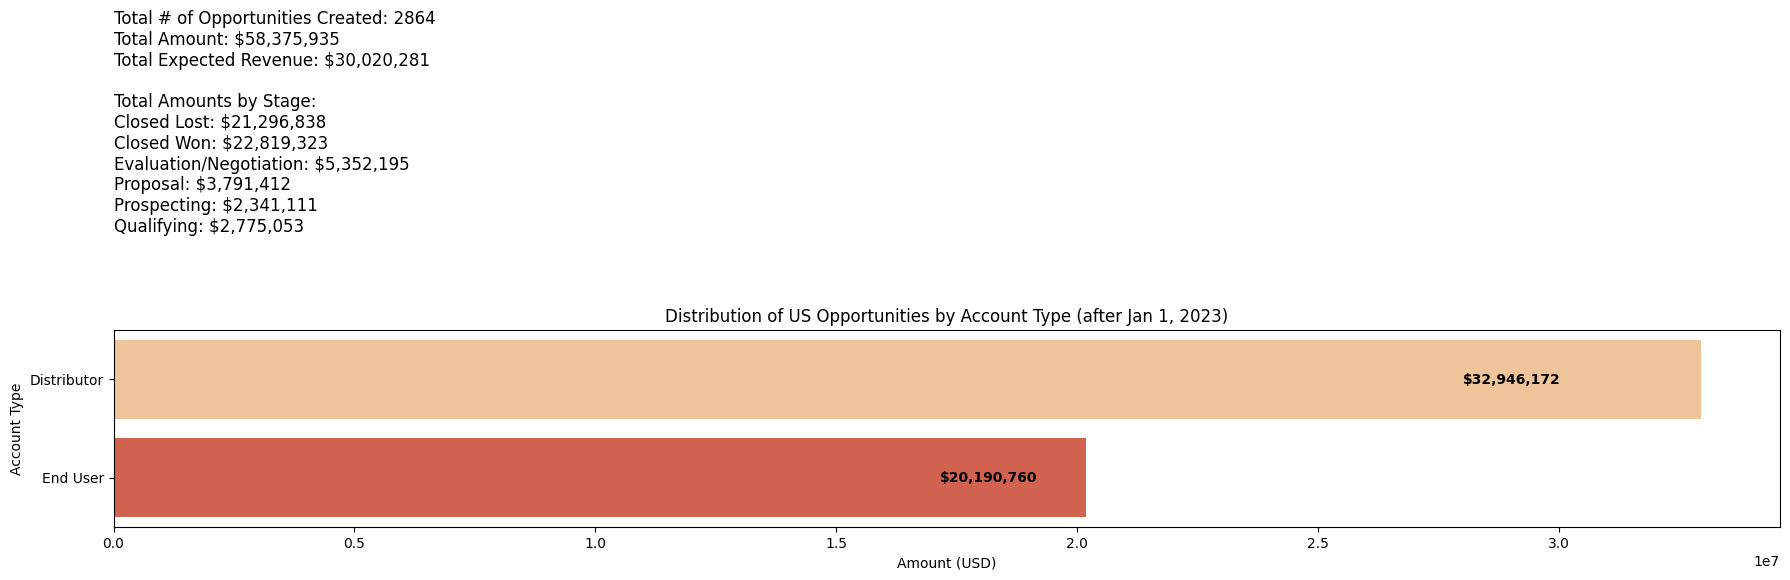

In [12]:
# Group by Type and sum Amount and Expected Revenue
type_grouped = df.groupby('Type')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Plot Total Amount by Account Type with custom colors
plt.figure(figsize=(18, 8))
sns.barplot(data=type_grouped, x='Amount', y='Type', palette='OrRd', orient='h')

# Annotate each bar with its value (including $ sign), positioned inside the bar and using black text
for i, value in enumerate(type_grouped['Amount']):
    plt.text(value * 0.85, i, f'${value:,.0f}', va='center', color='black', fontweight='bold')  # Add $ sign to the formatted value

# Customizing the chart with new axis labels and title
plt.title('Distribution of US Opportunities by Account Type (after Jan 1, 2023)')
plt.xlabel('Amount (USD)')
plt.ylabel('Account Type')

# Adding custom note below the plot with totals by stage
plt.text(0, -1.5, 'Total # of Opportunities Created: 2864\nTotal Amount: $58,375,935\nTotal Expected Revenue: $30,020,281\n'
         '\n'
         'Total Amounts by Stage:\n'
         'Closed Lost: $21,296,838\n'
         'Closed Won: $22,819,323\n'
         'Evaluation/Negotiation: $5,352,195\n'
         'Proposal: $3,791,412\n'
         'Prospecting: $2,341,111\n'
         'Qualifying: $2,775,053', 
         fontsize=12, ha='left')

# Adjust layout to make space for the note
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\562834213.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics, x=values, palette='Set2', orient='h')  # Horizontal bar chart with 'Set2' palette


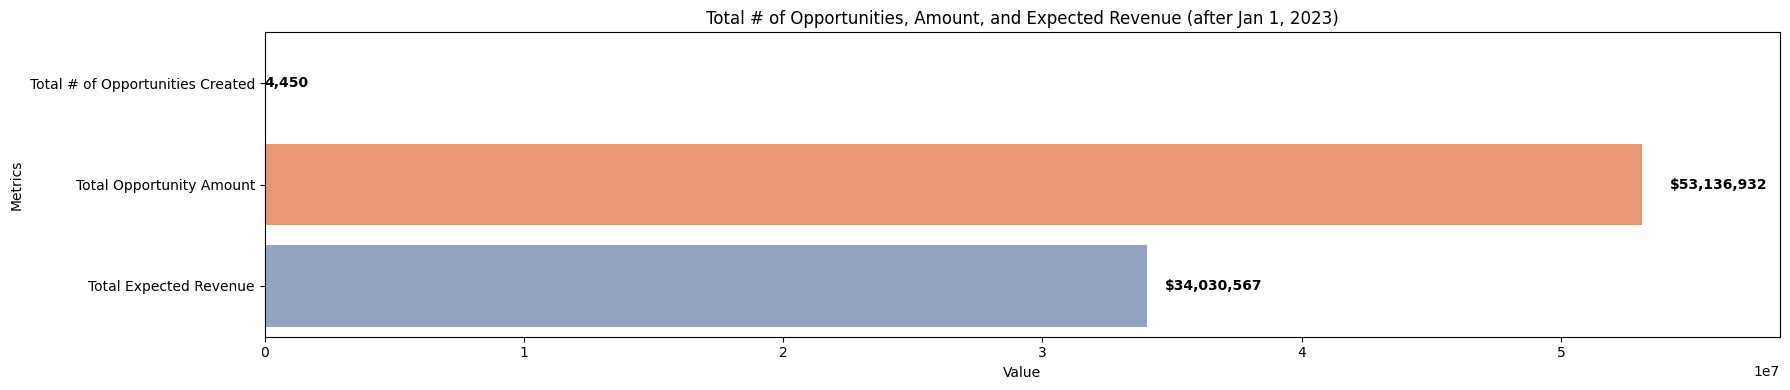

In [13]:
# Data to visualize
metrics = ['Total # of Opportunities Created', 'Total Opportunity Amount', 'Total Expected Revenue']
values = [total_opps, total_amount, total_expected_revenue]

# Create a horizontal bar chart with different colors
plt.figure(figsize=(18, 4))
sns.barplot(y=metrics, x=values, palette='Set2', orient='h')  # Horizontal bar chart with 'Set2' palette

# Annotating the values on the bars, adding $ sign and removing last two digits for Amount and Expected Revenue
for i, value in enumerate(values):
    if i == 0:  # For Total # of Opportunities
        plt.text(value + value * 0.02, i, f'{value:,.0f}', va='center', color='black', fontweight='bold')
    else:  # For Amount and Expected Revenue, remove last two digits and add $
        plt.text(value + value * 0.02, i, f'${value/1:,.0f}', va='center', color='black', fontweight='bold')

# Customizing the chart
plt.title('Total # of Opportunities, Amount, and Expected Revenue (after Jan 1, 2023)', fontsize=12)
plt.xlabel('Value')
plt.ylabel('Metrics')
plt.xlim(0, max(values) * 1.1)  # Slightly extend x-axis limit for better fit

# Display the plot
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\3707429464.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics, x=values, palette='Set2', orient='h')  # Horizontal bar chart with 'Set2' palette


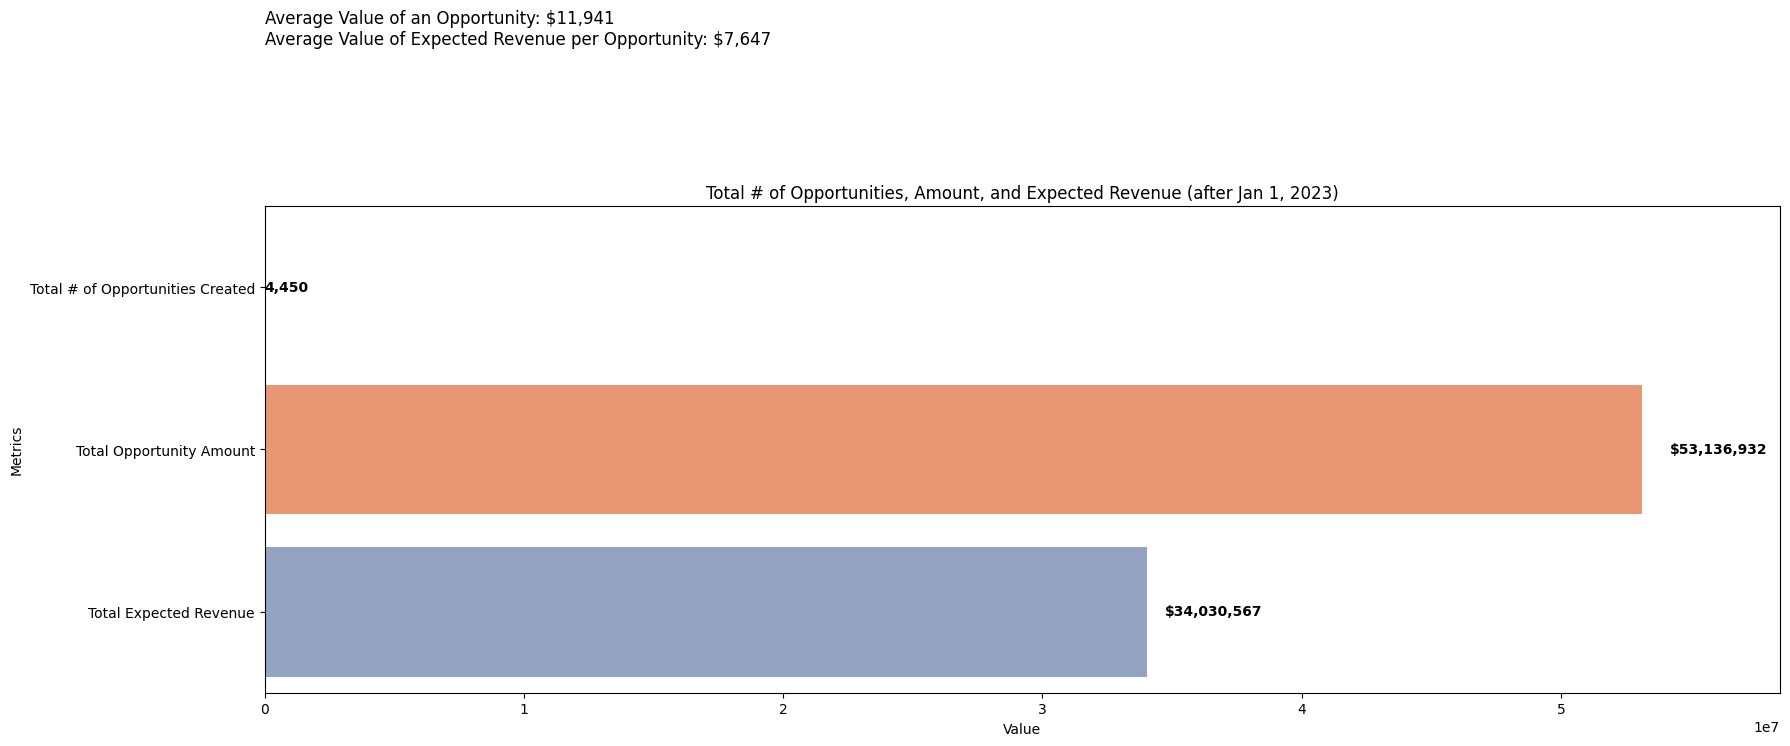

In [14]:
# Calculate average value of an opportunity and average expected revenue per opportunity
avg_value_opportunity = total_amount / total_opps
avg_value_expected_revenue = total_expected_revenue / total_opps

# Data to visualize
metrics = ['Total # of Opportunities Created', 'Total Opportunity Amount', 'Total Expected Revenue']
values = [total_opps, total_amount, total_expected_revenue]

# Create a horizontal bar chart with different colors
plt.figure(figsize=(18, 8))
sns.barplot(y=metrics, x=values, palette='Set2', orient='h')  # Horizontal bar chart with 'Set2' palette

# Annotating the values on the bars, adding $ sign for Amount and Expected Revenue
for i, value in enumerate(values):
    if i == 0:  # For Total # of Opportunities
        plt.text(value + value * 0.02, i, f'{value:,.0f}', va='center', color='black', fontweight='bold')
    else:  # For Amount and Expected Revenue, add $ sign and format appropriately
        plt.text(value + value * 0.02, i, f'${value/1:,.0f}', va='center', color='black', fontweight='bold')

# Customizing the chart
plt.title('Total # of Opportunities, Amount, and Expected Revenue (after Jan 1, 2023)', fontsize=12)
plt.xlabel('Value')
plt.ylabel('Metrics')
plt.xlim(0, max(values) * 1.1)  # Slightly extend x-axis limit for better fit

# Adding average value annotations below the plot
plt.text(0, -1.5, f'Average Value of an Opportunity: ${avg_value_opportunity:,.0f}\n'
                  f'Average Value of Expected Revenue per Opportunity: ${avg_value_expected_revenue:,.0f}',
         fontsize=12, ha='left')

# Display the plot
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2384671598.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics, x=values, palette='OrRd', orient='h')  # Using the 'OrRd' palette for orange-red colors


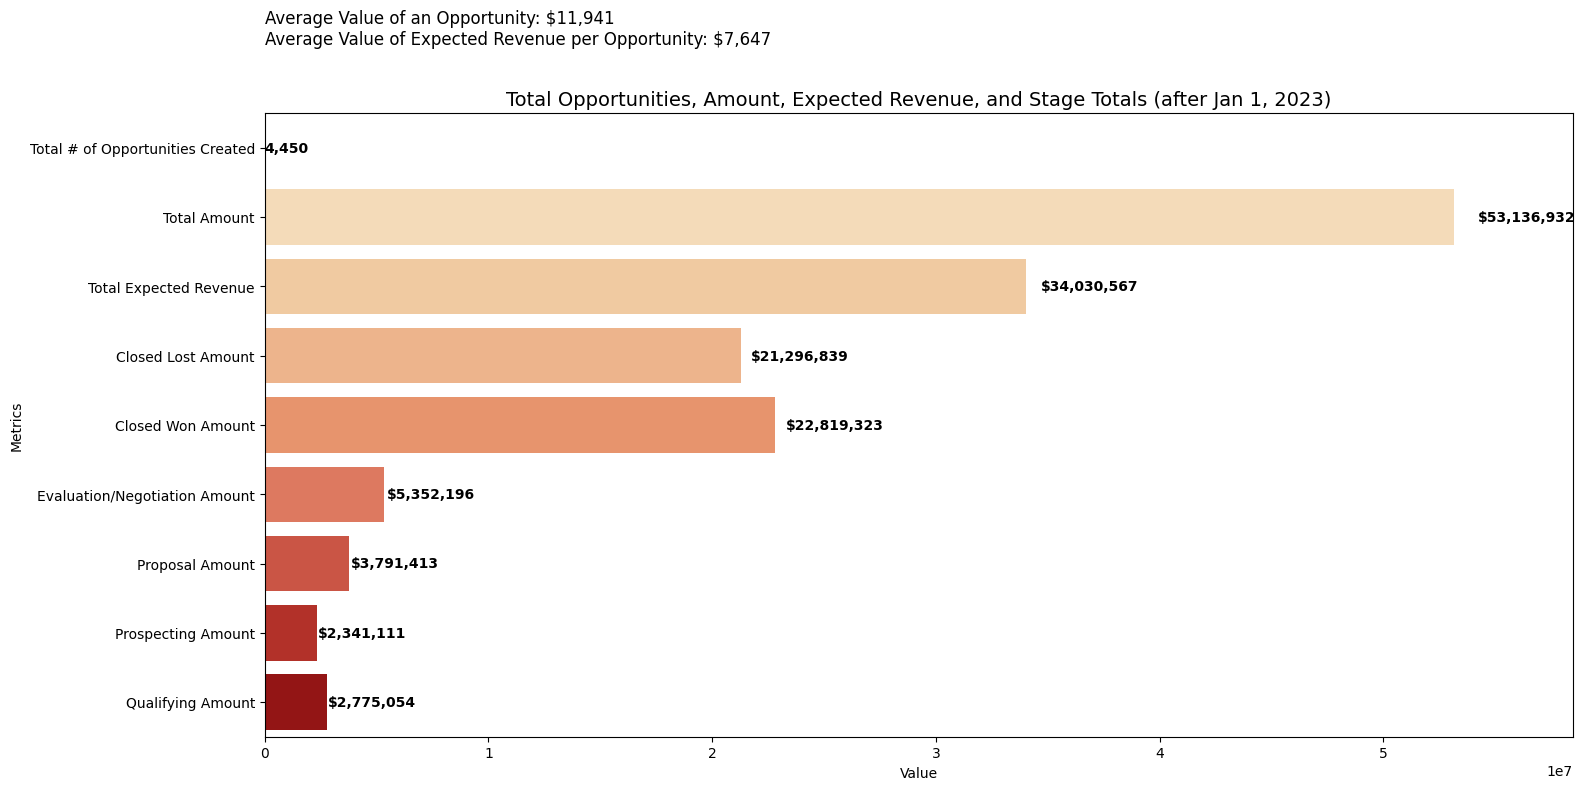

In [15]:
# Define the data to visualize in a single bar chart
metrics = [
    'Total # of Opportunities Created', 
    'Total Amount', 
    'Total Expected Revenue', 
    'Closed Lost Amount', 
    'Closed Won Amount', 
    'Evaluation/Negotiation Amount', 
    'Proposal Amount', 
    'Prospecting Amount', 
    'Qualifying Amount'
]
values = [
    total_opps, 
    total_amount, 
    total_expected_revenue, 
    21296838.94,   # Closed Lost
    22819323.40,   # Closed Won
    5352195.58,    # Evaluation/Negotiation
    3791412.98,    # Proposal
    2341111.22,    # Prospecting
    2775053.74     # Qualifying
]

# Create a horizontal bar chart with custom colors
plt.figure(figsize=(16, 8))
sns.barplot(y=metrics, x=values, palette='OrRd', orient='h')  # Using the 'OrRd' palette for orange-red colors

# Annotate each bar with its value, including $ sign for financial values
for i, value in enumerate(values):
    if i == 0:  # Total # of Opportunities (no $ sign)
        plt.text(value + value * 0.02, i, f'{value:,.0f}', va='center', color='black', fontweight='bold')
    else:  # For amounts, include $ sign and format appropriately
        plt.text(value + value * 0.02, i, f'${value/1:,.0f}', va='center', color='black', fontweight='bold')

# Customizing the chart with new axis labels and title
plt.title('Total Opportunities, Amount, Expected Revenue, and Stage Totals (after Jan 1, 2023)', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Metrics')
plt.xlim(0, max(values) * 1.1)  # Slightly extend x-axis limit for better fit

# Adding custom note with average values below the plot
avg_value_opportunity = total_amount / total_opps
avg_value_expected_revenue = total_expected_revenue / total_opps

plt.text(0, -1.5, f'Average Value of an Opportunity: ${avg_value_opportunity:,.0f}\n'
                  f'Average Value of Expected Revenue per Opportunity: ${avg_value_expected_revenue:,.0f}',
         fontsize=12, ha='left')

# Adjust layout to make space for the note
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\717544863.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics, x=values, palette='OrRd', orient='h')  # Using the 'OrRd' palette for orange-red colors


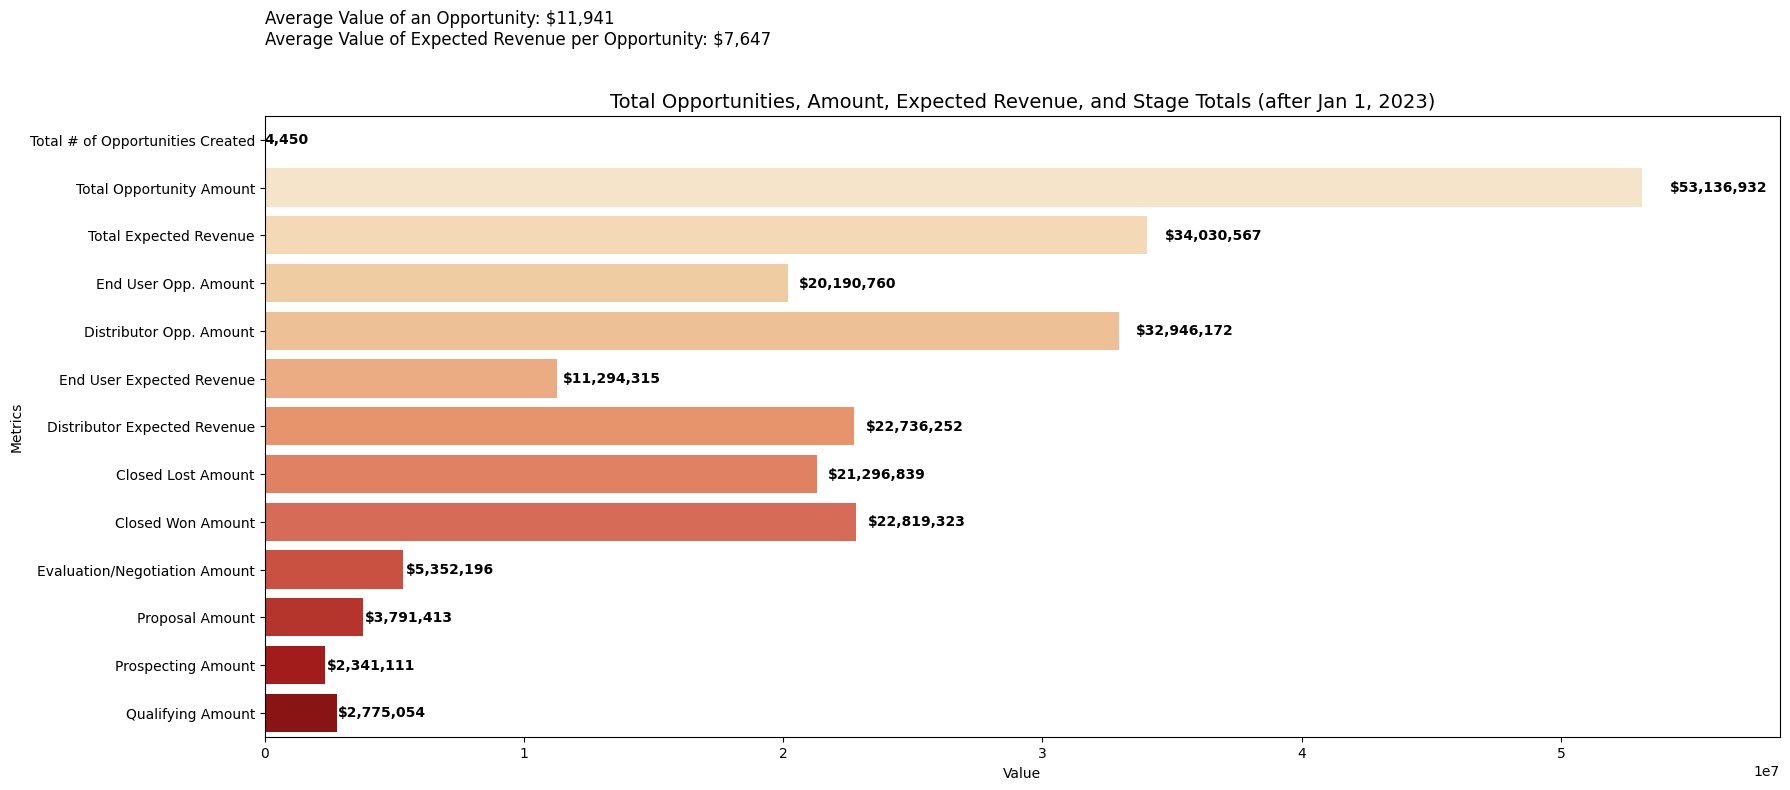

In [16]:
# Group by Type (Account Type) to get Total Amount and Expected Revenue by End User and Distributor
type_grouped = df.groupby('Type')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Extracting values for End User and Distributor
end_user_amount = type_grouped[type_grouped['Type'] == 'End User']['Amount'].values[0]
distributor_amount = type_grouped[type_grouped['Type'] == 'Distributor']['Amount'].values[0]
end_user_expected_revenue = type_grouped[type_grouped['Type'] == 'End User']['ExpectedRevenue'].values[0]
distributor_expected_revenue = type_grouped[type_grouped['Type'] == 'Distributor']['ExpectedRevenue'].values[0]

# Define all the metrics and their values to display in a single chart
metrics = [
    'Total # of Opportunities Created', 
    'Total Opportunity Amount', 
    'Total Expected Revenue', 
    'End User Opp. Amount', 
    'Distributor Opp. Amount', 
    'End User Expected Revenue', 
    'Distributor Expected Revenue', 
    'Closed Lost Amount', 
    'Closed Won Amount', 
    'Evaluation/Negotiation Amount', 
    'Proposal Amount', 
    'Prospecting Amount', 
    'Qualifying Amount'
]
values = [
    total_opps, 
    total_amount, 
    total_expected_revenue, 
    end_user_amount, 
    distributor_amount, 
    end_user_expected_revenue, 
    distributor_expected_revenue, 
    21296838.94,   # Closed Lost
    22819323.40,   # Closed Won
    5352195.58,    # Evaluation/Negotiation
    3791412.98,    # Proposal
    2341111.22,    # Prospecting
    2775053.74     # Qualifying
]

# Create a horizontal bar chart with custom colors
plt.figure(figsize=(18, 8))
sns.barplot(y=metrics, x=values, palette='OrRd', orient='h')  # Using the 'OrRd' palette for orange-red colors

# Annotate each bar with its value, including $ sign for financial values
for i, value in enumerate(values):
    if i == 0:  # Total # of Opportunities (no $ sign)
        plt.text(value + value * 0.02, i, f'{value:,.0f}', va='center', color='black', fontweight='bold')
    else:  # For amounts and revenues, include $ sign and format appropriately
        plt.text(value + value * 0.02, i, f'${value/1:,.0f}', va='center', color='black', fontweight='bold')

# Customizing the chart with new axis labels and title
plt.title('Total Opportunities, Amount, Expected Revenue, and Stage Totals (after Jan 1, 2023)', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Metrics')
plt.xlim(0, max(values) * 1.1)  # Slightly extend x-axis limit for better fit

# Adding custom note with average values below the plot
avg_value_opportunity = total_amount / total_opps
avg_value_expected_revenue = total_expected_revenue / total_opps

plt.text(0, -2, f'Average Value of an Opportunity: ${avg_value_opportunity:,.0f}\n'
                f'Average Value of Expected Revenue per Opportunity: ${avg_value_expected_revenue:,.0f}',
         fontsize=12, ha='left')

# Adjust layout to make space for the note
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\3724253219.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics, x=values, palette='OrRd', orient='h')  # Using the 'OrRd' palette for orange-red colors


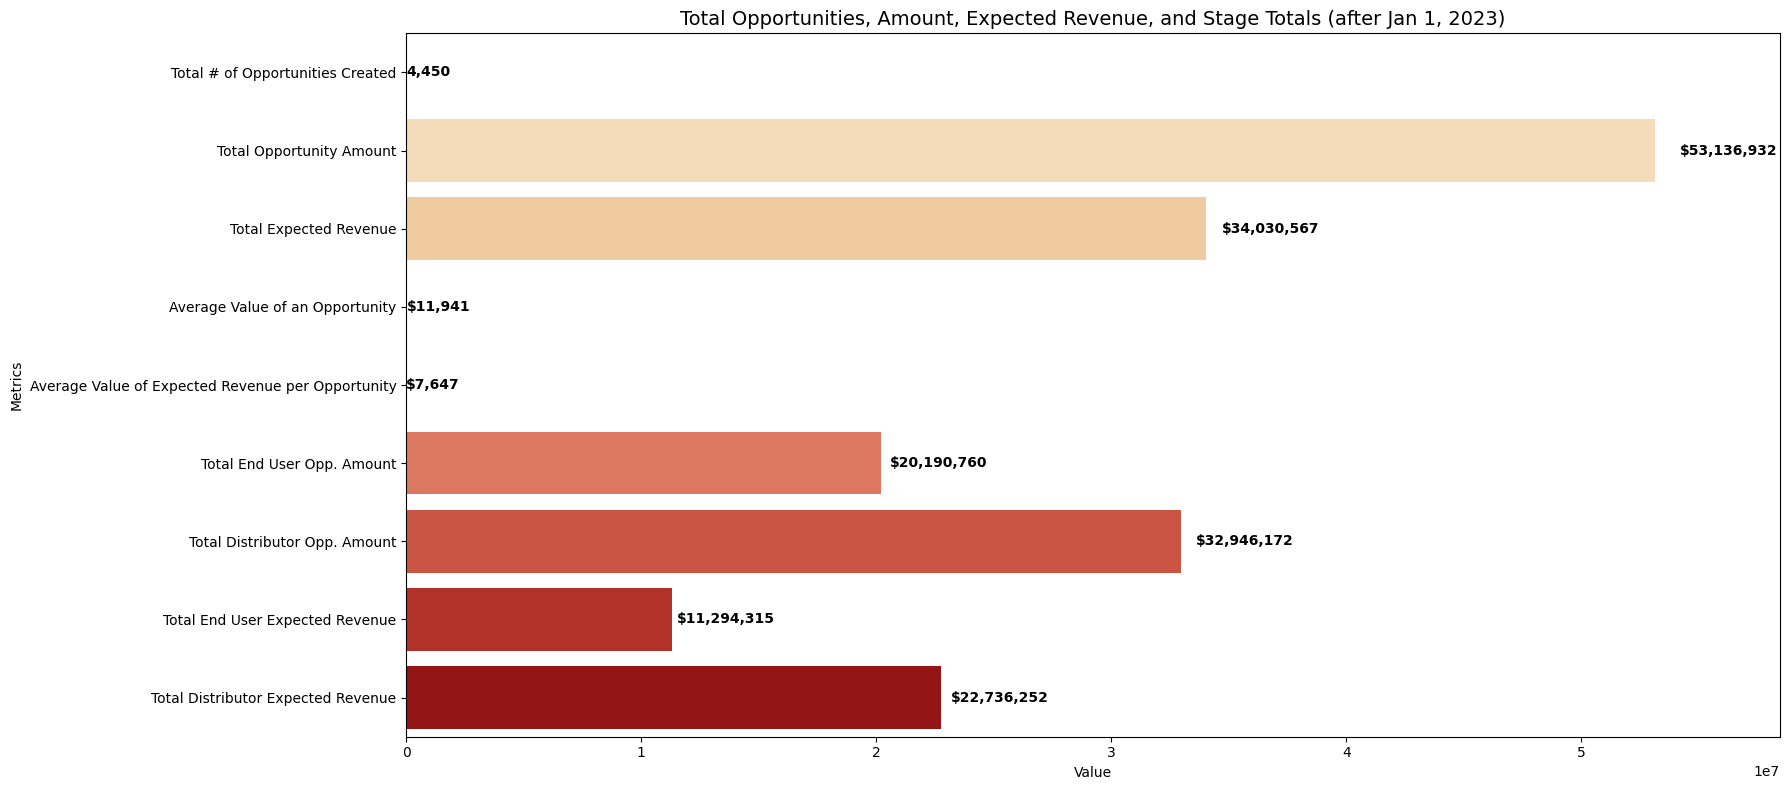

In [17]:
# Group by Type (End User or Distributor) and sum Amount and Expected Revenue
type_grouped = df.groupby('Type')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Extracting values for End User and Distributor
end_user_amount = type_grouped[type_grouped['Type'] == 'End User']['Amount'].values[0]
distributor_amount = type_grouped[type_grouped['Type'] == 'Distributor']['Amount'].values[0]
end_user_expected_revenue = type_grouped[type_grouped['Type'] == 'End User']['ExpectedRevenue'].values[0]
distributor_expected_revenue = type_grouped[type_grouped['Type'] == 'Distributor']['ExpectedRevenue'].values[0]

# Calculate average value of an opportunity and average expected revenue per opportunity
avg_value_opportunity = total_amount / total_opps
avg_value_expected_revenue = total_expected_revenue / total_opps

# Define all the metrics and their values to display in a single chart
metrics = [
    'Total # of Opportunities Created', 
    'Total Opportunity Amount', 
    'Total Expected Revenue', 
    'Average Value of an Opportunity', 
    'Average Value of Expected Revenue per Opportunity',
    'Total End User Opp. Amount', 
    'Total Distributor Opp. Amount',
    'Total End User Expected Revenue', 
    'Total Distributor Expected Revenue',
]

values = [
    total_opps, 
    total_amount, 
    total_expected_revenue, 
    avg_value_opportunity,  # Average Value of an Opportunity
    avg_value_expected_revenue,  # Average Value of Expected Revenue per Opportunity
    end_user_amount, 
    distributor_amount, 
    end_user_expected_revenue, 
    distributor_expected_revenue, 
]

# Create a horizontal bar chart with custom colors
plt.figure(figsize=(18, 8))
sns.barplot(y=metrics, x=values, palette='OrRd', orient='h')  # Using the 'OrRd' palette for orange-red colors

# Annotate each bar with its value, including $ sign for financial values
for i, value in enumerate(values):
    if i == 0:  # Total # of Opportunities (no $ sign)
        plt.text(value + value * 0.02, i, f'{value:,.0f}', va='center', color='black', fontweight='bold')
    else:  # For amounts and revenues, include $ sign and format appropriately
        plt.text(value + value * 0.02, i, f'${value/1:,.0f}', va='center', color='black', fontweight='bold')

# Customizing the chart with new axis labels and title
plt.title('Total Opportunities, Amount, Expected Revenue, and Stage Totals (after Jan 1, 2023)', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Metrics')
plt.xlim(0, max(values) * 1.1)  # Slightly extend x-axis limit for better fit

# Adjust layout to make space for everything
plt.tight_layout()
plt.show()



C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2273727084.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(stage_type_pivot, annot=stage_type_pivot.applymap(lambda v: f'${v:,.0f}'), fmt='', cmap="coolwarm", annot_kws={"size": 10})


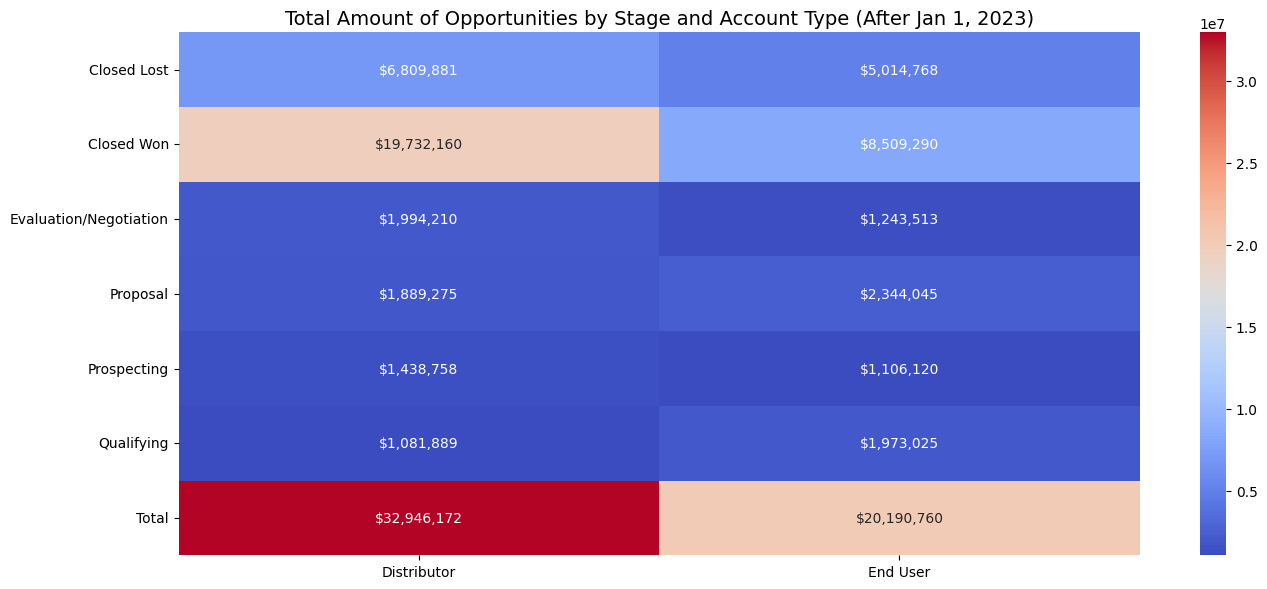

In [18]:
# Group by Stage and Type, sum Amount
stage_type_grouped = df.groupby(['Stage', 'Type'])['Amount'].sum().reset_index()

# Pivot for heatmap or table display
stage_type_pivot = stage_type_grouped.pivot(index='Stage', columns='Type', values='Amount')

# Calculate the total Expected Revenue for End Users and Distributors
total_distributor_revenue = df[df['Type'] == 'Distributor']['ExpectedRevenue'].sum()
total_end_user_revenue = df[df['Type'] == 'End User']['ExpectedRevenue'].sum()

# Calculate the total Amount for End Users and Distributors
total_distributor_amount = df[df['Type'] == 'Distributor']['Amount'].sum()
total_end_user_amount = df[df['Type'] == 'End User']['Amount'].sum()

# Add a new row for Total Amounts of Opportunities
total_row = pd.DataFrame({'Distributor': [total_distributor_amount], 'End User': [total_end_user_amount]}, index=['Total'])
stage_type_pivot = pd.concat([stage_type_pivot, total_row])

# Function to format the values with $ and no decimals
def fmt_dollar(x, pos):
    return '${:,.0f}'.format(x)

# Heatmap visualization
plt.figure(figsize=(14, 6))

# Create the heatmap with annotations
sns.heatmap(stage_type_pivot, annot=stage_type_pivot.applymap(lambda v: f'${v:,.0f}'), fmt='', cmap="coolwarm", annot_kws={"size": 10})

# Customizing the title
plt.title('Total Amount of Opportunities by Stage and Account Type (After Jan 1, 2023)', fontsize=14)

# # Add text for Total End User and Distributor Expected Revenue in the upper left corner
# plt.text(0, 1.1, f'Total Distributor Expected Revenue: ${total_distributor_revenue:,.0f}\nTotal End User Expected Revenue: ${total_end_user_revenue:,.0f}',
#          fontsize=12, color='blue', ha='left', va='bottom', transform=plt.gca().transAxes)

# Display the plot
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1856733951.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(stage_type_pivot, annot=stage_type_pivot.applymap(lambda v: f'${v:,.0f}'), fmt='', cmap="coolwarm", annot_kws={"size": 10}, cbar=False)


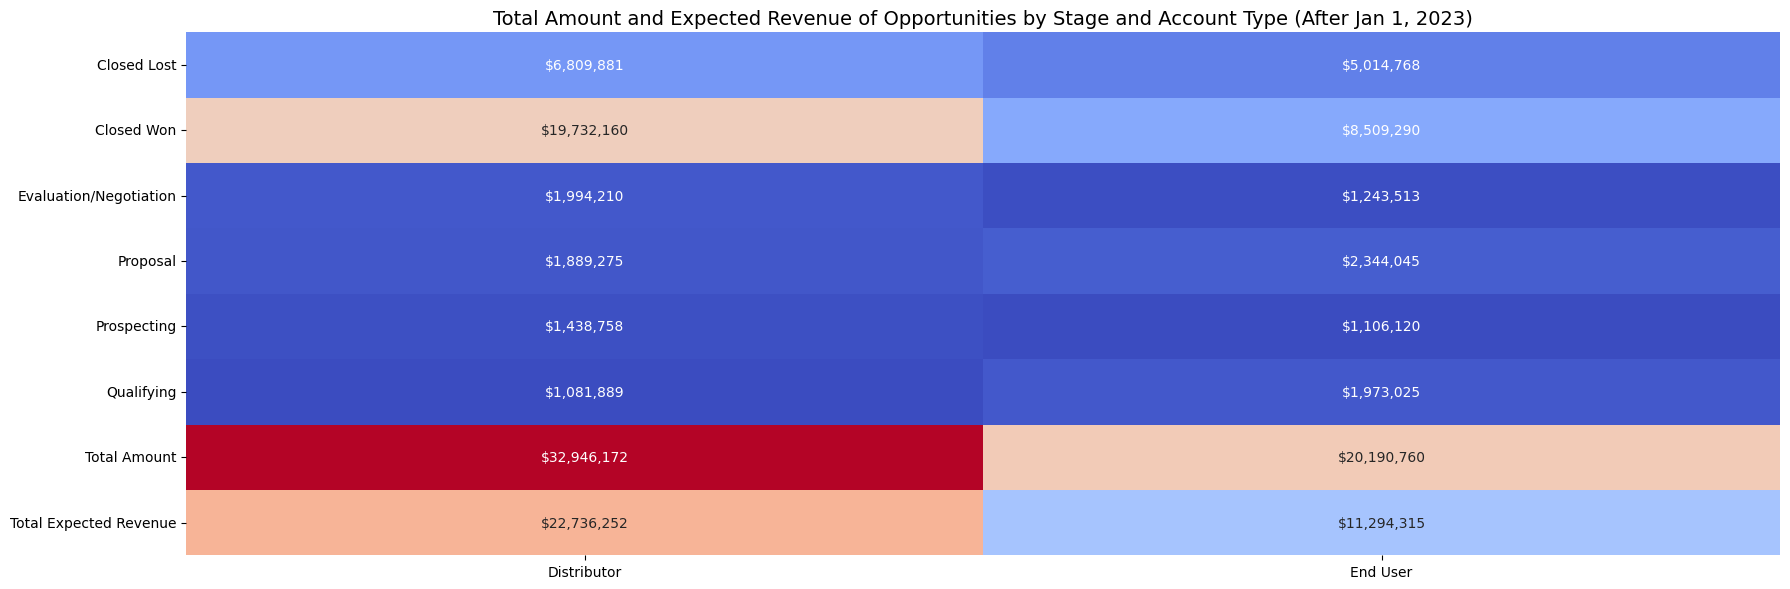

In [19]:
# Group by Stage and Type, sum Amount
stage_type_grouped = df.groupby(['Stage', 'Type'])['Amount'].sum().reset_index()

# Pivot for heatmap or table display
stage_type_pivot = stage_type_grouped.pivot(index='Stage', columns='Type', values='Amount')

# Calculate the total Amount for End Users and Distributors
total_distributor_amount = df[df['Type'] == 'Distributor']['Amount'].sum()
total_end_user_amount = df[df['Type'] == 'End User']['Amount'].sum()

# Add a new row for Total Amounts of Opportunities
total_row = pd.DataFrame({'Distributor': [total_distributor_amount], 'End User': [total_end_user_amount]}, index=['Total Amount'])
stage_type_pivot = pd.concat([stage_type_pivot, total_row])

# Calculate the total Expected Revenue for End Users and Distributors
total_distributor_revenue = df[df['Type'] == 'Distributor']['ExpectedRevenue'].sum()
total_end_user_revenue = df[df['Type'] == 'End User']['ExpectedRevenue'].sum()

# Add a new row for Total Expected Revenue
total_revenue_row = pd.DataFrame({'Distributor': [total_distributor_revenue], 'End User': [total_end_user_revenue]}, index=['Total Expected Revenue'])
stage_type_pivot = pd.concat([stage_type_pivot, total_revenue_row])

# Function to format the values with $ and no decimals
def fmt_dollar(x, pos):
    return '${:,.0f}'.format(x)

# Heatmap visualization
plt.figure(figsize=(18, 6))

# Create the heatmap with annotations
sns.heatmap(stage_type_pivot, annot=stage_type_pivot.applymap(lambda v: f'${v:,.0f}'), fmt='', cmap="coolwarm", annot_kws={"size": 10}, cbar=False)

# Customizing the title
plt.title('Total Amount and Expected Revenue of Opportunities by Stage and Account Type (After Jan 1, 2023)', fontsize=14)

# Display the plot
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2209797508.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(filtered_stage_type_pivot, annot=filtered_stage_type_pivot.applymap(lambda v: f'${v:,.0f}'), fmt='', cmap="coolwarm", annot_kws={"size": 10}, cbar=False)


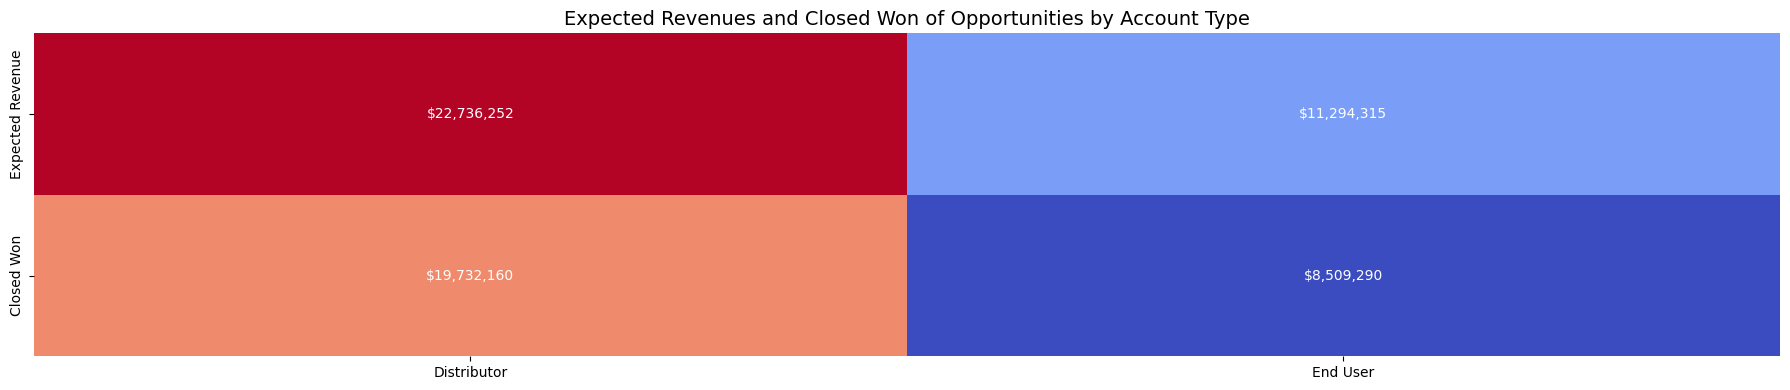

In [20]:
# Group by Stage and Type, sum Amount
stage_type_grouped = df.groupby(['Stage', 'Type'])['Amount'].sum().reset_index()

# Pivot for heatmap or table display
stage_type_pivot = stage_type_grouped.pivot(index='Stage', columns='Type', values='Amount')

# Calculate the total Expected Revenue for End Users and Distributors
total_distributor_revenue = df[df['Type'] == 'Distributor']['ExpectedRevenue'].sum()
total_end_user_revenue = df[df['Type'] == 'End User']['ExpectedRevenue'].sum()

# Add a new row for Total Expected Revenue
total_revenue_row = pd.DataFrame({'Distributor': [total_distributor_revenue], 'End User': [total_end_user_revenue]}, index=['Expected Revenue'])
stage_type_pivot = pd.concat([stage_type_pivot, total_revenue_row])

# Filter the data to include only 'Closed Won' and 'Total Expected Revenue'
filtered_stage_type_pivot = stage_type_pivot.loc[['Expected Revenue', 'Closed Won']]

# Function to format the values with $ and no decimals
def fmt_dollar(x, pos):
    return '${:,.0f}'.format(x)

# Heatmap visualization
plt.figure(figsize=(18, 4))

# Create the heatmap with annotations
sns.heatmap(filtered_stage_type_pivot, annot=filtered_stage_type_pivot.applymap(lambda v: f'${v:,.0f}'), fmt='', cmap="coolwarm", annot_kws={"size": 10}, cbar=False)

# Customizing the title
plt.title('Expected Revenues and Closed Won of Opportunities by Account Type', fontsize=14)

# Display the plot
plt.tight_layout()
plt.show()


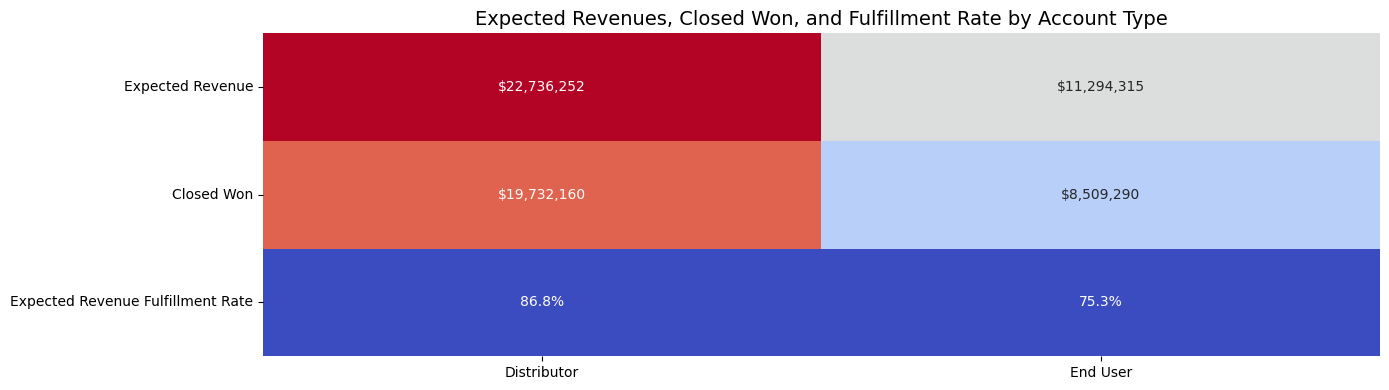

In [21]:
# Group by Stage and Type, sum Amount
stage_type_grouped = df.groupby(['Stage', 'Type'])['Amount'].sum().reset_index()

# Pivot for heatmap or table display
stage_type_pivot = stage_type_grouped.pivot(index='Stage', columns='Type', values='Amount')

# Calculate the total Expected Revenue for End Users and Distributors
total_distributor_revenue = df[df['Type'] == 'Distributor']['ExpectedRevenue'].sum()
total_end_user_revenue = df[df['Type'] == 'End User']['ExpectedRevenue'].sum()

# Add a new row for Total Expected Revenue
total_revenue_row = pd.DataFrame({'Distributor': [total_distributor_revenue], 'End User': [total_end_user_revenue]}, index=['Expected Revenue'])
stage_type_pivot = pd.concat([stage_type_pivot, total_revenue_row])

# Filter the data to include only 'Closed Won' and 'Expected Revenue'
filtered_stage_type_pivot = stage_type_pivot.loc[['Expected Revenue', 'Closed Won']]

# Calculate Expected Revenue Fulfillment Rate for both Distributor and End User
fulfillment_rate_distributor = (filtered_stage_type_pivot.loc['Closed Won', 'Distributor'] / filtered_stage_type_pivot.loc['Expected Revenue', 'Distributor']) * 100
fulfillment_rate_end_user = (filtered_stage_type_pivot.loc['Closed Won', 'End User'] / filtered_stage_type_pivot.loc['Expected Revenue', 'End User']) * 100

# Add a new row for Expected Revenue Fulfillment Rate
fulfillment_rate_row = pd.DataFrame({'Distributor': [fulfillment_rate_distributor], 'End User': [fulfillment_rate_end_user]}, index=['Expected Revenue Fulfillment Rate'])
filtered_stage_type_pivot = pd.concat([filtered_stage_type_pivot, fulfillment_rate_row])

# Heatmap visualization
plt.figure(figsize=(14, 4))

# Create the heatmap
sns.heatmap(filtered_stage_type_pivot, annot=True, fmt='.1f', cmap="coolwarm", annot_kws={"size": 10}, cbar=False)

# Customizing the annotations for formatting dollars and percentages
for idx, text in enumerate(plt.gca().texts):
    row_idx = idx // filtered_stage_type_pivot.shape[1]
    if filtered_stage_type_pivot.index[row_idx] == 'Expected Revenue Fulfillment Rate':
        text.set_text(f'{float(text.get_text()):.1f}%')
    else:
        text.set_text(f'${float(text.get_text()):,.0f}')

# Customizing the title
plt.title('Expected Revenues, Closed Won, and Fulfillment Rate by Account Type', fontsize=14)

# Display the plot
plt.tight_layout()
plt.show()


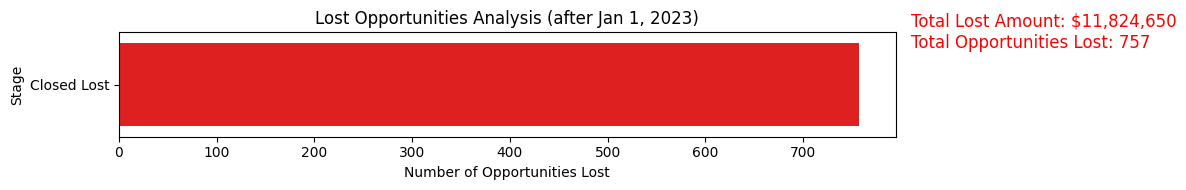

In [22]:
# Define lost_opps_by_stage by grouping by 'Stage' and filtering 'Closed Lost'
lost_opps_by_stage = df[df['Stage'] == 'Closed Lost'].groupby('Stage').size()

# Assuming total_lost_amount is already calculated
total_lost_amount = df[df['Stage'] == 'Closed Lost']['Amount'].sum()
total_lost_count = lost_opps_by_stage.sum()

# Bar plot showing lost opportunities by stage with a specified color
plt.figure(figsize=(12, 2))
ax = sns.barplot(x=lost_opps_by_stage.values, y=lost_opps_by_stage.index, color='red')  # Change color as needed

plt.title('Lost Opportunities Analysis (after Jan 1, 2023)')
plt.xlabel('Number of Opportunities Lost')
plt.ylabel('Stage')

# Add total lost amount and total number of opportunities at the top-right corner of the plot
plt.text(1.02, 1.0, f'Total Lost Amount: ${total_lost_amount:,.0f}\nTotal Opportunities Lost: {total_lost_count:,}', 
         fontsize=12, color='red', ha='left', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


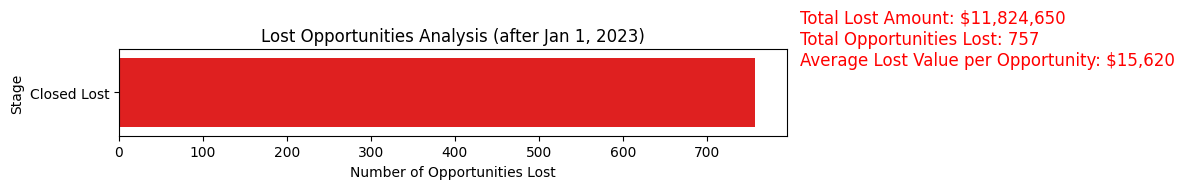

In [23]:
# Assuming total_lost_amount is already calculated
total_lost_amount = df[df['Stage'] == 'Closed Lost']['Amount'].sum()
total_lost_count = df[df['Stage'] == 'Closed Lost'].shape[0]

# Calculate the average value of lost opportunities
avg_lost_value = total_lost_amount / total_lost_count if total_lost_count != 0 else 0

# Calculate the lost amounts for End User and Distributor
end_user_lost_amount = df[(df['Stage'] == 'Closed Lost') & (df['Type'] == 'End User')]['Amount'].sum()
distributor_lost_amount = df[(df['Stage'] == 'Closed Lost') & (df['Type'] == 'Distributor')]['Amount'].sum()

# Group by Stage for lost opportunities
lost_opps_by_stage = df[df['Stage'] == 'Closed Lost'].groupby('Stage').size()

# Bar plot showing lost opportunities by stage with a specified color
plt.figure(figsize=(12, 2))
ax = sns.barplot(x=lost_opps_by_stage.values, y=lost_opps_by_stage.index, color='red')  # Change color as needed

plt.title('Lost Opportunities Analysis (after Jan 1, 2023)')
plt.xlabel('Number of Opportunities Lost')
plt.ylabel('Stage')

# Add total lost amount, total number of opportunities, average value of lost opportunities, and lost amounts for End User and Distributor at the top-right corner of the plot
plt.text(1.02, 1.0, f'Total Lost Amount: ${total_lost_amount:,.0f}\n'
                    f'Total Opportunities Lost: {total_lost_count:,}\n'
                    f'Average Lost Value per Opportunity: ${avg_lost_value:,.0f}\n',
         fontsize=12, color='red', ha='left', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


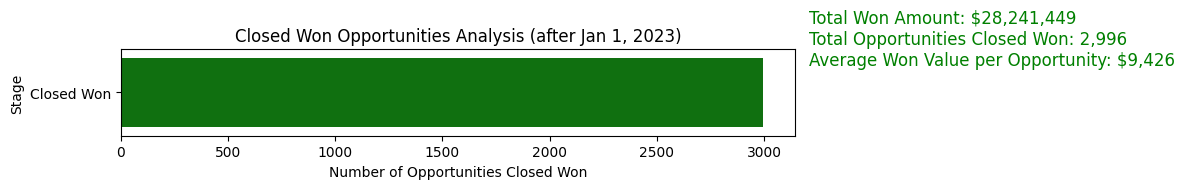

In [24]:
# Assuming total_won_amount is already calculated
total_won_amount = df[df['Stage'] == 'Closed Won']['Amount'].sum()
total_won_count = df[df['Stage'] == 'Closed Won'].shape[0]

# Calculate the average value of closed won opportunities
avg_won_value = total_won_amount / total_won_count if total_won_count != 0 else 0

# Calculate the closed won amounts for End User and Distributor
end_user_won_amount = df[(df['Stage'] == 'Closed Won') & (df['Type'] == 'End User')]['Amount'].sum()
distributor_won_amount = df[(df['Stage'] == 'Closed Won') & (df['Type'] == 'Distributor')]['Amount'].sum()

# Group by Stage for closed won opportunities
won_opps_by_stage = df[df['Stage'] == 'Closed Won'].groupby('Stage').size()

# Bar plot showing closed won opportunities by stage with a specified color
plt.figure(figsize=(12, 2))
ax = sns.barplot(x=won_opps_by_stage.values, y=won_opps_by_stage.index, color='green')  # Change color as needed

plt.title('Closed Won Opportunities Analysis (after Jan 1, 2023)')
plt.xlabel('Number of Opportunities Closed Won')
plt.ylabel('Stage')

# Add total won amount, total number of opportunities, average value of won opportunities, and won amounts for End User and Distributor at the top-right corner of the plot
plt.text(1.02, 1.0, f'Total Won Amount: ${total_won_amount:,.0f}\n'
                    f'Total Opportunities Closed Won: {total_won_count:,}\n'
                    f'Average Won Value per Opportunity: ${avg_won_value:,.0f}\n',
         fontsize=12, color='green', ha='left', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2068250014.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=won_percentage_per_type.index, y=won_percentage_per_type.values, palette=colors)
C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2068250014.py:22: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  bars = sns.barplot(x=won_percentage_per_type.index, y=won_percentage_per_type.values, palette=colors)


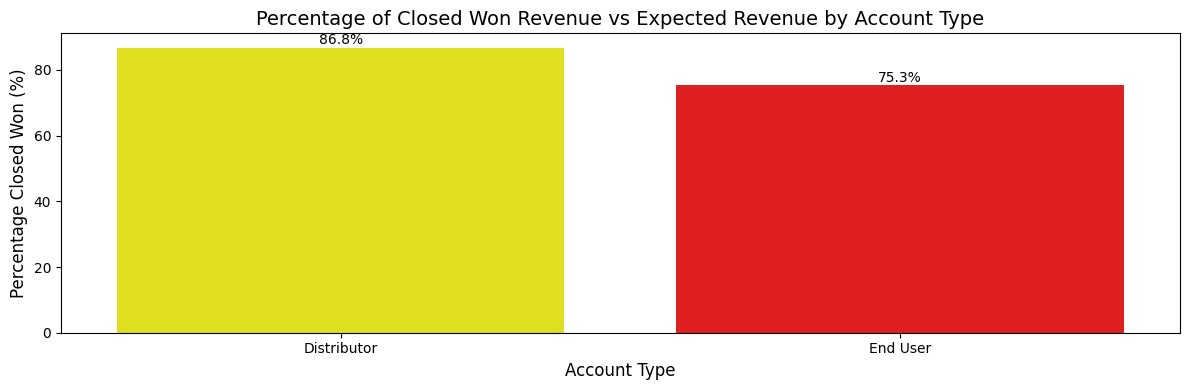

In [25]:
# Group by Stage and Type, sum ExpectedRevenue and Amount for Closed Won
grouped_data = df.groupby(['Stage', 'Type'])[['ExpectedRevenue', 'Amount']].sum().reset_index()

# Filter only 'Closed Won' stage for actual revenue
closed_won_data = grouped_data[grouped_data['Stage'] == 'Closed Won']

# Calculate the total Expected Revenue for each Type
expected_revenue_per_type = df.groupby('Type')['ExpectedRevenue'].sum()

# Calculate the total Closed Won revenue for each Type
closed_won_per_type = closed_won_data.groupby('Type')['Amount'].sum()

# Calculate the percentage of Closed Won vs Expected Revenue for each Type
won_percentage_per_type = (closed_won_per_type / expected_revenue_per_type) * 100

# Normalize percentages to create a color gradient from orange to red
norm = plt.Normalize(won_percentage_per_type.min(), won_percentage_per_type.max())
colors = plt.cm.autumn(norm(won_percentage_per_type.values))  # 'autumn' colormap goes from orange to red

# Create a bar plot for the percentage of Closed Won vs Expected Revenue by Type
plt.figure(figsize=(12, 4))
bars = sns.barplot(x=won_percentage_per_type.index, y=won_percentage_per_type.values, palette=colors)

# Annotate the percentage on top of the bars
for index, value in enumerate(won_percentage_per_type):
    plt.text(index, value + 1, f"{value:.1f}%", color='black', ha="center")

# Customizing the plot
plt.title('Percentage of Closed Won Revenue vs Expected Revenue by Account Type', fontsize=14)
plt.xlabel('Account Type', fontsize=12)
plt.ylabel('Percentage Closed Won (%)', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1834448670.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=lost_percentage_per_type.index, y=lost_percentage_per_type.values, palette=colors)
C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1834448670.py:22: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  bars = sns.barplot(x=lost_percentage_per_type.index, y=lost_percentage_per_type.values, palette=colors)


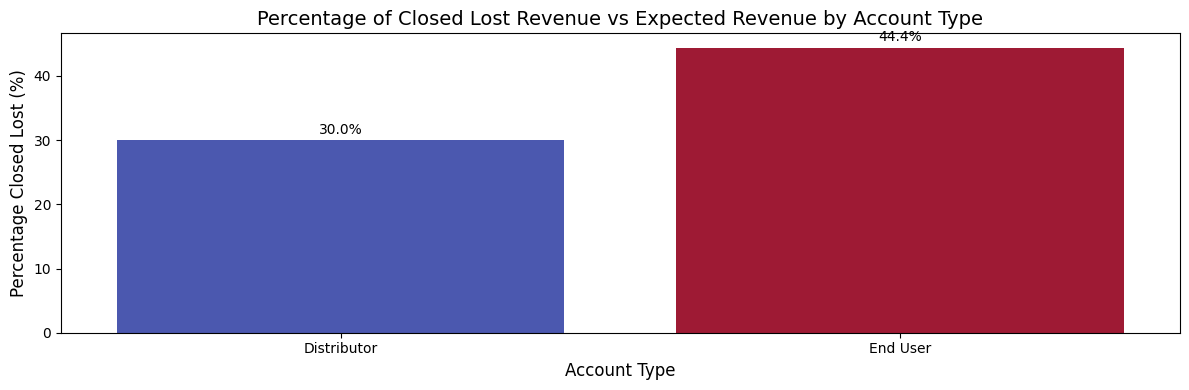

In [26]:
# Group by Stage and Type, sum ExpectedRevenue and Amount for Closed Lost
grouped_data = df.groupby(['Stage', 'Type'])[['ExpectedRevenue', 'Amount']].sum().reset_index()

# Filter only 'Closed Lost' stage for actual lost revenue
closed_lost_data = grouped_data[grouped_data['Stage'] == 'Closed Lost']

# Calculate the total Expected Revenue for each Type
expected_revenue_per_type = df.groupby('Type')['ExpectedRevenue'].sum()

# Calculate the total Closed Lost revenue for each Type
closed_lost_per_type = closed_lost_data.groupby('Type')['Amount'].sum()

# Calculate the percentage of Closed Lost vs Expected Revenue for each Type
lost_percentage_per_type = (closed_lost_per_type / expected_revenue_per_type) * 100

# Normalize percentages to create a color gradient from orange to red
norm = plt.Normalize(lost_percentage_per_type.min(), lost_percentage_per_type.max())
colors = plt.cm.coolwarm(norm(lost_percentage_per_type.values))  # 'autumn' colormap goes from orange to red

# Create a bar plot for the percentage of Closed Lost vs Expected Revenue by Type
plt.figure(figsize=(12, 4))
bars = sns.barplot(x=lost_percentage_per_type.index, y=lost_percentage_per_type.values, palette=colors)

# Annotate the percentage on top of the bars
for index, value in enumerate(lost_percentage_per_type):
    plt.text(index, value + 1, f"{value:.1f}%", color='black', ha="center")

# Customizing the plot
plt.title('Percentage of Closed Lost Revenue vs Expected Revenue by Account Type', fontsize=14)
plt.xlabel('Account Type', fontsize=12)
plt.ylabel('Percentage Closed Lost (%)', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\3664547060.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y='OpportunityOwner', x='Amount', data=grouped_data, palette='viridis')


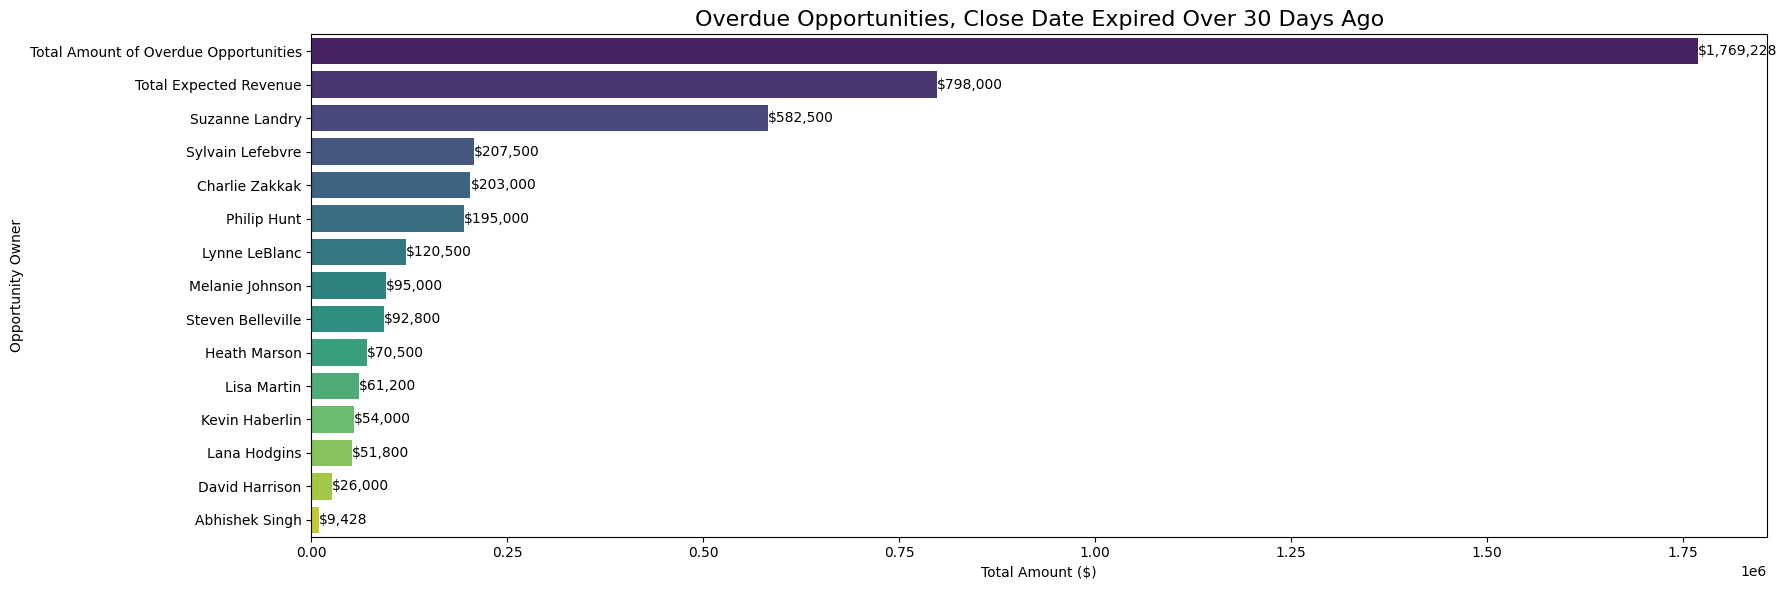

In [27]:
# Define today's date
today = datetime(2024, 10, 3)

# Filter opportunities based on conditions, including overdue check (CloseDate more than 30 days ago)
filtered_df = df[
    (df['ProbabilityCleaned'] > 0) & 
    (~df['Stage'].isin(['Closed Won', 'Closed Lost'])) & 
    (df['Amount'] > 500) & 
    (df['CloseDate'] < today - timedelta(days=30))
]

# Group data by OpportunityOwner and sum Amount
grouped_data = filtered_df.groupby('OpportunityOwner')['Amount'].sum().reset_index()

# Calculate the total amount of opportunities and expected revenue
total_amount = filtered_df['Amount'].sum()
total_expected_revenue = filtered_df['ExpectedRevenue'].sum()

# Create new rows for total amount and expected revenue
total_rows = pd.DataFrame({
    'OpportunityOwner': ['Total Amount of Overdue Opportunities', 'Total Expected Revenue'],
    'Amount': [total_amount, total_expected_revenue]
})

# Concatenate the total rows to the grouped data
grouped_data = pd.concat([grouped_data, total_rows], ignore_index=True)

# Sort data in descending order by 'Amount'
grouped_data = grouped_data.sort_values(by='Amount', ascending=False).reset_index(drop=True)

# Create a larger figure size
plt.figure(figsize=(18, 6))

# Create a horizontal bar plot
ax = sns.barplot(y='OpportunityOwner', x='Amount', data=grouped_data, palette='viridis')

# Add values to the end of each bar
for index, value in enumerate(grouped_data['Amount']):
    ax.text(value, index, f'${value:,.0f}', color='black', ha='left', va='center')

# Add title and labels
plt.title('Overdue Opportunities, Close Date Expired Over 30 Days Ago', fontsize=16)
plt.xlabel('Total Amount ($)')
plt.ylabel('Opportunity Owner')

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\133112017.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y='OpportunityOwner', x='Amount', data=grouped_data, palette='viridis')


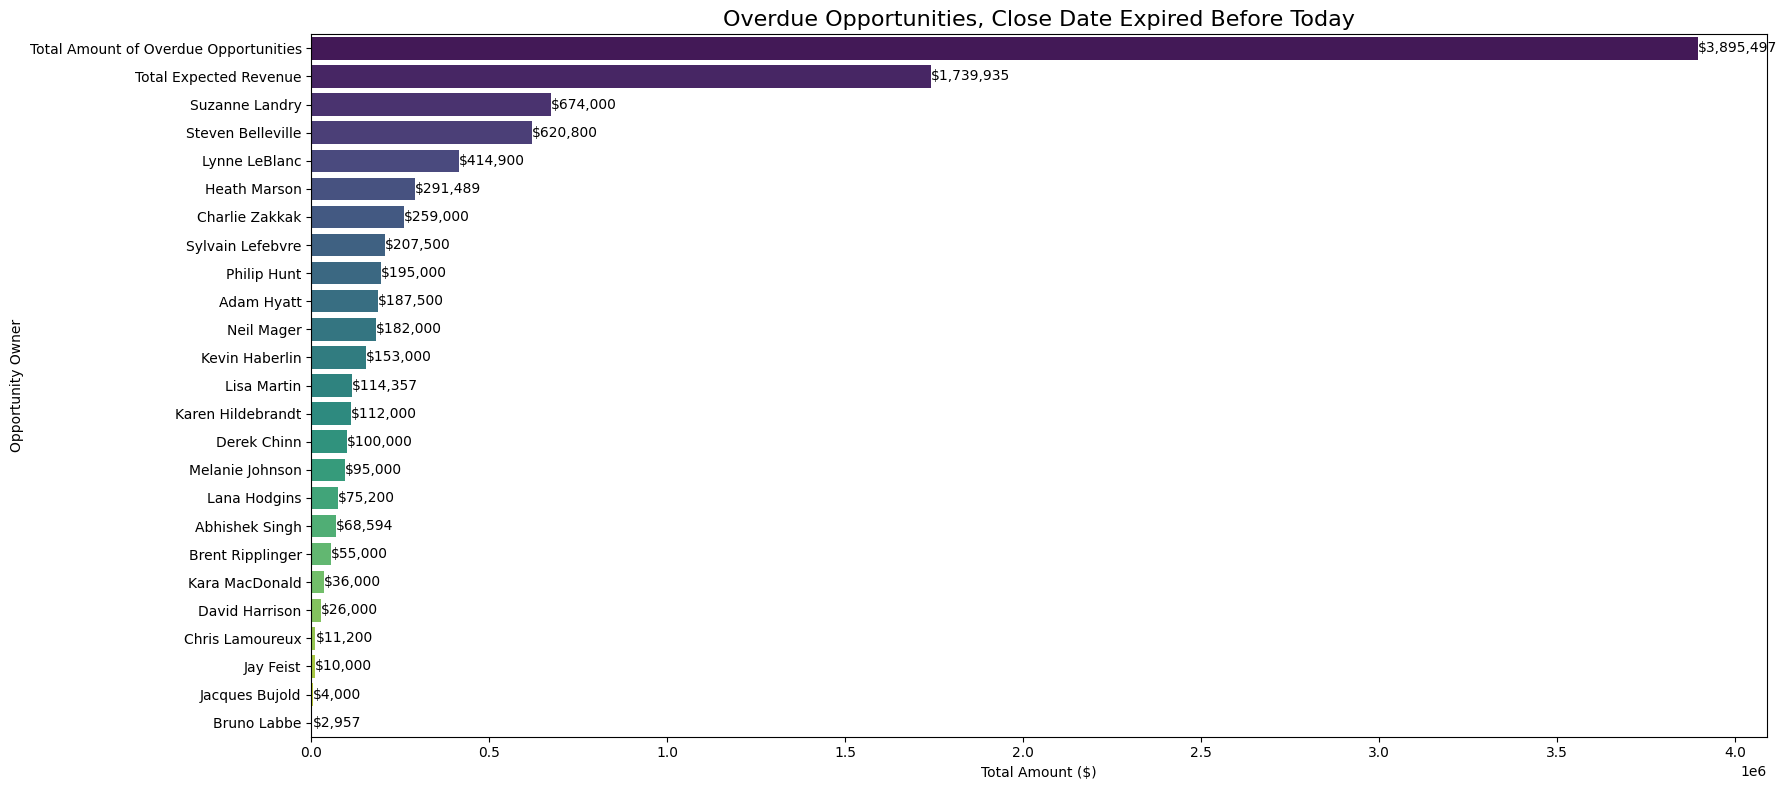

In [28]:
# Define today's date
today = datetime(2024, 10, 3)

# Filter opportunities based on conditions, including overdue check (CloseDate before today)
filtered_df = df[
    (df['ProbabilityCleaned'] > 0) & 
    (~df['Stage'].isin(['Closed Won', 'Closed Lost'])) & 
    (df['Amount'] > 500) & 
    (df['CloseDate'] < today)
]

# Group data by OpportunityOwner and sum Amount
grouped_data = filtered_df.groupby('OpportunityOwner')['Amount'].sum().reset_index()

# Calculate the total amount of opportunities and expected revenue
total_amount = filtered_df['Amount'].sum()
total_expected_revenue = filtered_df['ExpectedRevenue'].sum()

# Create new rows for total amount and expected revenue
total_rows = pd.DataFrame({
    'OpportunityOwner': ['Total Amount of Overdue Opportunities', 'Total Expected Revenue'],
    'Amount': [total_amount, total_expected_revenue]
})

# Concatenate the total rows to the grouped data
grouped_data = pd.concat([grouped_data, total_rows], ignore_index=True)

# Sort data in descending order by 'Amount'
grouped_data = grouped_data.sort_values(by='Amount', ascending=False).reset_index(drop=True)

# Create a larger figure size
plt.figure(figsize=(18, 8))

# Create a horizontal bar plot
ax = sns.barplot(y='OpportunityOwner', x='Amount', data=grouped_data, palette='viridis')

# Add values to the end of each bar
for index, value in enumerate(grouped_data['Amount']):
    ax.text(value, index, f'${value:,.0f}', color='black', ha='left', va='center')

# Add title and labels
plt.title('Overdue Opportunities, Close Date Expired Before Today', fontsize=16)
plt.xlabel('Total Amount ($)')
plt.ylabel('Opportunity Owner')

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()


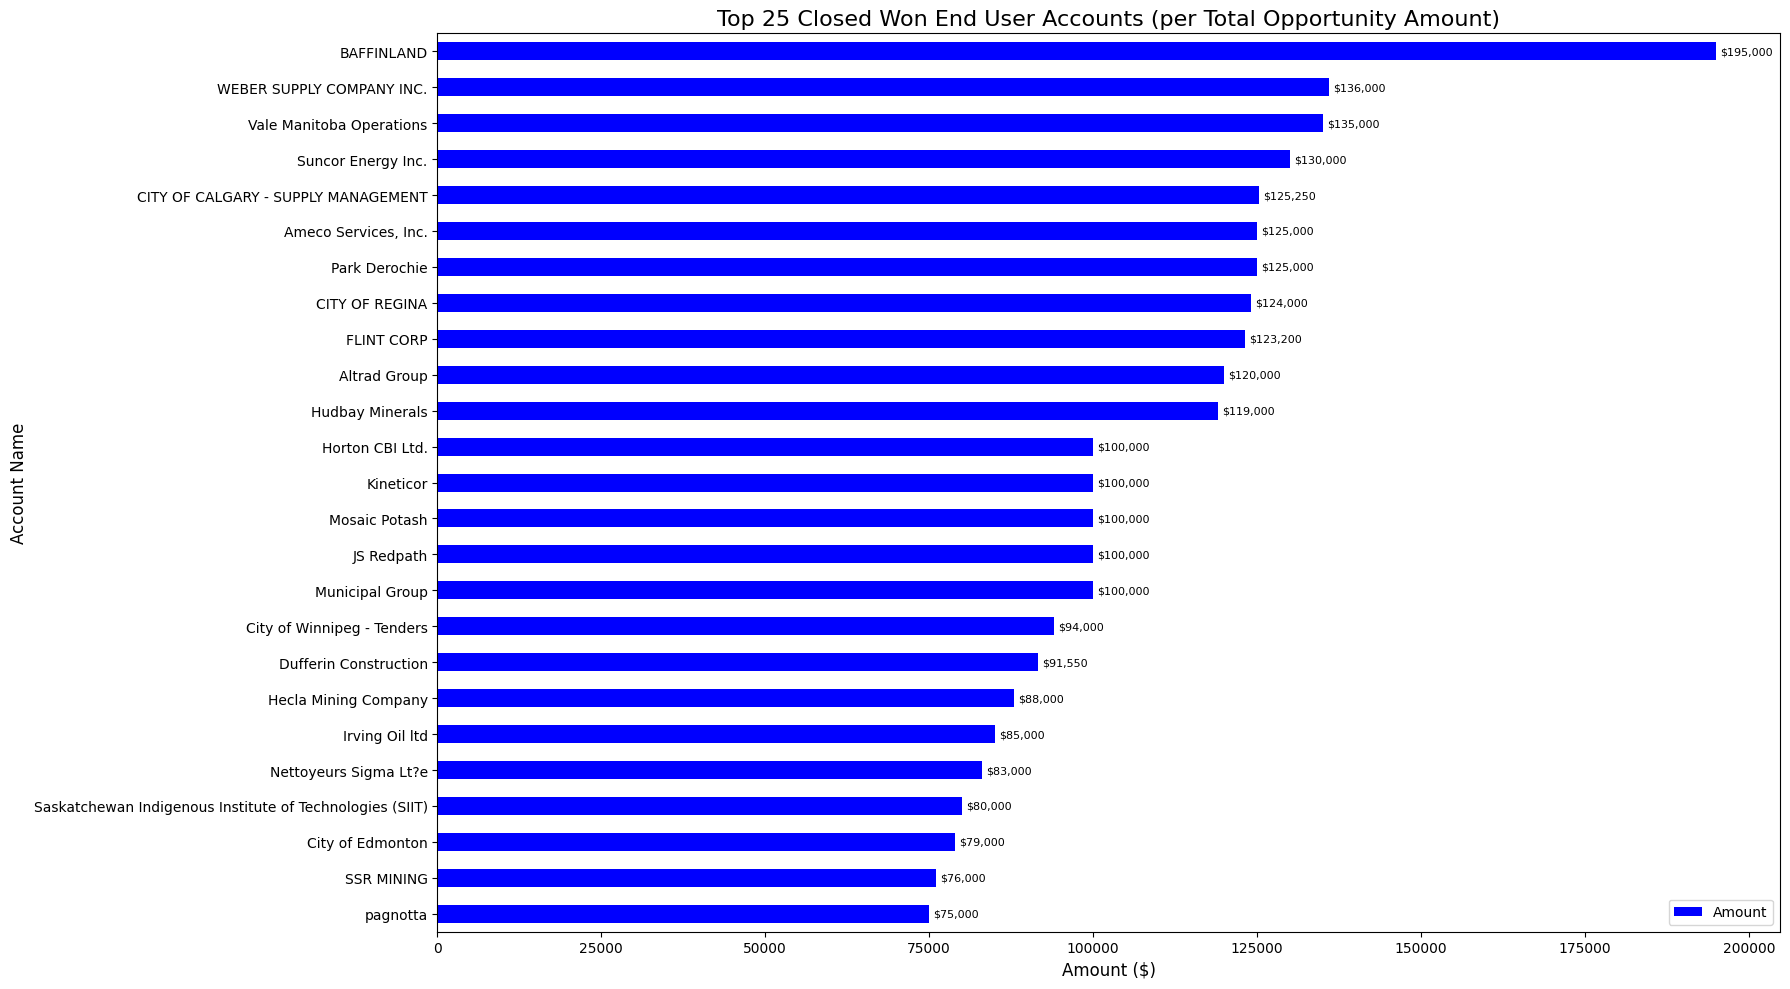

In [29]:
# Filter data for End Users and Closed Won stage
df_end_user_won = df[(df['Type'] == 'End User') & (df['Stage'] == 'Closed Won')]

# Group by and sum Amount and Expected Revenue
df_end_user_won_grouped = df_end_user_won.groupby('AccountName')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Sort by Amount in ascending order and select the last 25 accounts
df_end_user_bottom25 = df_end_user_won_grouped.sort_values(by='Amount', ascending=True).tail(25)

# Create a larger figure size
fig, ax = plt.subplots(figsize=(18, 10))

# Create a horizontal bar plot comparing Amount vs Expected Revenue for the bottom 25 accounts
df_end_user_bottom25.set_index('AccountName')[['Amount']].plot(kind='barh', color=['blue', 'green'], ax=ax)

# Add values to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', label_type='edge', fontsize=8, padding=3)

# Add title and labels
ax.set_title('Top 25 Closed Won End User Accounts (per Total Opportunity Amount)', fontsize=16)
ax.set_xlabel('Amount ($)', fontsize=12)
ax.set_ylabel('Account Name', fontsize=12)

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()


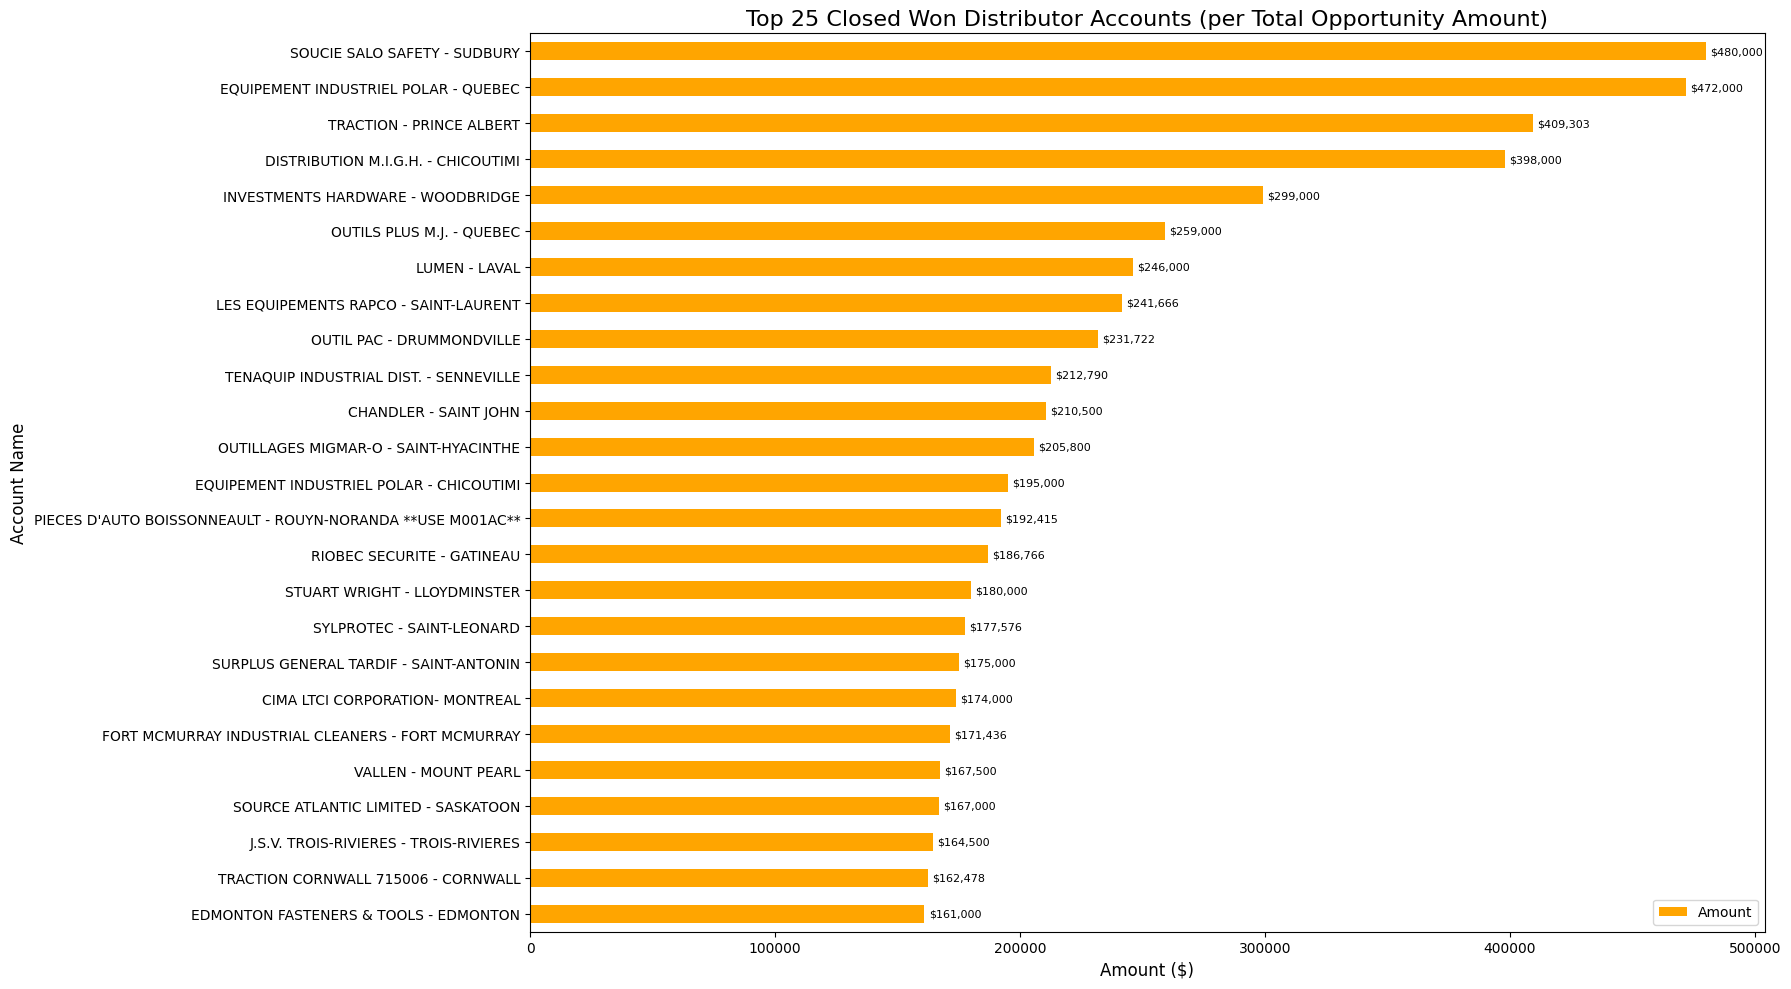

In [30]:
# Filter data for Distributors and Closed Won stage
df_distributor_won = df[(df['Type'] == 'Distributor') & (df['Stage'] == 'Closed Won')]

# Group by and sum Amount and Expected Revenue
df_distributor_won_grouped = df_distributor_won.groupby('AccountName')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Sort by Amount in ascending order and select the last 25 accounts
df_distributor_bottom25 = df_distributor_won_grouped.sort_values(by='Amount', ascending=True).tail(25)

# Create a larger figure size
fig, ax = plt.subplots(figsize=(18, 10))

# Create a horizontal bar plot comparing Amount vs Expected Revenue for the bottom 25 accounts
df_distributor_bottom25.set_index('AccountName')[['Amount']].plot(kind='barh', color=['orange', 'green'], ax=ax)

# Add values to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', label_type='edge', fontsize=8, padding=3)

# Add title and labels
ax.set_title('Top 25 Closed Won Distributor Accounts (per Total Opportunity Amount)', fontsize=16)
ax.set_xlabel('Amount ($)', fontsize=12)
ax.set_ylabel('Account Name', fontsize=12)

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()


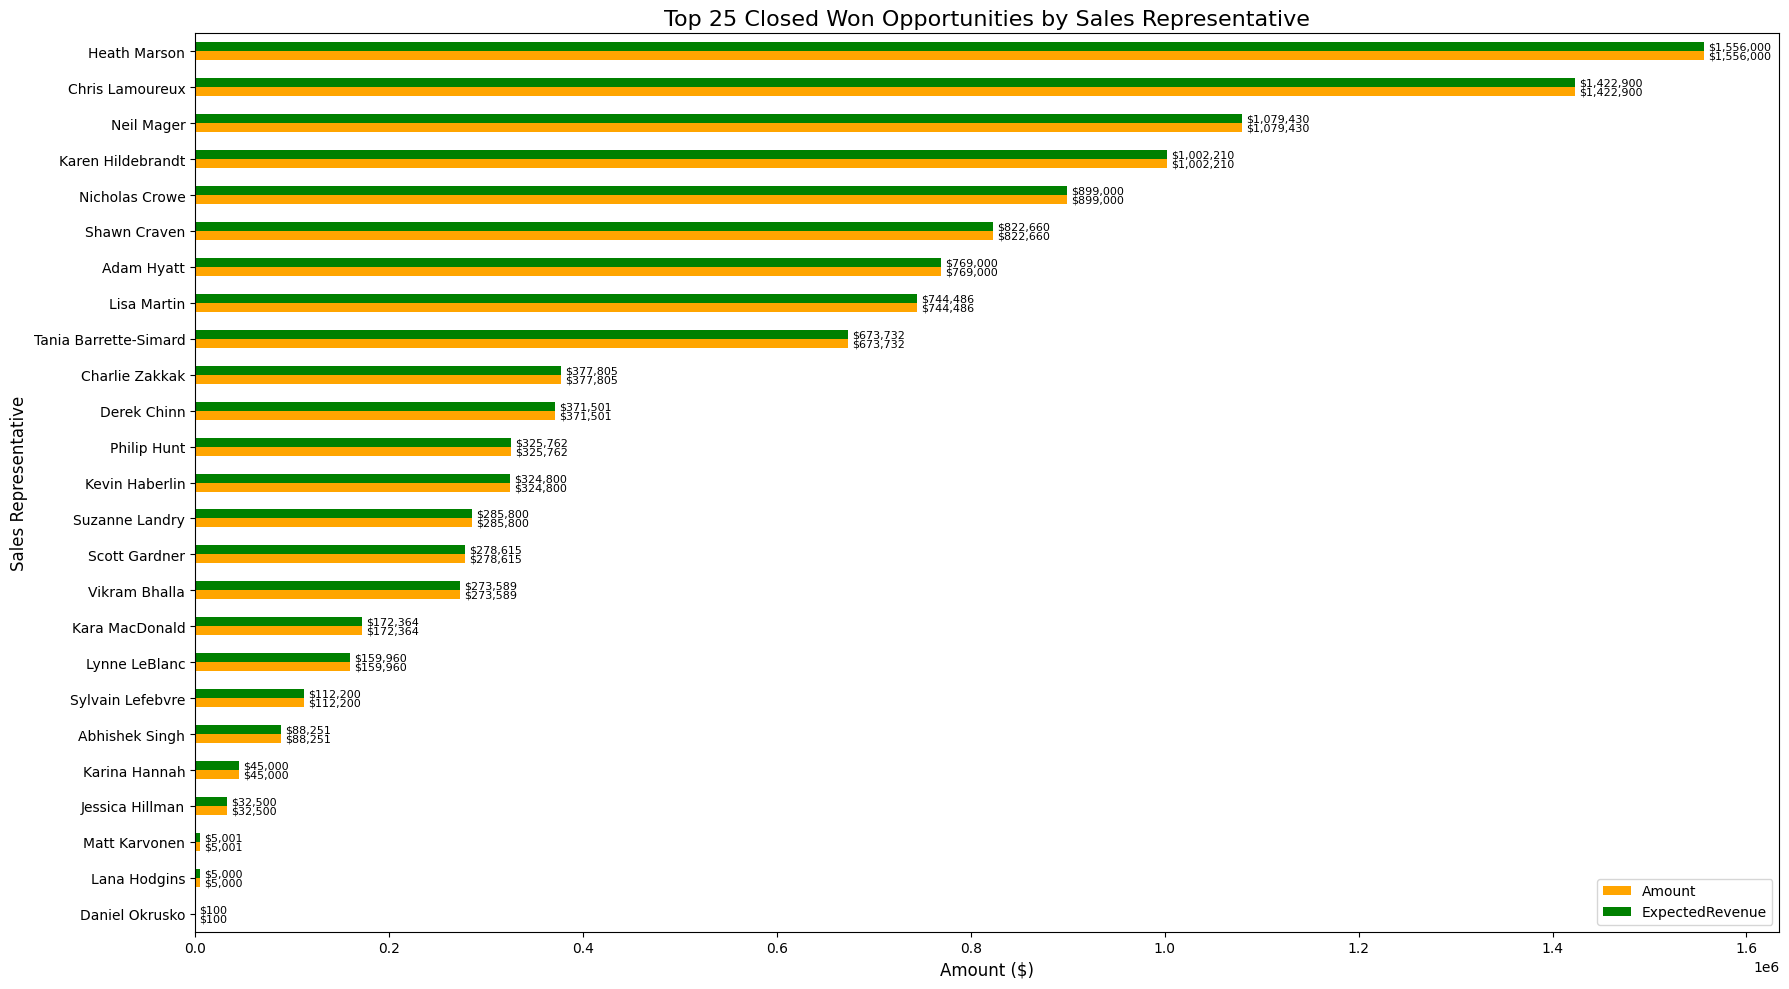

In [31]:
# Filter data for Closed Won opportunities
df_closed_won = df[df['Stage'] == 'Closed Won']

# Group by OpportunityOwner and sum Amount and Expected Revenue
df_closed_won_grouped = df_closed_won.groupby('OpportunityOwner')[['Amount', 'ExpectedRevenue']].sum().reset_index()

# Sort by Amount in ascending order and select the top 25 opportunity owners
df_closed_won_top25 = df_closed_won_grouped.sort_values(by='Amount', ascending=True).head(25)

# Create a larger figure size
fig, ax = plt.subplots(figsize=(18, 10))

# Create a horizontal bar plot comparing Amount vs Expected Revenue for the top 25 opportunity owners
df_closed_won_top25.set_index('OpportunityOwner')[['Amount', 'ExpectedRevenue']].plot(kind='barh', color=['orange', 'green'], ax=ax)

# Add values to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', label_type='edge', fontsize=8, padding=3)

# Add title and labels
ax.set_title('Top 25 Closed Won Opportunities by Sales Representative', fontsize=16)
ax.set_xlabel('Amount ($)', fontsize=12)
ax.set_ylabel('Sales Representative', fontsize=12)

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()


In [32]:
# # Filter the top 50 opportunities by Amount
# top_50_high_amount = df.nlargest(10, 'Amount')

# # Plot top 50 highest amount opportunities by owners
# plt.figure(figsize=(18, 8))
# sns.barplot(data=top_50_high_amount, x='Amount', y='OpportunityOwner', orient='h')
# for i, value in enumerate(top_50_high_amount['Amount']):
#     plt.text(value, i, f'{value:,.0f}', va='center')
# plt.title('Top 10 Highest Amount Opportunities by Owners')
# plt.show()


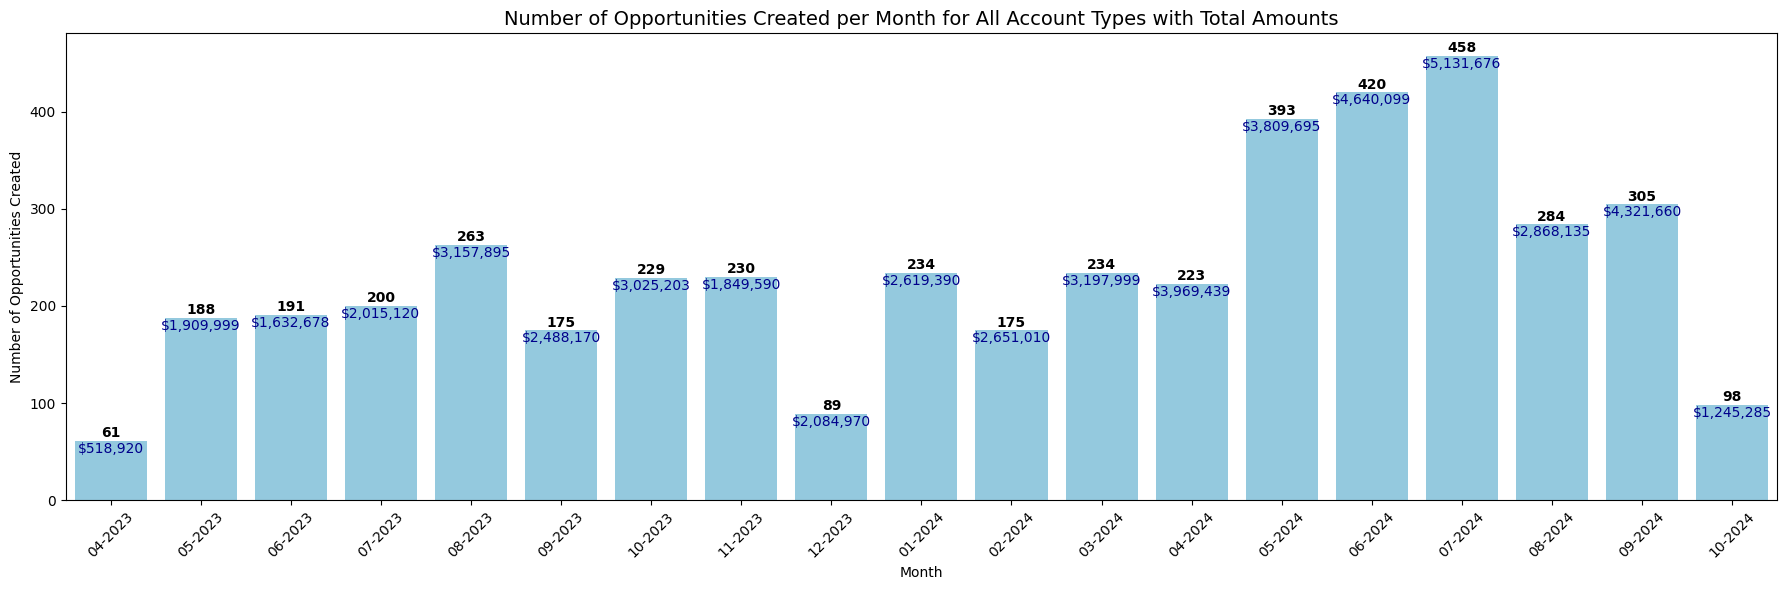

In [33]:
# Ensure CreatedDate is in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])

# Group by the month of CreatedDate and count the number of opportunities and sum the total amount for each month
monthly_opps = df.groupby(df['CreatedDate'].dt.to_period('M')).agg(
    OpportunitiesCreated=('OpportunityID', 'count'),  # Count of opportunities
    TotalAmount=('Amount', 'sum')  # Sum of Amounts
).reset_index()

# Convert CreatedDate back to a datetime object for plotting
monthly_opps['CreatedDate'] = monthly_opps['CreatedDate'].dt.to_timestamp()

# Format the CreatedDate as MM-YYYY for the x-axis labels
monthly_opps['MonthYear'] = monthly_opps['CreatedDate'].dt.strftime('%m-%Y')

# Plot the number of opportunities created per month
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_opps, x='MonthYear', y='OpportunitiesCreated', color='skyblue')

# Annotate the values on top of each bar with the number of opportunities and total amount below it
for i, row in monthly_opps.iterrows():
    # Annotating the number of opportunities
    plt.text(i, row['OpportunitiesCreated'] + 0.5, f'{row["OpportunitiesCreated"]}', ha='center', va='bottom', fontweight='bold')
    # Annotating the total amount just below the count
    plt.text(i, row['OpportunitiesCreated'] - 1, f'${row["TotalAmount"]:,.0f}', ha='center', va='top', fontsize=10, color='darkblue')

# Add titles and labels
plt.title('Number of Opportunities Created per Month for All Account Types with Total Amounts', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Opportunities Created')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


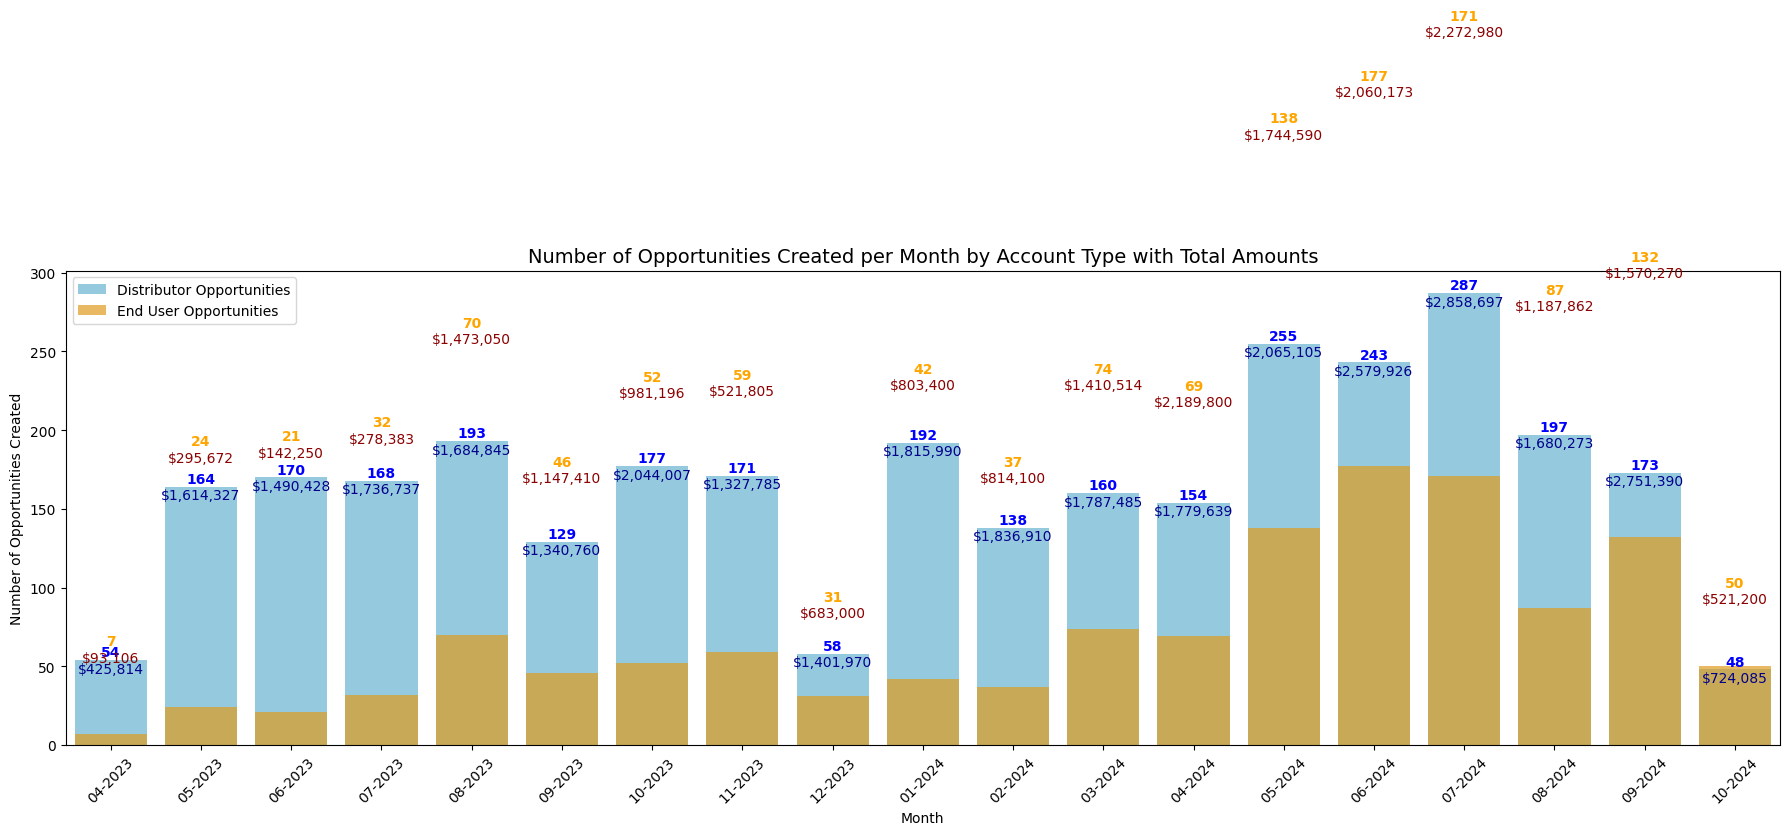

In [34]:
# Ensure CreatedDate is in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])

# Filter data for Distributor and End User separately
df_distributor = df[df['Type'] == 'Distributor']
df_end_user = df[df['Type'] == 'End User']

# Group by the month of CreatedDate and count the number of opportunities and sum the total amount for each month for Distributor
monthly_distributor_opps = df_distributor.groupby(df_distributor['CreatedDate'].dt.to_period('M')).agg(
    DistributorOpportunitiesCreated=('OpportunityID', 'count'),  # Count of Distributor opportunities
    DistributorTotalAmount=('Amount', 'sum')  # Sum of Distributor Amounts
).reset_index()

# Group by the month of CreatedDate and count the number of opportunities and sum the total amount for each month for End User
monthly_end_user_opps = df_end_user.groupby(df_end_user['CreatedDate'].dt.to_period('M')).agg(
    EndUserOpportunitiesCreated=('OpportunityID', 'count'),  # Count of End User opportunities
    EndUserTotalAmount=('Amount', 'sum')  # Sum of End User Amounts
).reset_index()

# Merge the Distributor and End User dataframes
monthly_opps = pd.merge(monthly_distributor_opps, monthly_end_user_opps, on='CreatedDate', how='outer').fillna(0)

# Convert CreatedDate back to a datetime object for plotting
monthly_opps['CreatedDate'] = monthly_opps['CreatedDate'].dt.to_timestamp()

# Format the CreatedDate as MM-YYYY for the x-axis labels
monthly_opps['MonthYear'] = monthly_opps['CreatedDate'].dt.strftime('%m-%Y')

# Plot the number of opportunities created per month for Distributor and End User
plt.figure(figsize=(18, 10))

# Plot for Distributor
bar1 = sns.barplot(data=monthly_opps, x='MonthYear', y='DistributorOpportunitiesCreated', color='skyblue', label='Distributor Opportunities')

# Plot for End User on the same bar with different color
bar2 = sns.barplot(data=monthly_opps, x='MonthYear', y='EndUserOpportunitiesCreated', color='orange', alpha=0.7, label='End User Opportunities')

# Annotate the values on top of each bar with the number of opportunities and total amount below it
for i, row in monthly_opps.iterrows():
    # Annotating the number of Distributor opportunities
    plt.text(i, row['DistributorOpportunitiesCreated'] + 0.5, f'{row["DistributorOpportunitiesCreated"]}', ha='center', va='bottom', fontweight='bold', color='blue')
    # Annotating the Distributor total amount just below the count
    plt.text(i, row['DistributorOpportunitiesCreated'] - 1, f'${row["DistributorTotalAmount"]:,.0f}', ha='center', va='top', fontsize=10, color='darkblue')
    # Annotating the number of End User opportunities
    plt.text(i, row['DistributorOpportunitiesCreated'] + row['EndUserOpportunitiesCreated'] + 0.5, f'{row["EndUserOpportunitiesCreated"]}', ha='center', va='bottom', fontweight='bold', color='orange')
    # Annotating the End User total amount just below the count
    plt.text(i, row['DistributorOpportunitiesCreated'] + row['EndUserOpportunitiesCreated'] - 1, f'${row["EndUserTotalAmount"]:,.0f}', ha='center', va='top', fontsize=10, color='darkred')

# Add titles and labels
plt.title('Number of Opportunities Created per Month by Account Type with Total Amounts', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Opportunities Created')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


In [35]:
# Ensure CreatedDate is in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])

# Group by the month of CreatedDate and Type (End User, Distributor) and sum the total amount
monthly_opps_by_type = df.groupby([df['CreatedDate'].dt.to_period('M'), 'Type']).agg(
    TotalAmount=('Amount', 'sum')  # Sum of Amounts
).reset_index()

# Convert CreatedDate back to a datetime object for easier interpretation
monthly_opps_by_type['CreatedDate'] = monthly_opps_by_type['CreatedDate'].dt.to_timestamp()

# Print the monthly amounts for End User and Distributor separately
for month in monthly_opps_by_type['CreatedDate'].unique():
    print(f"Month: {month.strftime('%m-%Y')}")
    
    # Filter the data for the current month
    monthly_data = monthly_opps_by_type[monthly_opps_by_type['CreatedDate'] == month]
    
    # Print details for End User and Distributor
    for _, row in monthly_data.iterrows():
        print(f"  Type: {row['Type']}, Total Amount: ${row['TotalAmount']:,.0f}")
    
    print("-" * 40)  # Separator between months

Month: 04-2023
  Type: Distributor, Total Amount: $425,814
  Type: End User, Total Amount: $93,106
----------------------------------------
Month: 05-2023
  Type: Distributor, Total Amount: $1,614,327
  Type: End User, Total Amount: $295,672
----------------------------------------
Month: 06-2023
  Type: Distributor, Total Amount: $1,490,428
  Type: End User, Total Amount: $142,250
----------------------------------------
Month: 07-2023
  Type: Distributor, Total Amount: $1,736,737
  Type: End User, Total Amount: $278,383
----------------------------------------
Month: 08-2023
  Type: Distributor, Total Amount: $1,684,845
  Type: End User, Total Amount: $1,473,050
----------------------------------------
Month: 09-2023
  Type: Distributor, Total Amount: $1,340,760
  Type: End User, Total Amount: $1,147,410
----------------------------------------
Month: 10-2023
  Type: Distributor, Total Amount: $2,044,007
  Type: End User, Total Amount: $981,196
---------------------------------------

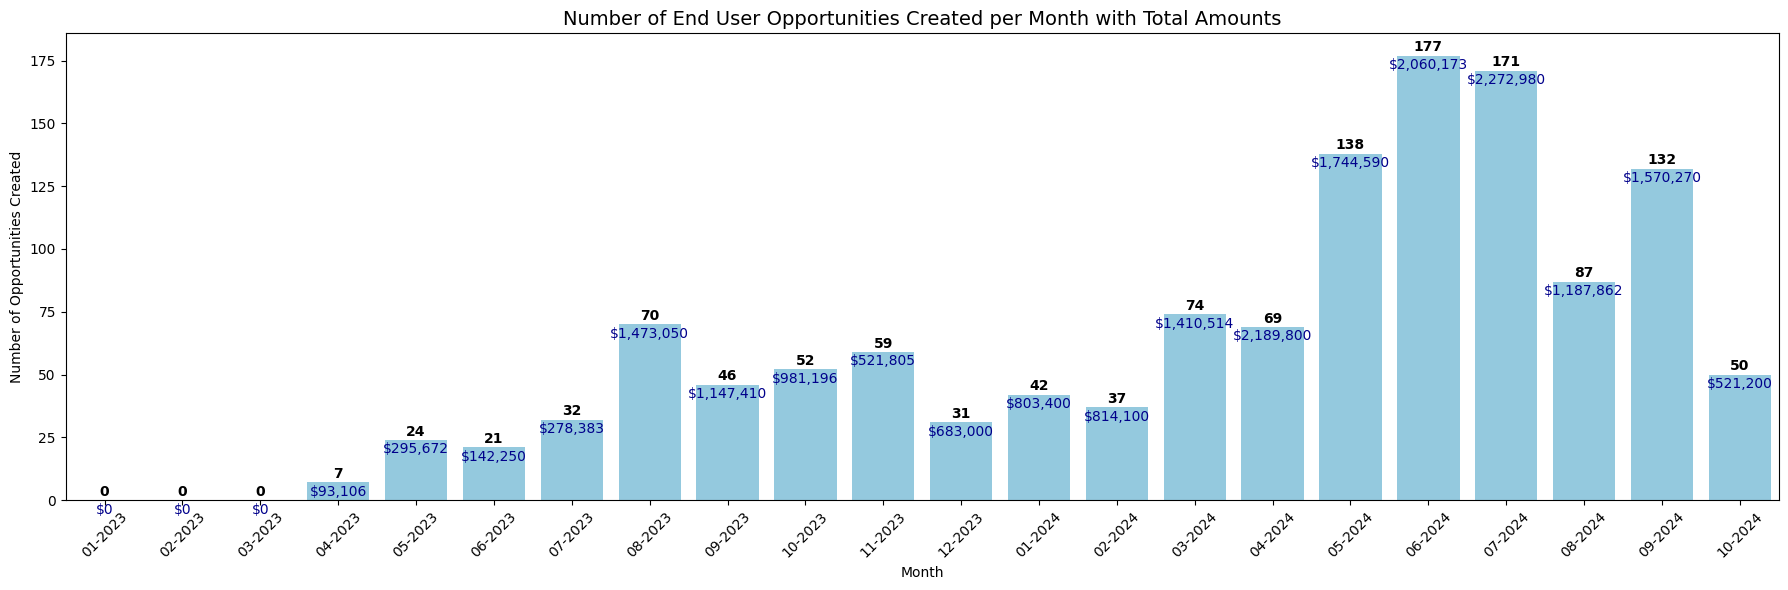

In [36]:
# Ensure CreatedDate is in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])

# Filter for End User opportunities
end_user_df = df[df['Type'] == 'End User']

# Group by the month of CreatedDate and count the number of opportunities and sum the total amount for End User
monthly_end_user_opps = end_user_df.groupby(end_user_df['CreatedDate'].dt.to_period('M')).agg(
    OpportunitiesCreated=('OpportunityID', 'count'),  # Count of opportunities
    TotalAmount=('Amount', 'sum')  # Sum of Amounts
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', monthly_end_user_opps['CreatedDate'].max(), freq='M')

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CreatedDate': all_months})
monthly_end_user_opps = full_monthly_opps.merge(monthly_end_user_opps, on='CreatedDate', how='left').fillna({'OpportunitiesCreated': 0, 'TotalAmount': 0})

# Convert CreatedDate to timestamp and format as MM-YYYY for display
monthly_end_user_opps['MonthYear'] = monthly_end_user_opps['CreatedDate'].dt.strftime('%m-%Y')

# Plot the number of opportunities created per month
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_end_user_opps, x='MonthYear', y='OpportunitiesCreated', color='skyblue')

# Annotate the values on top of each bar with the number of opportunities and total amount below it
for i, row in monthly_end_user_opps.iterrows():
    plt.text(i, row['OpportunitiesCreated'] + 0.5, f'{int(row["OpportunitiesCreated"])}', ha='center', va='bottom', fontweight='bold')
    plt.text(i, row['OpportunitiesCreated'] - 1, f'${row["TotalAmount"]:,.0f}', ha='center', va='top', fontsize=10, color='darkblue')

# Add titles and labels
plt.title('Number of End User Opportunities Created per Month with Total Amounts', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Opportunities Created')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


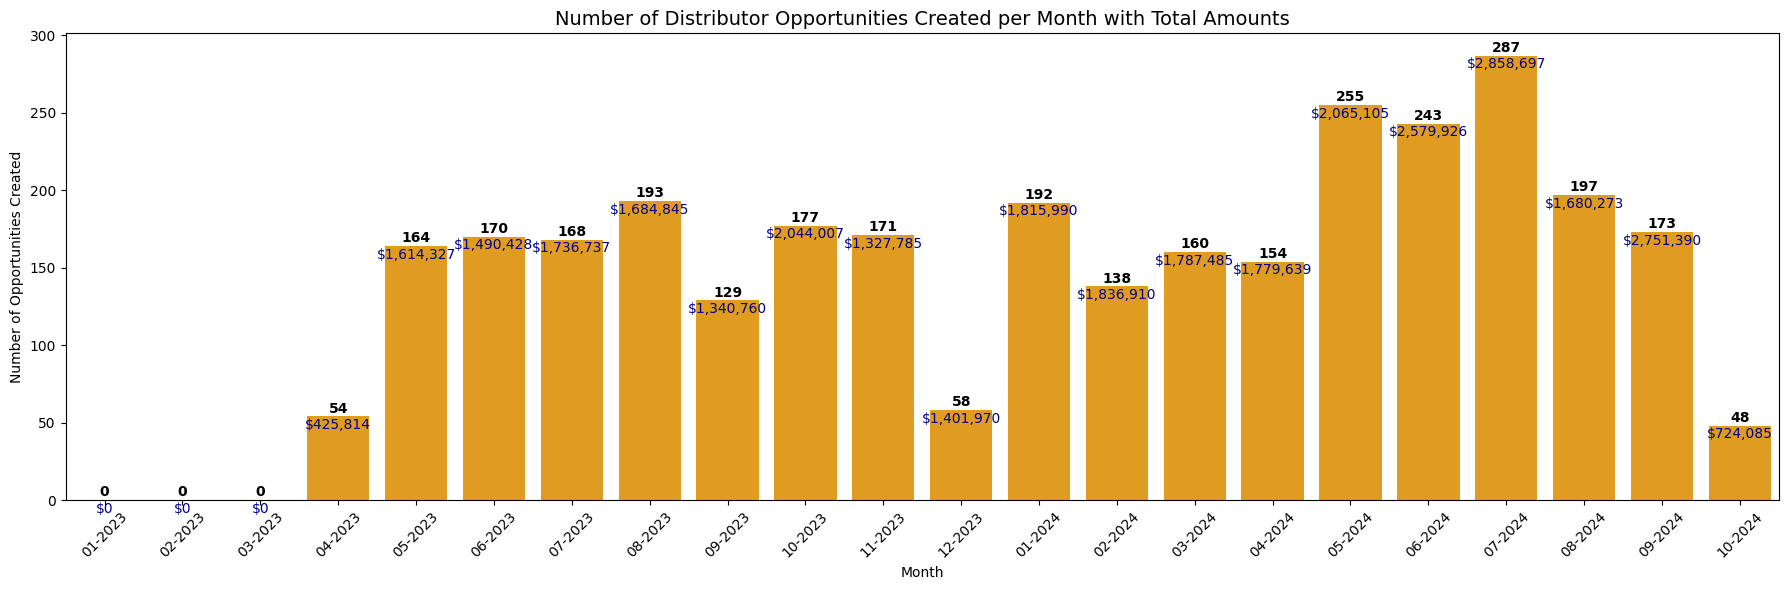

In [37]:
# Ensure CreatedDate is in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])

# Filter for Distributor opportunities
distributor_df = df[df['Type'] == 'Distributor']

# Group by the month of CreatedDate and count the number of opportunities and sum the total amount for Distributor
monthly_distributor_opps = distributor_df.groupby(distributor_df['CreatedDate'].dt.to_period('M')).agg(
    OpportunitiesCreated=('OpportunityID', 'count'),  # Count of opportunities
    TotalAmount=('Amount', 'sum')  # Sum of Amounts
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', monthly_distributor_opps['CreatedDate'].max(), freq='M')

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CreatedDate': all_months})
monthly_distributor_opps = full_monthly_opps.merge(monthly_distributor_opps, on='CreatedDate', how='left').fillna({'OpportunitiesCreated': 0, 'TotalAmount': 0})

# Format the CreatedDate to MM-YYYY for display purposes
monthly_distributor_opps['MonthYear'] = monthly_distributor_opps['CreatedDate'].dt.strftime('%m-%Y')

# Plot the number of opportunities created per month
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_distributor_opps, x='MonthYear', y='OpportunitiesCreated', color='orange')

# Annotate the values on top of each bar with the number of opportunities and total amount below it
for i, row in monthly_distributor_opps.iterrows():
    plt.text(i, row['OpportunitiesCreated'] + 0.5, f'{int(row["OpportunitiesCreated"])}', ha='center', va='bottom', fontweight='bold')
    plt.text(i, row['OpportunitiesCreated'] - 1, f'${row["TotalAmount"]:,.0f}', ha='center', va='top', fontsize=10, color='darkblue')

# Add titles and labels
plt.title('Number of Distributor Opportunities Created per Month with Total Amounts', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Opportunities Created')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


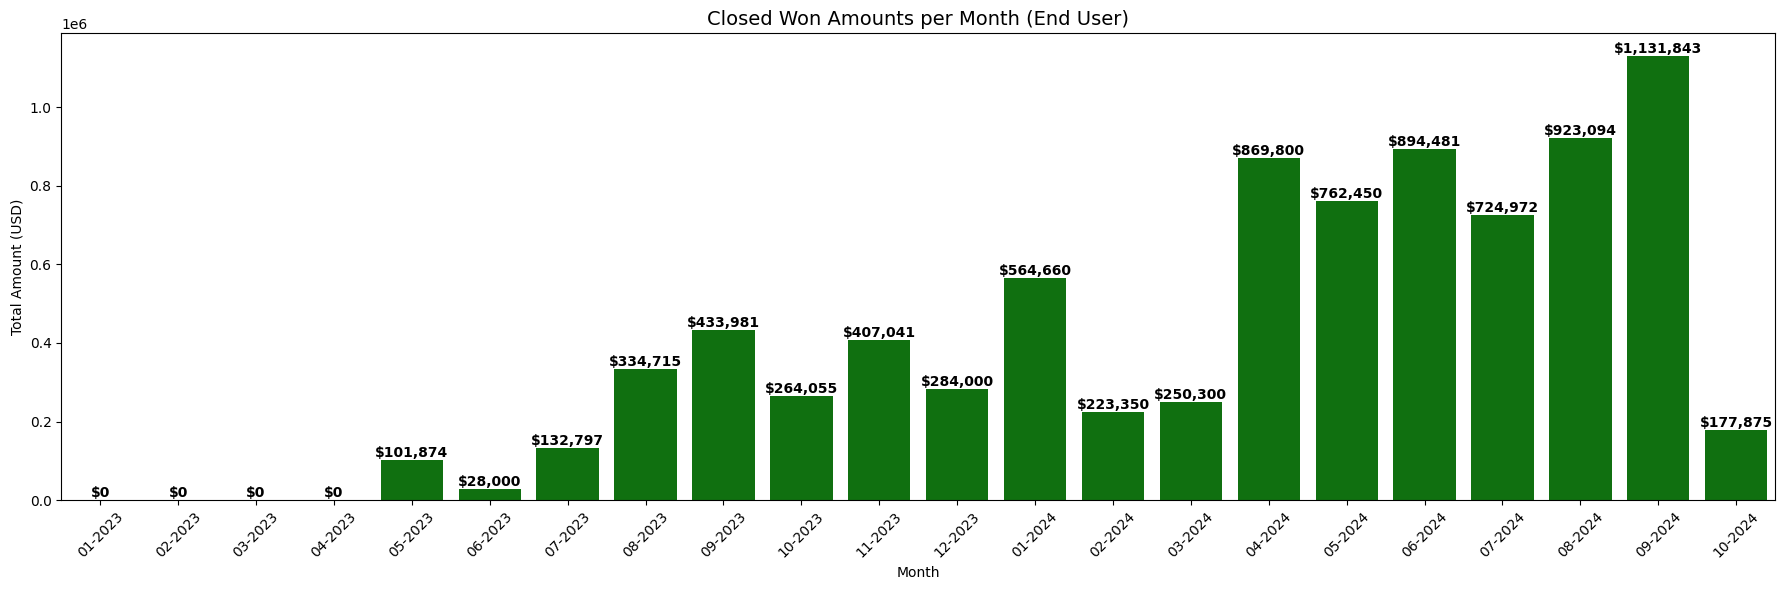

In [38]:
# Ensure CloseDate is in datetime format
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for End User opportunities and Closed Won stage
end_user_closed_won_df = df[(df['Type'] == 'End User') & (df['Stage'] == 'Closed Won')]

# Group by the month of CloseDate and sum the total amount for Closed Won End User
monthly_end_user_won = end_user_closed_won_df.groupby(end_user_closed_won_df['CloseDate'].dt.to_period('M')).agg(
    TotalAmount=('Amount', 'sum')
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', monthly_end_user_won['CloseDate'].max(), freq='M')

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CloseDate': all_months})
monthly_end_user_won = full_monthly_opps.merge(monthly_end_user_won, on='CloseDate', how='left').fillna({'TotalAmount': 0})

# Format the CloseDate to MM-YYYY for display purposes
monthly_end_user_won['MonthYear'] = monthly_end_user_won['CloseDate'].dt.strftime('%m-%Y')

# Remove November and December 2024 from the data to be visualized
monthly_end_user_won = monthly_end_user_won[~monthly_end_user_won['MonthYear'].isin(['11-2024', '12-2024'])]

# Plot the Closed Won amounts per month for End User
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_end_user_won, x='MonthYear', y='TotalAmount', color='green')

# Annotate the values on top of each bar with the total amount
for i, row in monthly_end_user_won.iterrows():
    plt.text(i, row['TotalAmount'] + 0.5, f'${row["TotalAmount"]:,.0f}', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Closed Won Amounts per Month (End User)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Amount (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


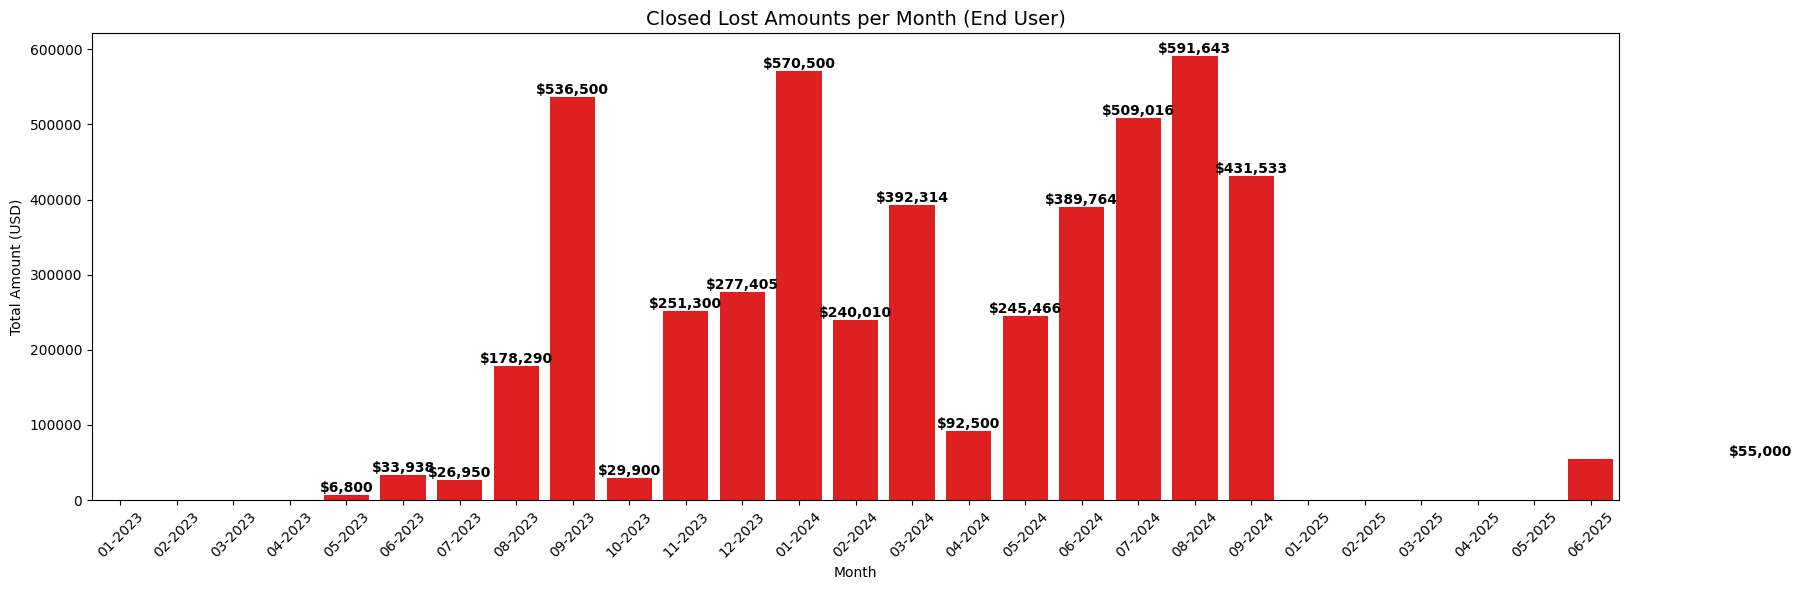

In [39]:
# Ensure CloseDate is in datetime format
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for End User opportunities and Closed Lost stage
end_user_closed_lost_df = df[(df['Type'] == 'End User') & (df['Stage'] == 'Closed Lost')]

# Group by the month of CloseDate and sum the total amount for Closed Lost End User
monthly_end_user_lost = end_user_closed_lost_df.groupby(end_user_closed_lost_df['CloseDate'].dt.to_period('M')).agg(
    TotalAmount=('Amount', 'sum')
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', monthly_end_user_lost['CloseDate'].max(), freq='M')

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CloseDate': all_months})
monthly_end_user_lost = pd.merge(full_monthly_opps, monthly_end_user_lost, on='CloseDate', how='left').fillna({'TotalAmount': 0})

# Format the CloseDate to MM-YYYY for display purposes
monthly_end_user_lost['MonthYear'] = monthly_end_user_lost['CloseDate'].dt.strftime('%m-%Y')

# Remove November and December 2024 from the data
monthly_end_user_lost = monthly_end_user_lost[~monthly_end_user_lost['MonthYear'].isin(['10-2024', '11-2024', '12-2024'])]

# Plot the Closed Lost amounts per month for End User
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_end_user_lost, x='MonthYear', y='TotalAmount', color='red')

# Annotate the values on top of each bar with the total amount
for i, row in monthly_end_user_lost.iterrows():
    if row['TotalAmount'] > 0:
        plt.text(i, row['TotalAmount'] + 0.5, f'${row["TotalAmount"]:,.0f}', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Closed Lost Amounts per Month (End User)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Amount (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


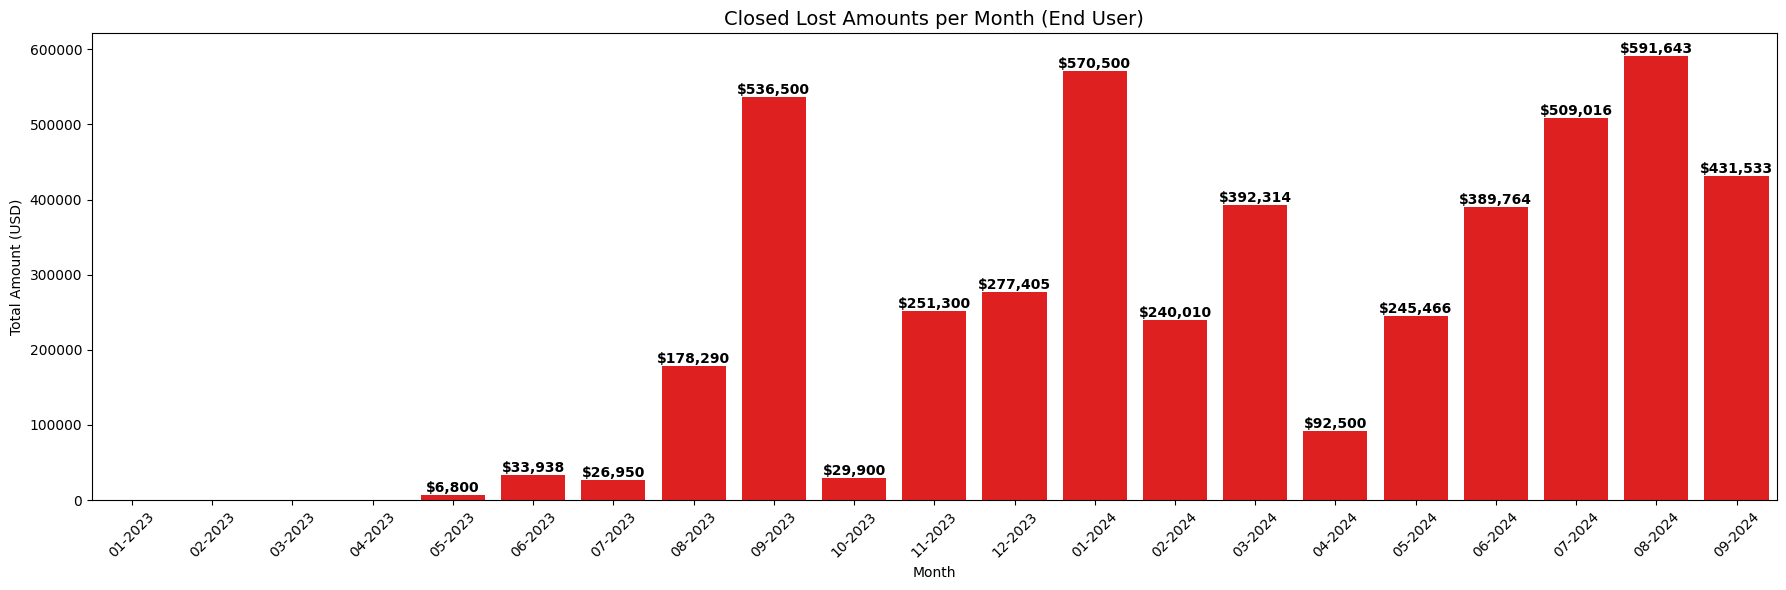

In [40]:
# Ensure CloseDate is in datetime format
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for End User opportunities and Closed Lost stage
end_user_closed_lost_df = df[(df['Type'] == 'End User') & (df['Stage'] == 'Closed Lost')]

# Group by the month of CloseDate and sum the total amount for Closed Lost End User
monthly_end_user_lost = end_user_closed_lost_df.groupby(end_user_closed_lost_df['CloseDate'].dt.to_period('M')).agg(
    TotalAmount=('Amount', 'sum')
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', '2024-09', freq='M')  # Set the latest date to '2024-10'

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CloseDate': all_months})
monthly_end_user_lost = pd.merge(full_monthly_opps, monthly_end_user_lost, on='CloseDate', how='left').fillna({'TotalAmount': 0})

# Format the CloseDate to MM-YYYY for display purposes
monthly_end_user_lost['MonthYear'] = monthly_end_user_lost['CloseDate'].dt.strftime('%m-%Y')

# Plot the Closed Lost amounts per month for End User
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_end_user_lost, x='MonthYear', y='TotalAmount', color='red')

# Annotate the values on top of each bar with the total amount
for i, row in monthly_end_user_lost.iterrows():
    if row['TotalAmount'] > 0:
        plt.text(i, row['TotalAmount'] + 0.5, f'${row["TotalAmount"]:,.0f}', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Closed Lost Amounts per Month (End User)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Amount (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


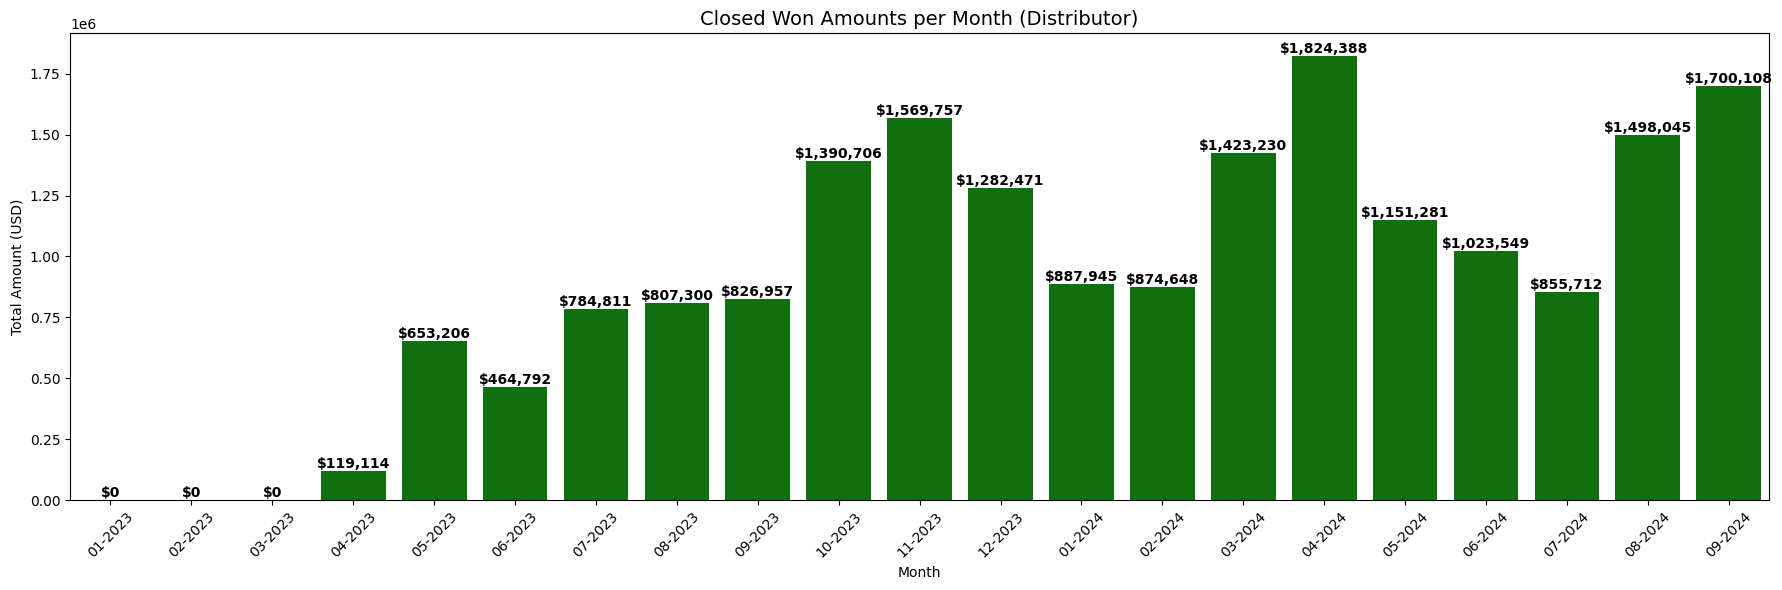

In [41]:
# Ensure CloseDate is in datetime format
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Distributor opportunities and Closed Won stage
distributor_closed_won_df = df[(df['Type'] == 'Distributor') & (df['Stage'] == 'Closed Won')]

# Group by the month of CloseDate and sum the total amount for Closed Won Distributor
monthly_distributor_won = distributor_closed_won_df.groupby(distributor_closed_won_df['CloseDate'].dt.to_period('M')).agg(
    TotalAmount=('Amount', 'sum')
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', monthly_distributor_won['CloseDate'].max(), freq='M')

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CloseDate': all_months})
monthly_distributor_won = full_monthly_opps.merge(monthly_distributor_won, on='CloseDate', how='left').fillna({'TotalAmount': 0})

# Format the CloseDate to MM-YYYY for display purposes
monthly_distributor_won['MonthYear'] = monthly_distributor_won['CloseDate'].dt.strftime('%m-%Y')

# Remove November and December 2024 from the data to be visualized
monthly_distributor_won = monthly_distributor_won[~monthly_distributor_won['MonthYear'].isin(['10-2024', '11-2024', '12-2024'])]

# Plot the Closed Won amounts per month for Distributor
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_distributor_won, x='MonthYear', y='TotalAmount', color='green')

# Annotate the values on top of each bar with the total amount
for i, row in monthly_distributor_won.iterrows():
    plt.text(i, row['TotalAmount'] + 0.5, f'${row["TotalAmount"]:,.0f}', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Closed Won Amounts per Month (Distributor)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Amount (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


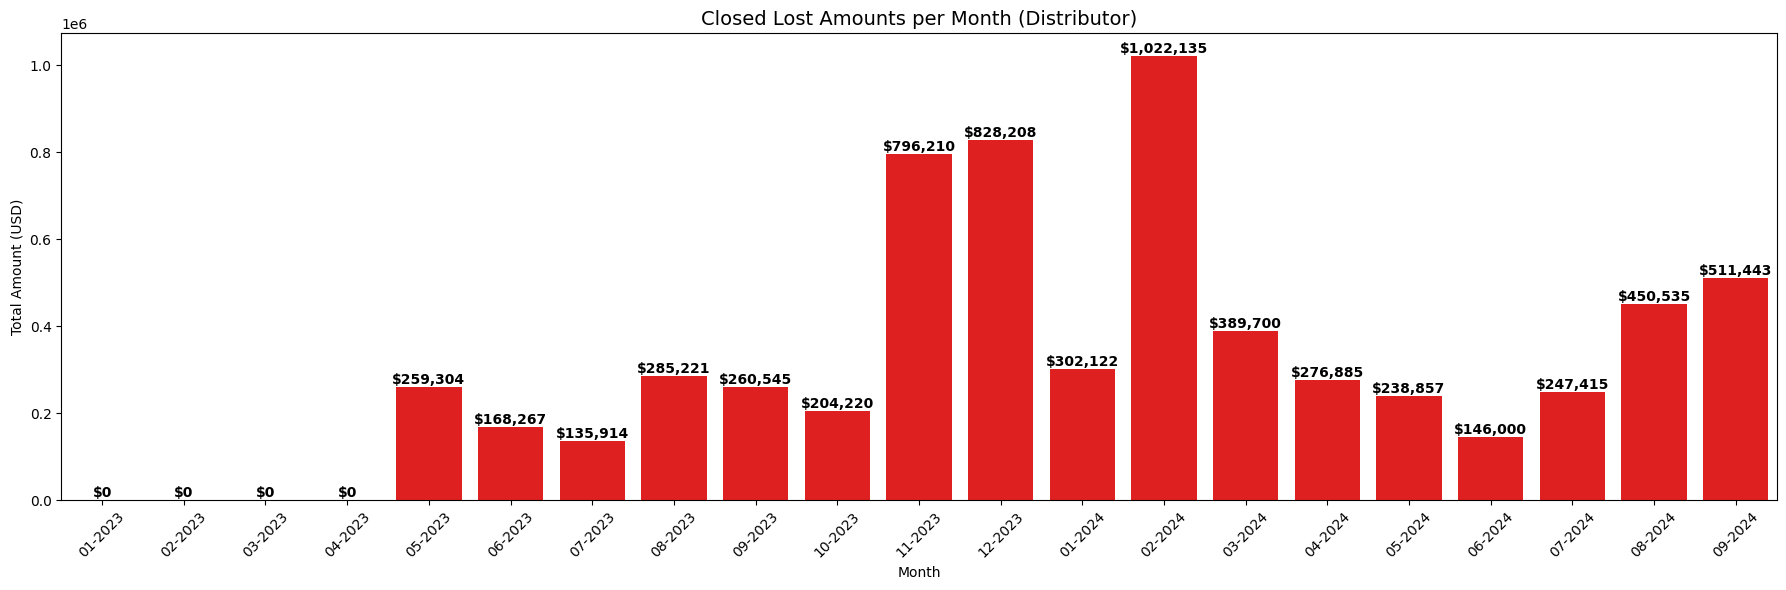

In [42]:
# Ensure CloseDate is in datetime format
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Distributor opportunities and Closed Lost stage
distributor_closed_lost_df = df[(df['Type'] == 'Distributor') & (df['Stage'] == 'Closed Lost')]

# Group by the month of CloseDate and sum the total amount for Closed Lost Distributor
monthly_distributor_lost = distributor_closed_lost_df.groupby(distributor_closed_lost_df['CloseDate'].dt.to_period('M')).agg(
    TotalAmount=('Amount', 'sum')
).reset_index()

# Generate a full range of months from 01-2023 to the latest month in the data
all_months = pd.period_range('2023-01', monthly_distributor_lost['CloseDate'].max(), freq='M')

# Create a DataFrame with all months and merge it with the actual data, filling missing values with 0
full_monthly_opps = pd.DataFrame({'CloseDate': all_months})
monthly_distributor_lost = full_monthly_opps.merge(monthly_distributor_lost, on='CloseDate', how='left').fillna({'TotalAmount': 0})

# Format the CloseDate to MM-YYYY for display purposes
monthly_distributor_lost['MonthYear'] = monthly_distributor_lost['CloseDate'].dt.strftime('%m-%Y')

# Remove October, November, and December 2024 from the data to be visualized
monthly_distributor_lost = monthly_distributor_lost[~monthly_distributor_lost['MonthYear'].isin(['10-2024', '11-2024', '12-2024'])]

# Plot the Closed Lost amounts per month for Distributor
plt.figure(figsize=(18, 6))

sns.barplot(data=monthly_distributor_lost, x='MonthYear', y='TotalAmount', color='red')

# Annotate the values on top of each bar with the total amount
for i, row in monthly_distributor_lost.iterrows():
    plt.text(i, row['TotalAmount'] + 0.5, f'${row["TotalAmount"]:,.0f}', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Closed Lost Amounts per Month (Distributor)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Amount (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1451098622.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_days_per_stage, x='Stage', y='AvgDays', palette='coolwarm')


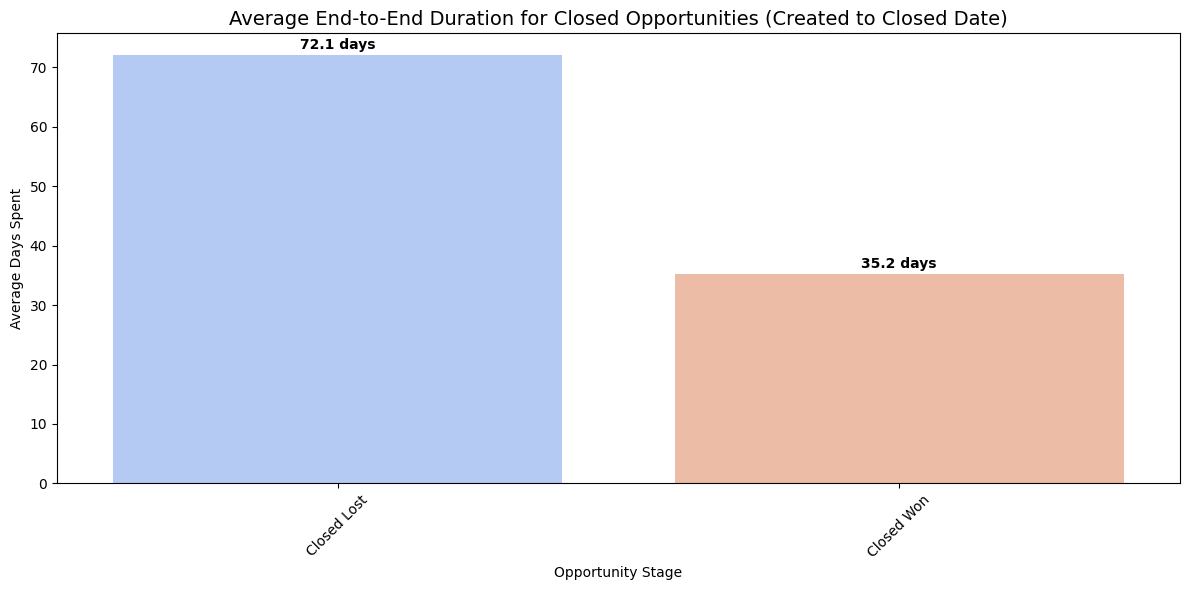

In [43]:
# Ensure CreatedDate and CloseDate are in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Calculate the duration in days between CloseDate and CreatedDate
df['DaysInStage'] = (df['CloseDate'] - df['CreatedDate']).dt.days

# Filter only closed stages (Closed Won, Closed Lost)
df_closed = df[df['Stage'].isin(['Closed Won', 'Closed Lost'])]

# Group by the Stage and calculate the average days spent in each stage
avg_days_per_stage = df_closed.groupby('Stage').agg(
    AvgDays=('DaysInStage', 'mean')
).reset_index()

# Plot the average days spent in each stage
plt.figure(figsize=(12, 6))

sns.barplot(data=avg_days_per_stage, x='Stage', y='AvgDays', palette='coolwarm')

# Annotate each bar with the average number of days
for i, row in avg_days_per_stage.iterrows():
    plt.text(i, row['AvgDays'] + 0.5, f'{row["AvgDays"]:.1f} days', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Average End-to-End Duration for Closed Opportunities (Created to Closed Date)', fontsize=14)
plt.xlabel('Opportunity Stage')
plt.ylabel('Average Days Spent')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2491546214.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_stage_duration, x='Stage', y='AvgDays', palette='coolwarm')


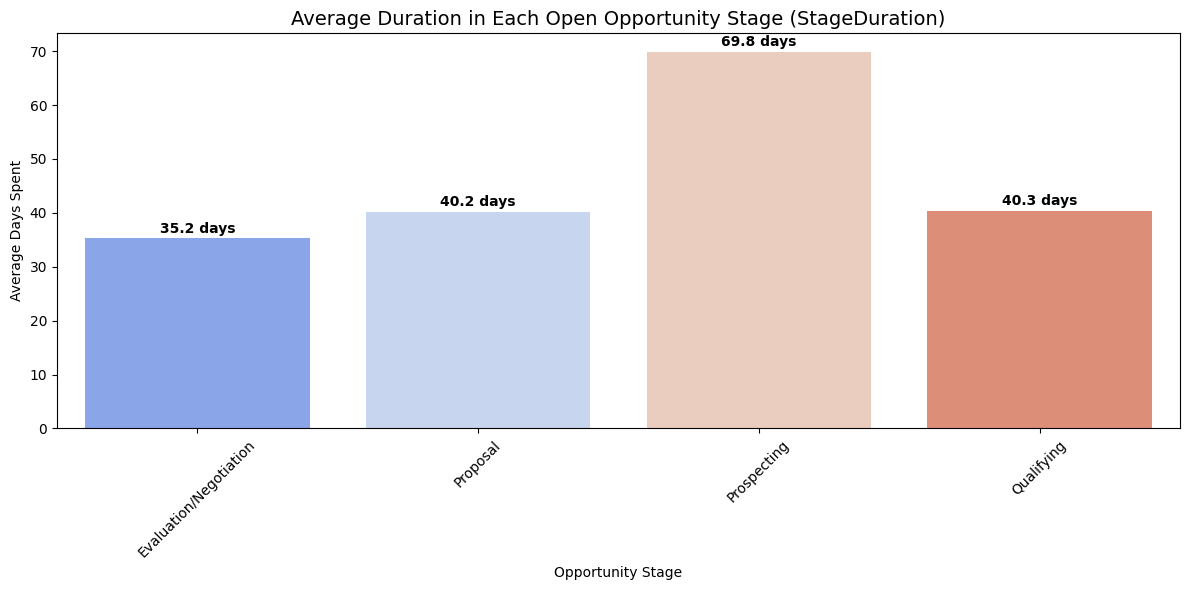

In [44]:
# Ensure CreatedDate is in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])

# Filter out closed stages
df_open = df[~df['Stage'].isin(['Closed Won', 'Closed Lost'])]

# Group by the Stage and calculate the average days spent in each stage using StageDuration
avg_stage_duration = df_open.groupby('Stage').agg(
    AvgDays=('StageDuration', 'mean')
).reset_index()

# Plot the average days spent in each open stage
plt.figure(figsize=(12, 6))

sns.barplot(data=avg_stage_duration, x='Stage', y='AvgDays', palette='coolwarm')

# Annotate each bar with the average number of days
for i, row in avg_stage_duration.iterrows():
    plt.text(i, row['AvgDays'] + 0.5, f'{row["AvgDays"]:.1f} days', ha='center', va='bottom', fontweight='bold')

# Add titles and labels
plt.title('Average Duration in Each Open Opportunity Stage (StageDuration)', fontsize=14)
plt.xlabel('Opportunity Stage')
plt.ylabel('Average Days Spent')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1059589158.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stages, y=average_days, palette='coolwarm')


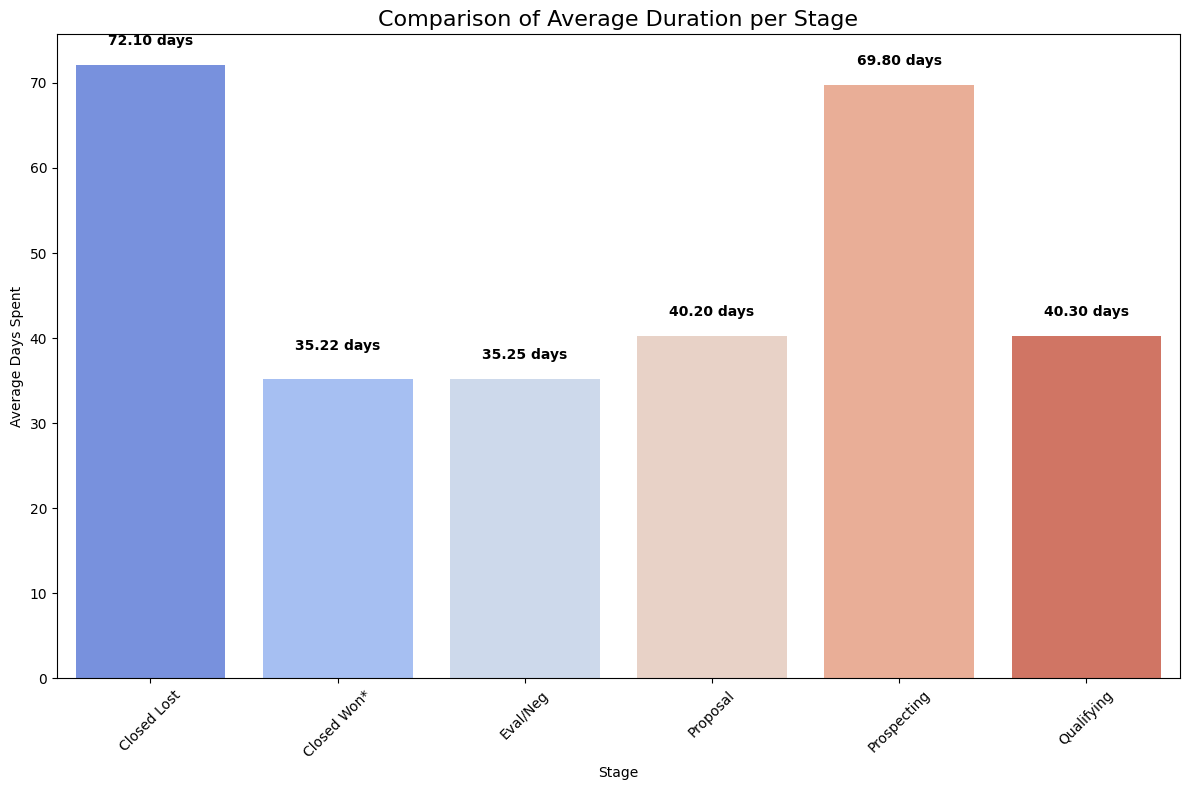

In [45]:
# Data: Average duration in days for each stage
stages = ['Closed Lost', 'Closed Won*', 'Eval/Neg', 'Proposal', 'Prospecting', 'Qualifying']
average_days = [72.1, 35.22, 35.25, 40.2, 69.8, 40.3]

# Plot the average duration per stage
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=stages, y=average_days, palette='coolwarm')

# Annotate each bar with the average number of days
for i, value in enumerate(average_days):
    # Add a condition to slightly offset the 35.22 and 35.25 values
    offset = 2 if value != 35.22 else 3  # Add extra offset to 35.22
    ax.text(i, value + offset, f'{value:.2f} days', color='black', ha='center', va='bottom', fontweight='bold')

# Customizing the plot
plt.title('Comparison of Average Duration per Stage', fontsize=16)
plt.xlabel('Stage')
plt.ylabel('Average Days Spent')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\76579877.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stages_canada, y=average_days_canada, palette='coolwarm', ax=ax1)
C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\76579877.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages_canada, rotation=45)
C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\76579877.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stages_us, y=average_days_us, palette='coolwarm', ax=ax2)
C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\76579877.py:29: UserWarning: set_ticklabels(

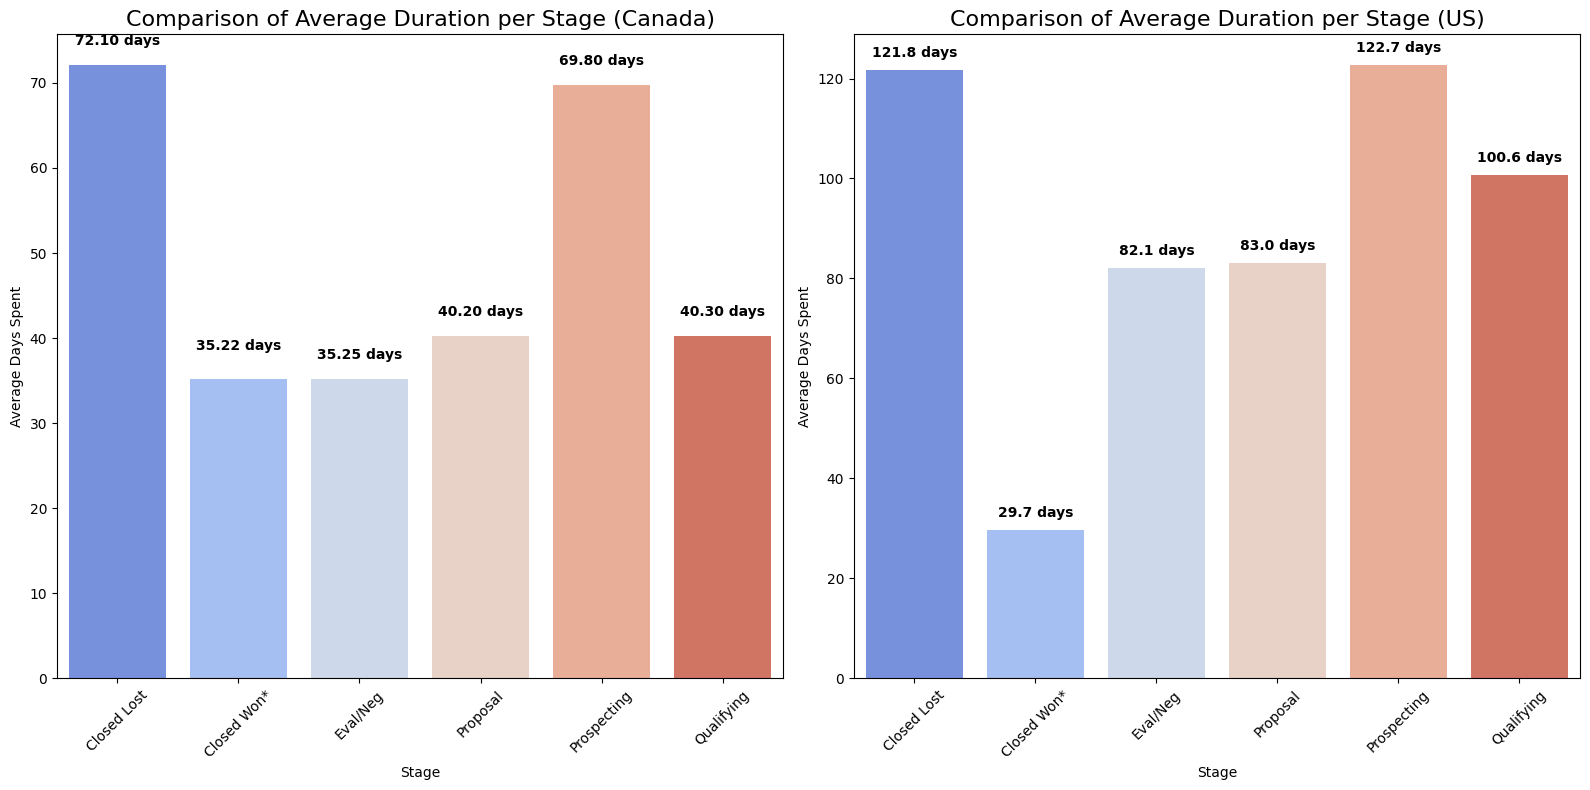

In [46]:
# Canada data
stages_canada = ['Closed Lost', 'Closed Won*', 'Eval/Neg', 'Proposal', 'Prospecting', 'Qualifying']
average_days_canada = [72.1, 35.22, 35.25, 40.2, 69.8, 40.3]

# US data
stages_us = ['Closed Lost', 'Closed Won*', 'Eval/Neg', 'Proposal', 'Prospecting', 'Qualifying']
average_days_us = [121.8, 29.7, 82.1, 83, 122.7, 100.6]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Canada Plot
sns.barplot(x=stages_canada, y=average_days_canada, palette='coolwarm', ax=ax1)
ax1.set_title('Comparison of Average Duration per Stage (Canada)', fontsize=16)
ax1.set_xlabel('Stage')
ax1.set_ylabel('Average Days Spent')
for i, value in enumerate(average_days_canada):
    offset = 2 if value != 35.22 else 3  # Add extra offset to 35.22
    ax1.text(i, value + offset, f'{value:.2f} days', color='black', ha='center', va='bottom', fontweight='bold')
ax1.set_xticklabels(stages_canada, rotation=45)

# US Plot
sns.barplot(x=stages_us, y=average_days_us, palette='coolwarm', ax=ax2)
ax2.set_title('Comparison of Average Duration per Stage (US)', fontsize=16)
ax2.set_xlabel('Stage')
ax2.set_ylabel('Average Days Spent')
for i, value in enumerate(average_days_us):
    ax2.text(i, value + 2, f'{value:.1f} days', color='black', ha='center', va='bottom', fontweight='bold')
ax2.set_xticklabels(stages_us, rotation=45)

# Adjust layout to fit both plots
plt.tight_layout()
plt.show()


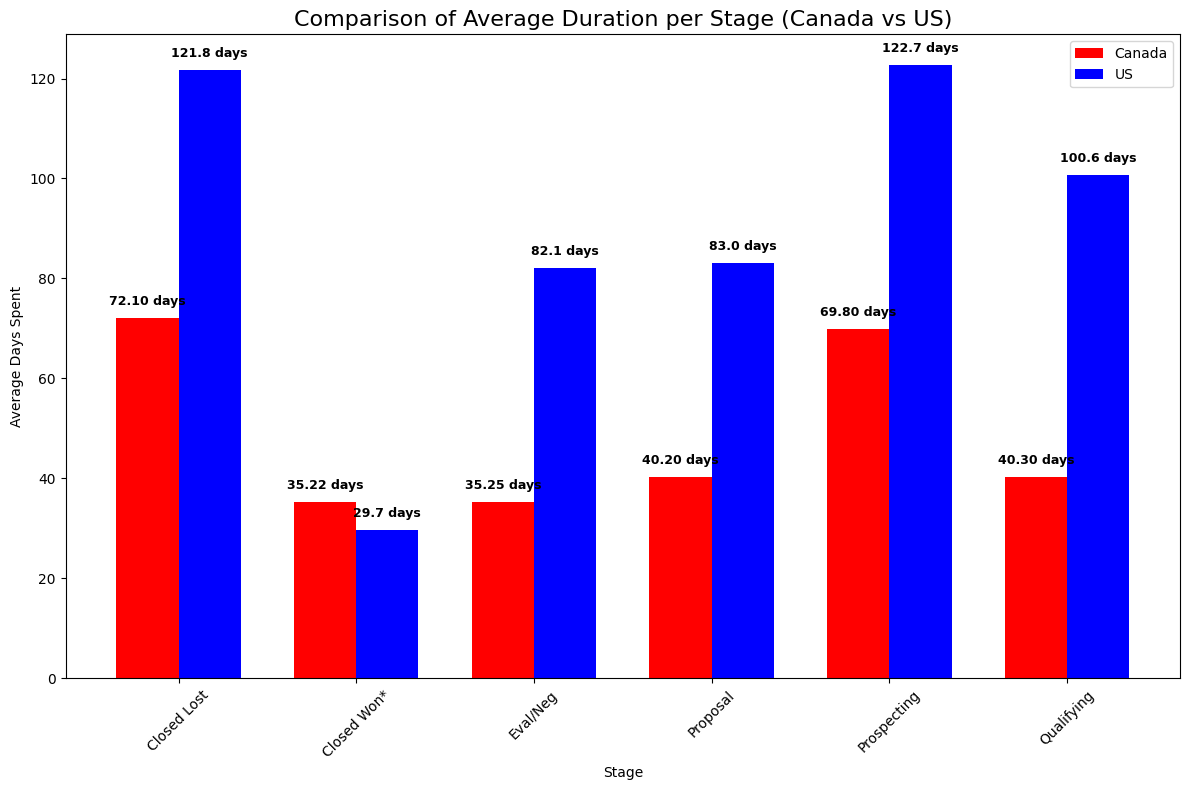

In [47]:
# Data for both Canada and US
stages = ['Closed Lost', 'Closed Won*', 'Eval/Neg', 'Proposal', 'Prospecting', 'Qualifying']
average_days_canada = [72.1, 35.22, 35.25, 40.2, 69.8, 40.3]
average_days_us = [121.8, 29.7, 82.1, 83, 122.7, 100.6]

# Set up the figure
plt.figure(figsize=(12, 8))

# Calculate the positions for the bars
x = np.arange(len(stages))
width = 0.35  # width of the bars

# Plot bars for Canada (red) and US (blue)
bars_canada = plt.bar(x - width/2, average_days_canada, width, label='Canada', color='red')
bars_us = plt.bar(x + width/2, average_days_us, width, label='US', color='blue')

# Annotate the Canada bars
for bar in bars_canada:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.2f} days', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotate the US bars
for bar in bars_us:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f} days', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customizing the plot
plt.title('Comparison of Average Duration per Stage (Canada vs US)', fontsize=16)
plt.xlabel('Stage')
plt.ylabel('Average Days Spent')
plt.xticks(x, stages, rotation=45)

# Add legend
plt.legend()

# Adjust layout to fit the plot nicely
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1480438702.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unclosed_stages['Duration'] = unclosed_stages['StageDuration']
C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\1480438702.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closed_stages_df['Duration'] = (closed_stages_df['CloseDate'] - closed_stages_df['CreatedDate']).dt.days


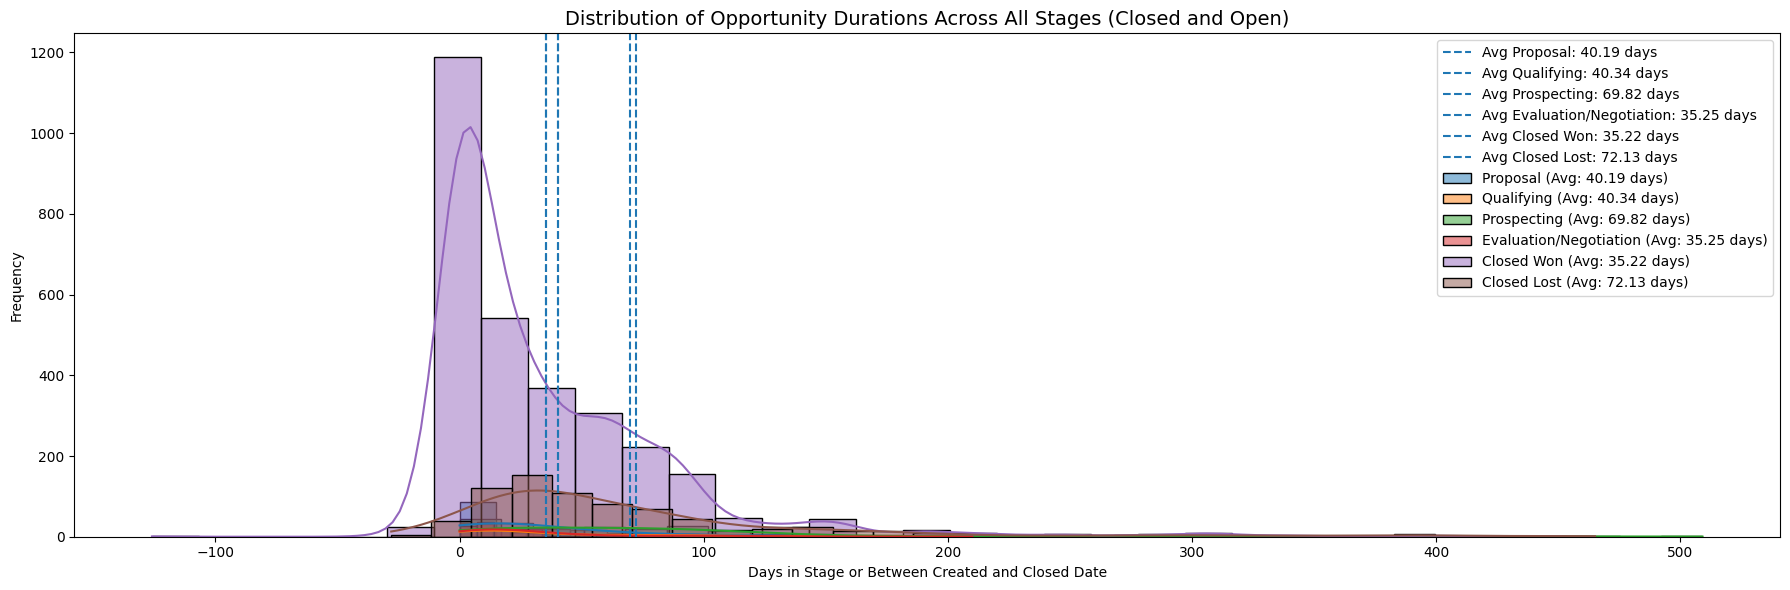

In [48]:
# Ensure CreatedDate and CloseDate are in datetime format
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter closed stages and unclosed stages
closed_stages = ['Closed Won', 'Closed Lost']
unclosed_stages = df[~df['Stage'].isin(closed_stages)]
closed_stages_df = df[df['Stage'].isin(closed_stages)]

# Use StageDuration for unclosed stages and CloseDate - CreatedDate for closed stages
unclosed_stages['Duration'] = unclosed_stages['StageDuration']
closed_stages_df['Duration'] = (closed_stages_df['CloseDate'] - closed_stages_df['CreatedDate']).dt.days

# Combine the data back together
df_combined = pd.concat([unclosed_stages, closed_stages_df])

# Plot the distribution of the opportunity durations for all stages
plt.figure(figsize=(18, 6))

# Create a histogram for each stage
for stage in df_combined['Stage'].unique():
    stage_data = df_combined[df_combined['Stage'] == stage]['Duration']
    sns.histplot(stage_data, bins=30, kde=True, label=f"{stage} (Avg: {stage_data.mean():.2f} days)")

# Add a vertical line for the average of each stage
for stage in df_combined['Stage'].unique():
    stage_data = df_combined[df_combined['Stage'] == stage]['Duration']
    plt.axvline(stage_data.mean(), linestyle='--', label=f'Avg {stage}: {stage_data.mean():.2f} days')

# Customizing the plot
plt.title('Distribution of Opportunity Durations Across All Stages (Closed and Open)', fontsize=14)
plt.xlabel('Days in Stage or Between Created and Closed Date')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_13012\2168725458.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_closed['TotalDuration'] = (df_closed['CloseDate'] - df_closed['CreatedDate']).dt.days


The average life-cycle duration for Closed Won and Closed Lost opportunities is 42.67 days.


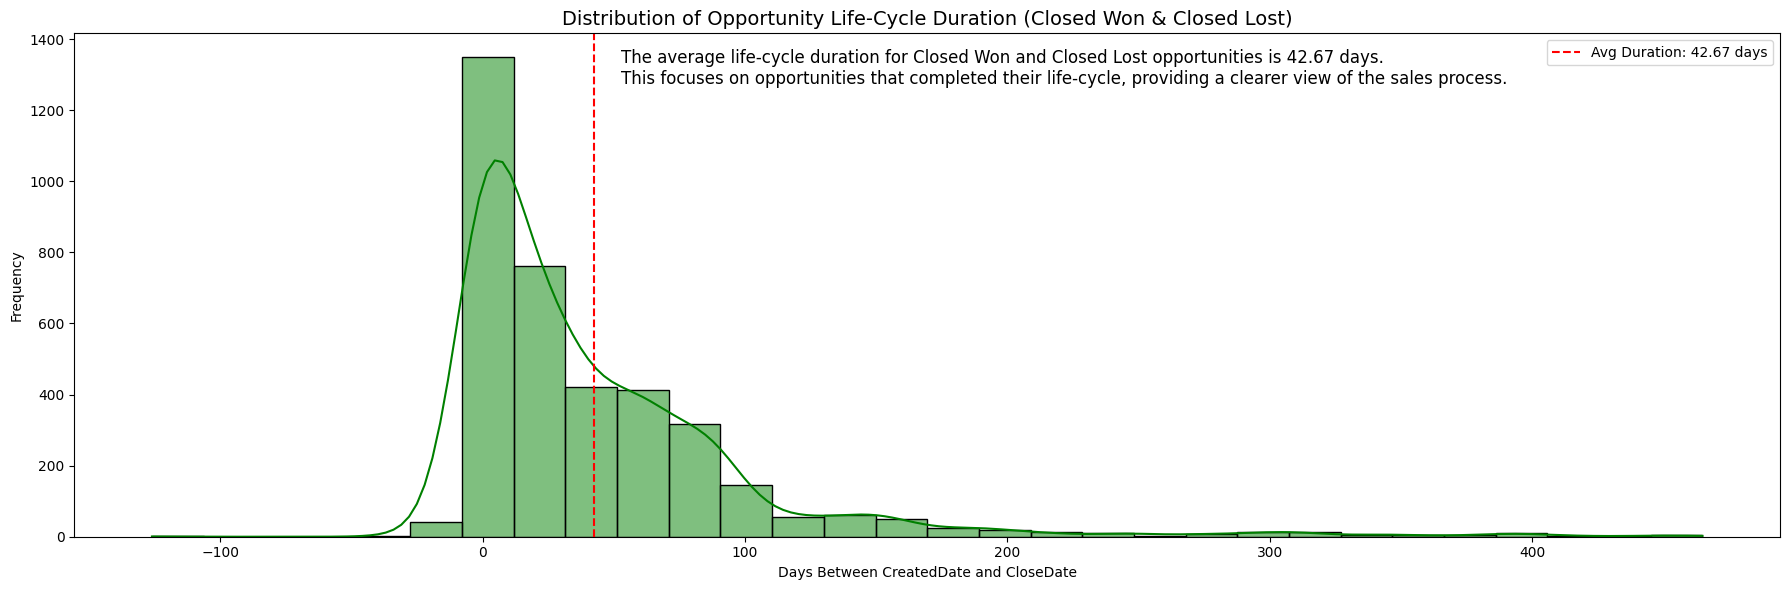

In [49]:
# Ensure CreatedDate and CloseDate are in datetime format (if not already done)
df['CreatedDate'] = pd.to_datetime(df['CreatedDate'])
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter to include only Closed Won and Closed Lost stages
closed_stages = ['Closed Won', 'Closed Lost']
df_closed = df[df['Stage'].isin(closed_stages)]

# Calculate the duration in days between CloseDate and CreatedDate for each opportunity
df_closed['TotalDuration'] = (df_closed['CloseDate'] - df_closed['CreatedDate']).dt.days

# Calculate the average total life-cycle duration for Closed Won and Closed Lost opportunities
avg_total_duration_closed = df_closed['TotalDuration'].mean()

# Print the average duration
print(f'The average life-cycle duration for Closed Won and Closed Lost opportunities is {avg_total_duration_closed:.2f} days.')

# Plot the distribution of life-cycle duration for closed opportunities
plt.figure(figsize=(18, 6))

sns.histplot(df_closed['TotalDuration'], bins=30, kde=True, color='green')

# Annotate the average duration on the plot
plt.axvline(avg_total_duration_closed, color='red', linestyle='--', label=f'Avg Duration: {avg_total_duration_closed:.2f} days')

# Add conclusion to the plot as text annotation
plt.text(avg_total_duration_closed + 10, plt.ylim()[1] * 0.9, 
         f'The average life-cycle duration for Closed Won and Closed Lost opportunities is {avg_total_duration_closed:.2f} days.\n'
         'This focuses on opportunities that completed their life-cycle, providing a clearer view of the sales process.',
         fontsize=12, color='black')

# Add titles and labels
plt.title('Distribution of Opportunity Life-Cycle Duration (Closed Won & Closed Lost)', fontsize=14)
plt.xlabel('Days Between CreatedDate and CloseDate')
plt.ylabel('Frequency')

plt.legend()
plt.tight_layout()
plt.show()



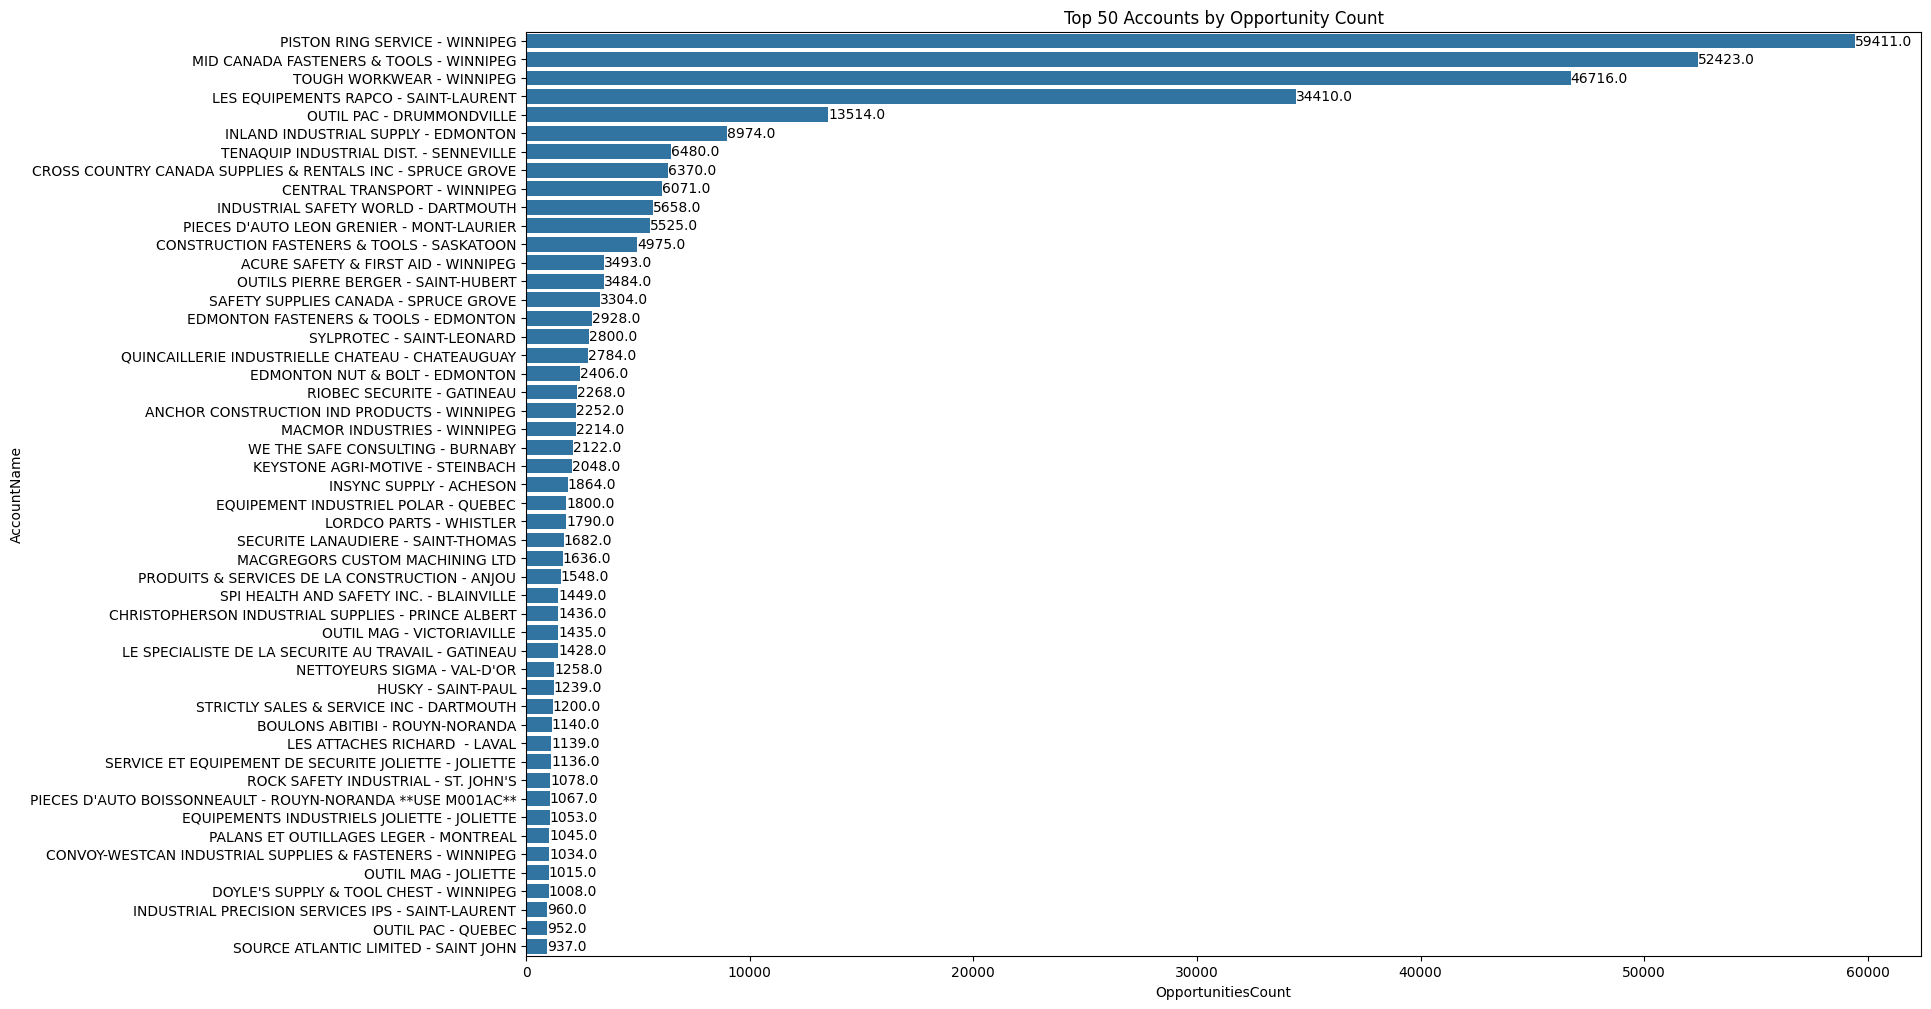

In [50]:
# Group by AccountName and sum OpportunitiesCount, then get top 50
top_50_accounts = df.groupby('AccountName')['OpportunitiesCount'].sum().nlargest(50).reset_index()

# Plot top 50 accounts by opportunity count
plt.figure(figsize=(18, 12))
sns.barplot(data=top_50_accounts, x='OpportunitiesCount', y='AccountName', orient='h')
for i, value in enumerate(top_50_accounts['OpportunitiesCount']):
    plt.text(value, i, f'{value}', va='center')
plt.title('Top 50 Accounts by Opportunity Count')
plt.show()


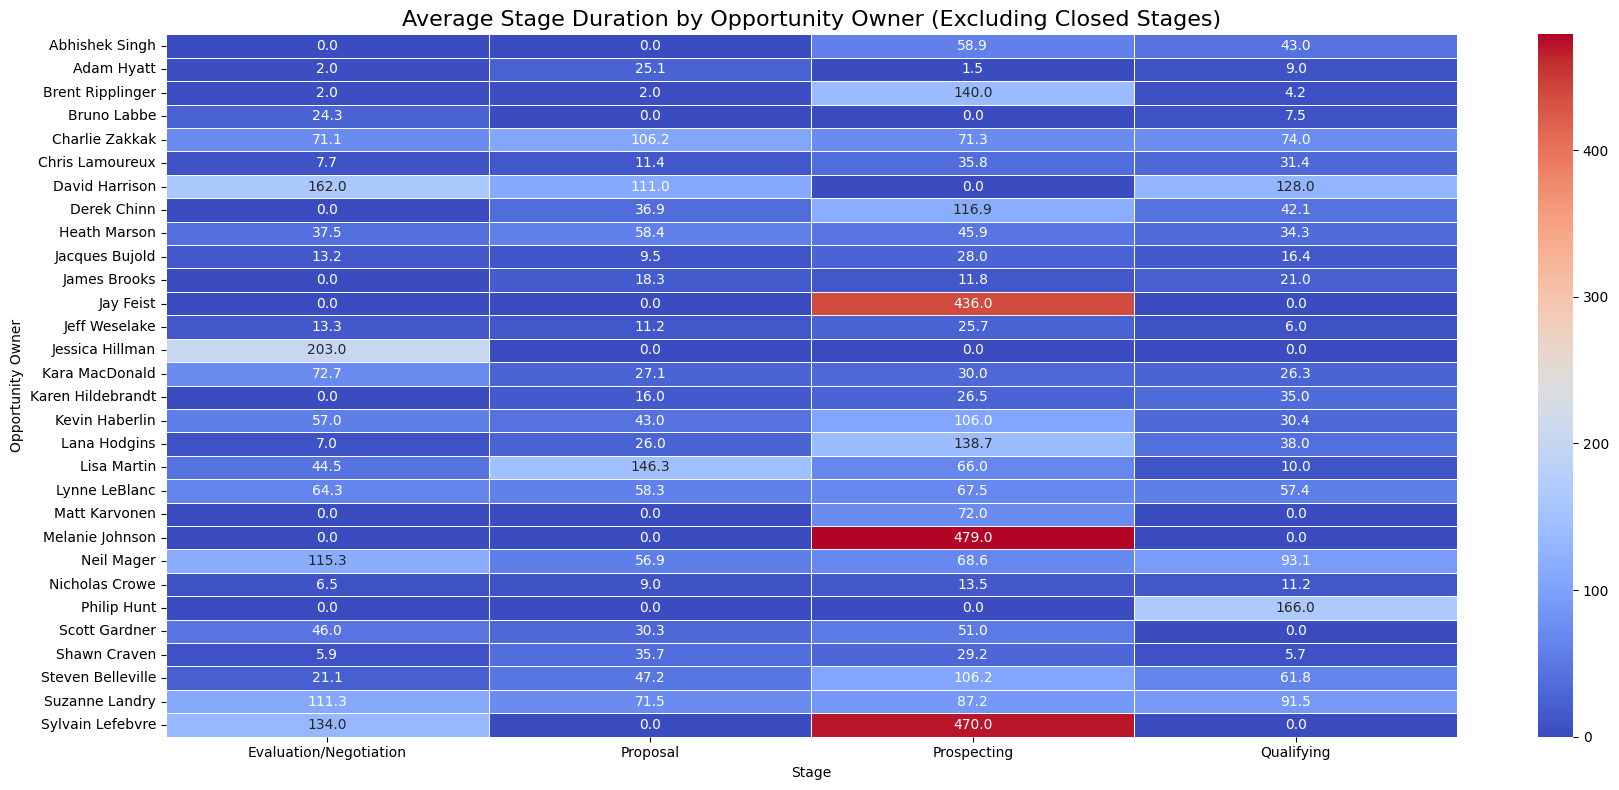

In [51]:
# Exclude Closed Won and Closed Lost stages
open_stages = df[~df['Stage'].isin(['Closed Won', 'Closed Lost'])]

# Group by OpportunityOwner and Stage, and calculate the average StageDuration
avg_stage_duration_owner = open_stages.groupby(['OpportunityOwner', 'Stage'])['StageDuration'].mean().reset_index()

# Create a pivot table for heatmap visualization
avg_stage_duration_pivot = avg_stage_duration_owner.pivot_table(values='StageDuration', index='OpportunityOwner', columns='Stage', fill_value=0)

# Plot a heatmap for the average stage duration by each opportunity owner
plt.figure(figsize=(18, 8))
sns.heatmap(avg_stage_duration_pivot, annot=True, fmt='.1f', cmap="coolwarm", linewidths=0.5)

plt.title('Average Stage Duration by Opportunity Owner (Excluding Closed Stages)', fontsize=16)
plt.xlabel('Stage')
plt.ylabel('Opportunity Owner')

plt.tight_layout()
plt.show()


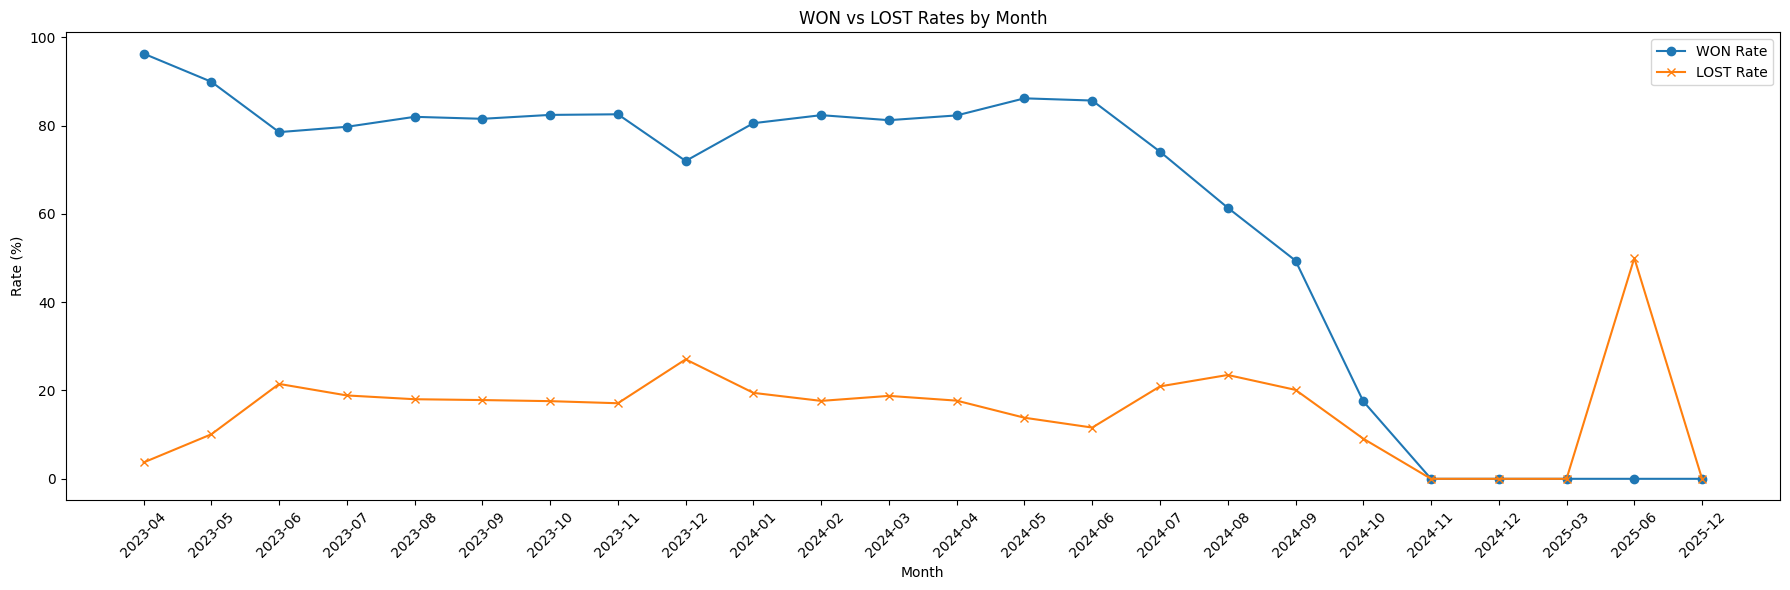

In [52]:
# Convert CloseDate to datetime if necessary
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Group by month for WON and LOST opportunities, and convert periods to strings
won_by_month = df[df['Stage'] == 'Closed Won'].groupby(df['CloseDate'].dt.to_period('M').astype(str)).size()
lost_by_month = df[df['Stage'] == 'Closed Lost'].groupby(df['CloseDate'].dt.to_period('M').astype(str)).size()
total_by_month = df.groupby(df['CloseDate'].dt.to_period('M').astype(str)).size()

# Reindex to ensure all months are represented
won_by_month = won_by_month.reindex(total_by_month.index, fill_value=0)
lost_by_month = lost_by_month.reindex(total_by_month.index, fill_value=0)

# Calculate WON and LOST rates
won_rate_by_month = (won_by_month / total_by_month) * 100
lost_rate_by_month = (lost_by_month / total_by_month) * 100

# Plot WON and LOST rates
plt.figure(figsize=(18, 6))
plt.plot(won_rate_by_month.index, won_rate_by_month, label='WON Rate', marker='o')
plt.plot(lost_rate_by_month.index, lost_rate_by_month, label='LOST Rate', marker='x')
plt.title('WON vs LOST Rates by Month')
plt.ylabel('Rate (%)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


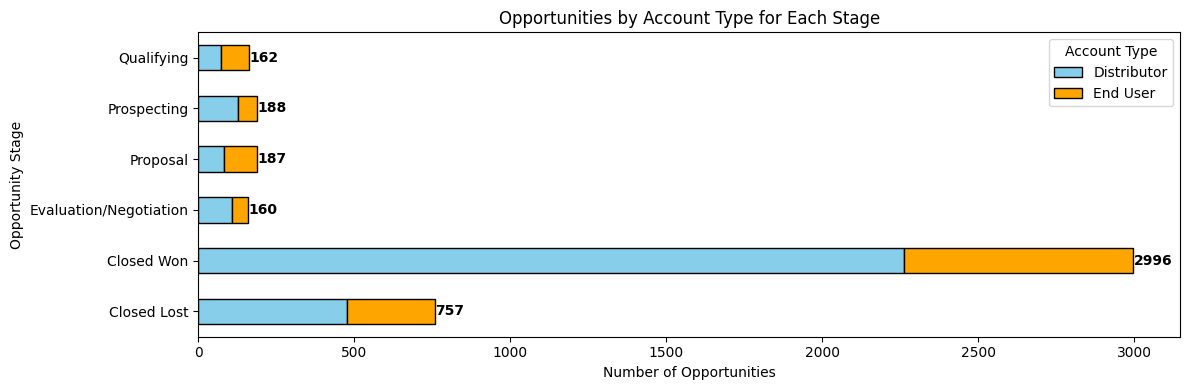

In [53]:
# Group by Stage and Type (Distributor, End User), count the number of opportunities
opportunity_counts = df.groupby(['Stage', 'Type']).size().unstack(fill_value=0)

# Create a larger figure for better readability
plt.figure(figsize=(12, 4))

# Plot a stacked horizontal bar chart to represent the number of opportunities by stage and type
ax = opportunity_counts.plot(kind='barh', stacked=True, ax=plt.gca(), color=['skyblue', 'orange'], edgecolor='black')

# Add title and labels
plt.title('Opportunities by Account Type for Each Stage')
plt.xlabel('Number of Opportunities')
plt.ylabel('Opportunity Stage')

# Add a legend to identify the account types
plt.legend(title='Account Type', loc='upper right')

# Add total numbers to the end of each bar
for index, bar_data in enumerate(opportunity_counts.iterrows()):
    total_count = sum(bar_data[1])
    ax.text(total_count + 1, index, f'{total_count}', va='center', fontweight='bold')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


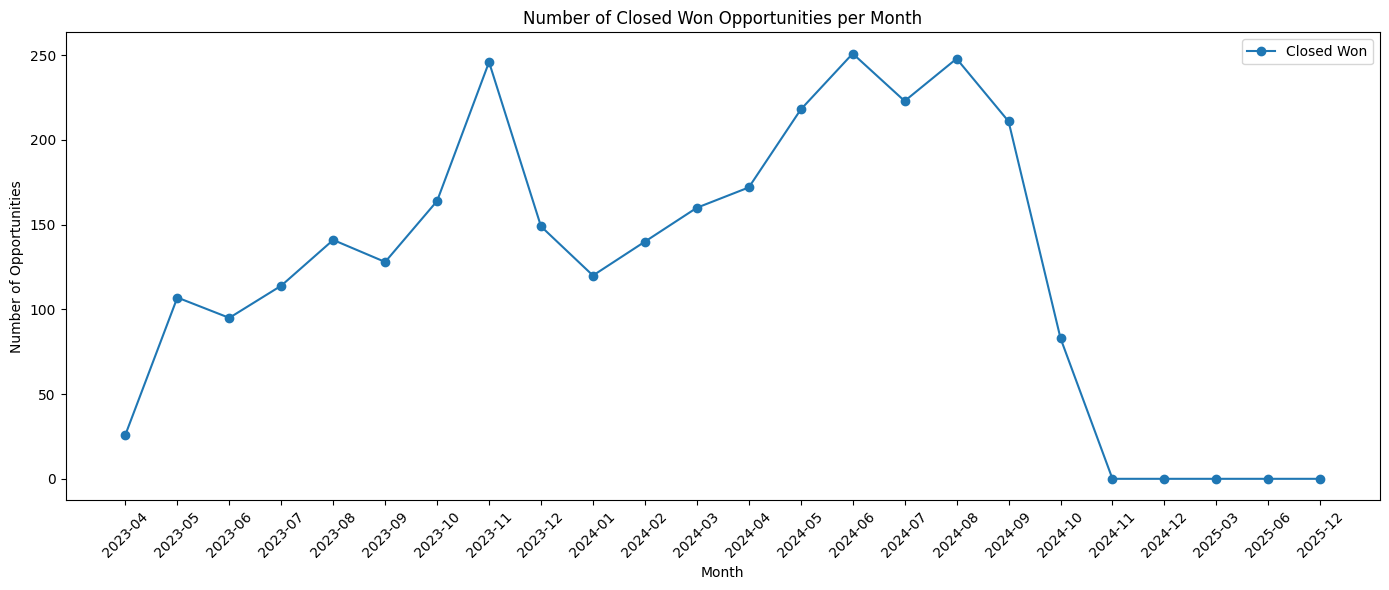

In [54]:
# TOTAL NUMBER OF CLOSED won stages per month
# Filter for Closed Won opportunities
closed_won_df = df[df['Stage'] == 'Closed Won']

# Group by the month of CloseDate and count the number of opportunities
monthly_closed_won = closed_won_df.groupby(closed_won_df['CloseDate'].dt.to_period('M')).size()

# Reindex to ensure all months are represented
monthly_closed_won = monthly_closed_won.reindex(total_by_month.index, fill_value=0)

# Plot the number of Closed Won opportunities per month
plt.figure(figsize=(14, 6))
plt.plot(monthly_closed_won.index, monthly_closed_won, label='Closed Won', marker='o')
plt.title('Number of Closed Won Opportunities per Month')
plt.ylabel('Number of Opportunities')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

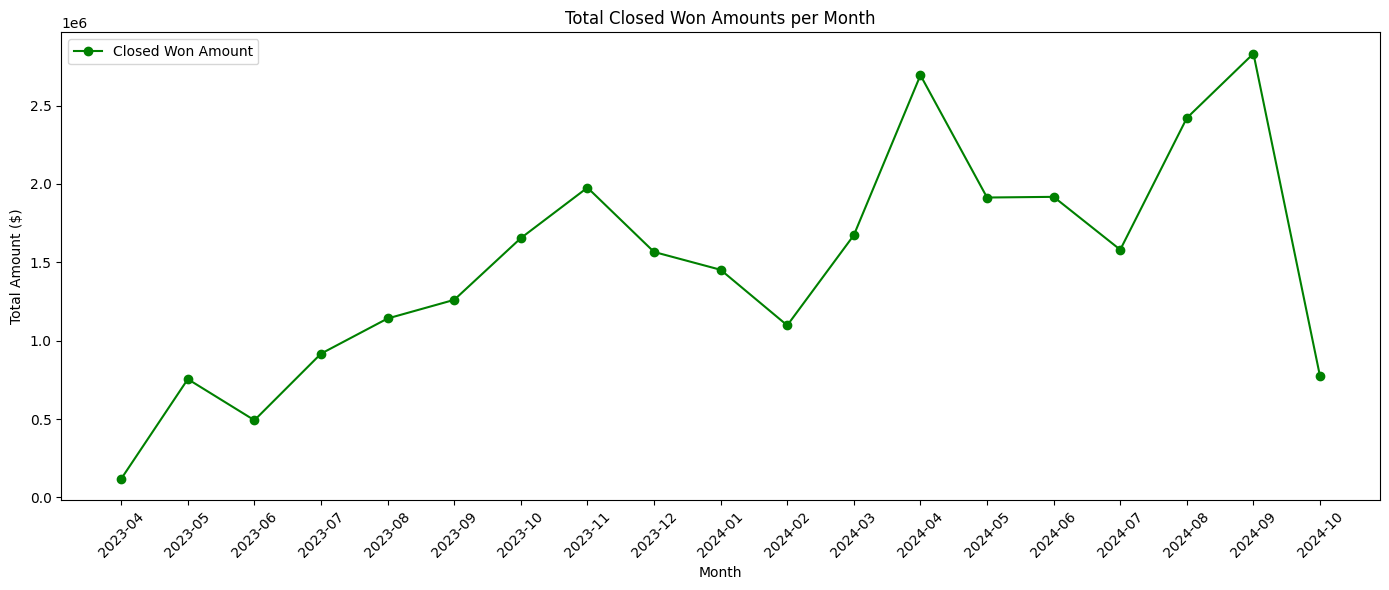

In [55]:
# Ensure CloseDate is in datetime format if necessary
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Closed Won opportunities
closed_won_df = df[df['Stage'] == 'Closed Won']

# Group by the month of CloseDate and sum the total Amount for Closed Won
monthly_closed_won_amount = closed_won_df.groupby(closed_won_df['CloseDate'].dt.to_period('M'))['Amount'].sum()

# Generate the full range of months
all_months = pd.period_range(start=closed_won_df['CloseDate'].min().to_period('M'), end=closed_won_df['CloseDate'].max().to_period('M'), freq='M')

# Reindex to ensure all months are represented, filling missing values with 0
monthly_closed_won_amount = monthly_closed_won_amount.reindex(all_months, fill_value=0)

# Plot the total Closed Won amounts per month
plt.figure(figsize=(14, 6))
plt.plot(monthly_closed_won_amount.index.strftime('%Y-%m'), monthly_closed_won_amount, label='Closed Won Amount', marker='o', color='green')
plt.title('Total Closed Won Amounts per Month')
plt.ylabel('Total Amount ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


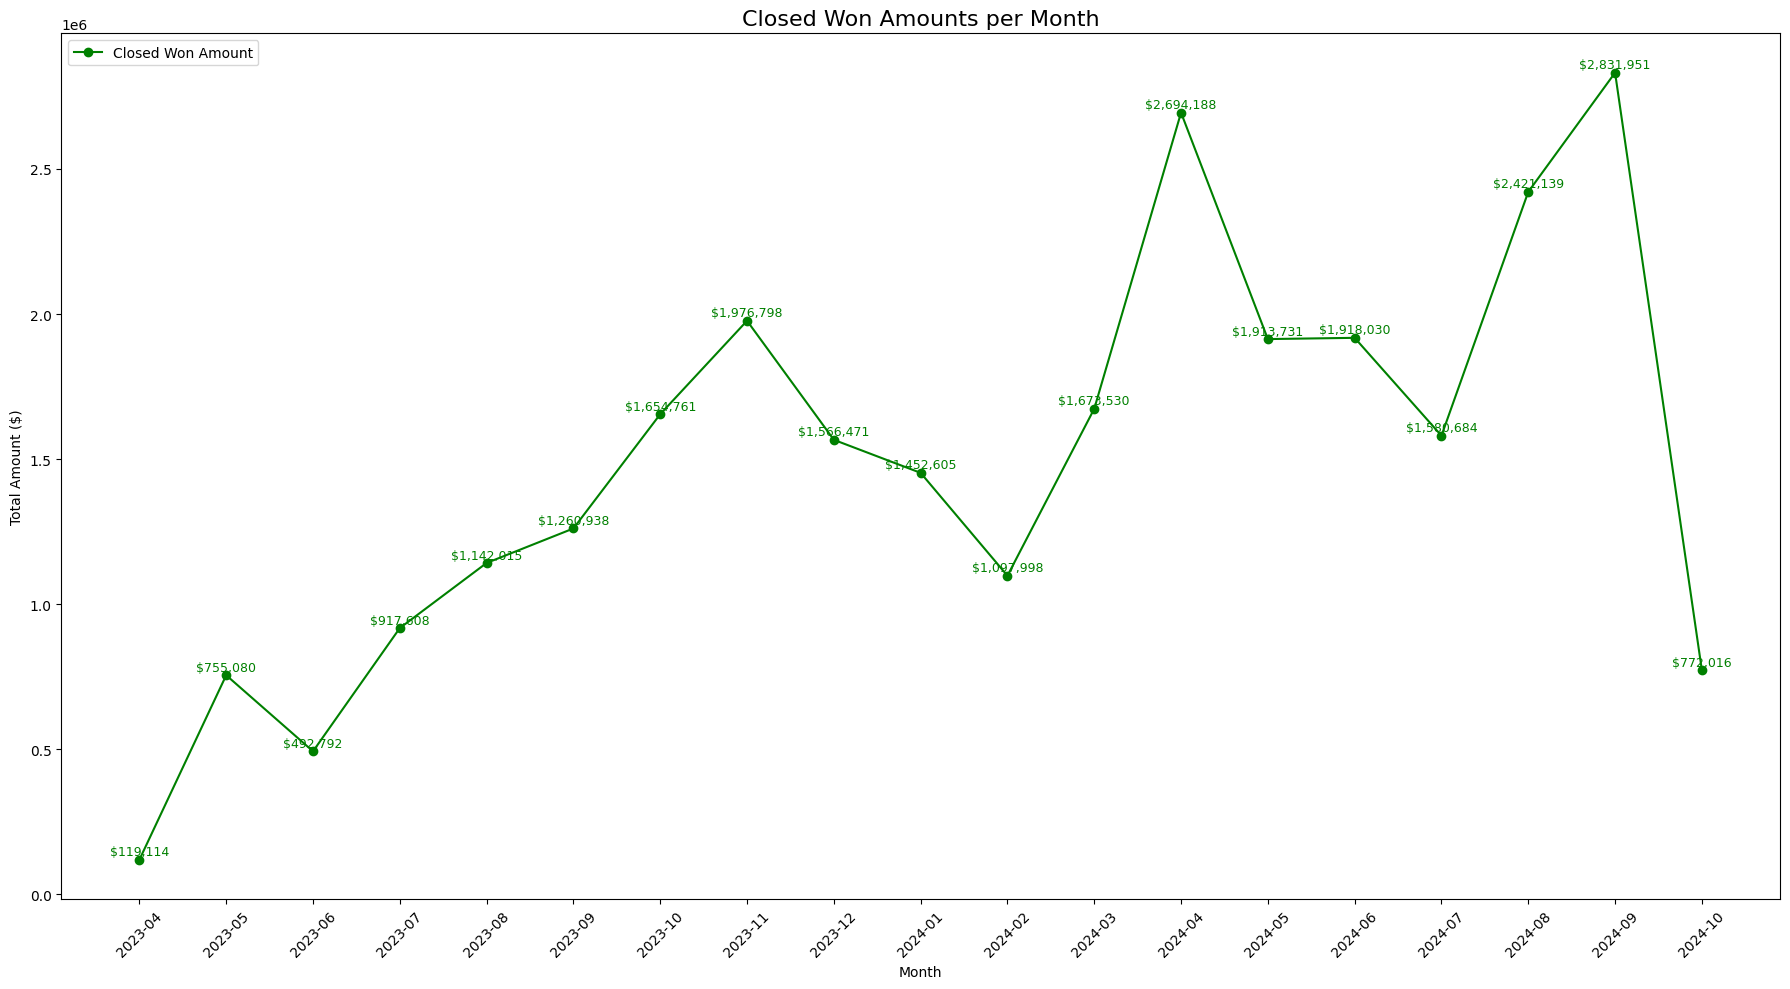

In [56]:
# Ensure CloseDate is in datetime format if necessary
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Closed Won opportunities
closed_won_df = df[df['Stage'] == 'Closed Won']

# Group by the month of CloseDate and sum the total Amount for Closed Won
monthly_closed_won_amount = closed_won_df.groupby(closed_won_df['CloseDate'].dt.to_period('M'))['Amount'].sum()

# Generate the full range of months
all_months = pd.period_range(start=closed_won_df['CloseDate'].min().to_period('M'), end=closed_won_df['CloseDate'].max().to_period('M'), freq='M')

# Reindex to ensure all months are represented, filling missing values with 0
monthly_closed_won_amount = monthly_closed_won_amount.reindex(all_months, fill_value=0)

# Create a larger figure size
plt.figure(figsize=(18, 10))

# Plot Closed Won amounts per month
plt.plot(monthly_closed_won_amount.index.strftime('%Y-%m'), monthly_closed_won_amount, label='Closed Won Amount', marker='o', color='green')

# Annotate the Closed Won amounts
for i, value in enumerate(monthly_closed_won_amount):
    plt.text(i, value + 5000, f'${value:,.0f}', ha='center', va='bottom', fontsize=9, color='green')

# Add title, labels, and legend
plt.title('Closed Won Amounts per Month', fontsize=16)
plt.ylabel('Total Amount ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


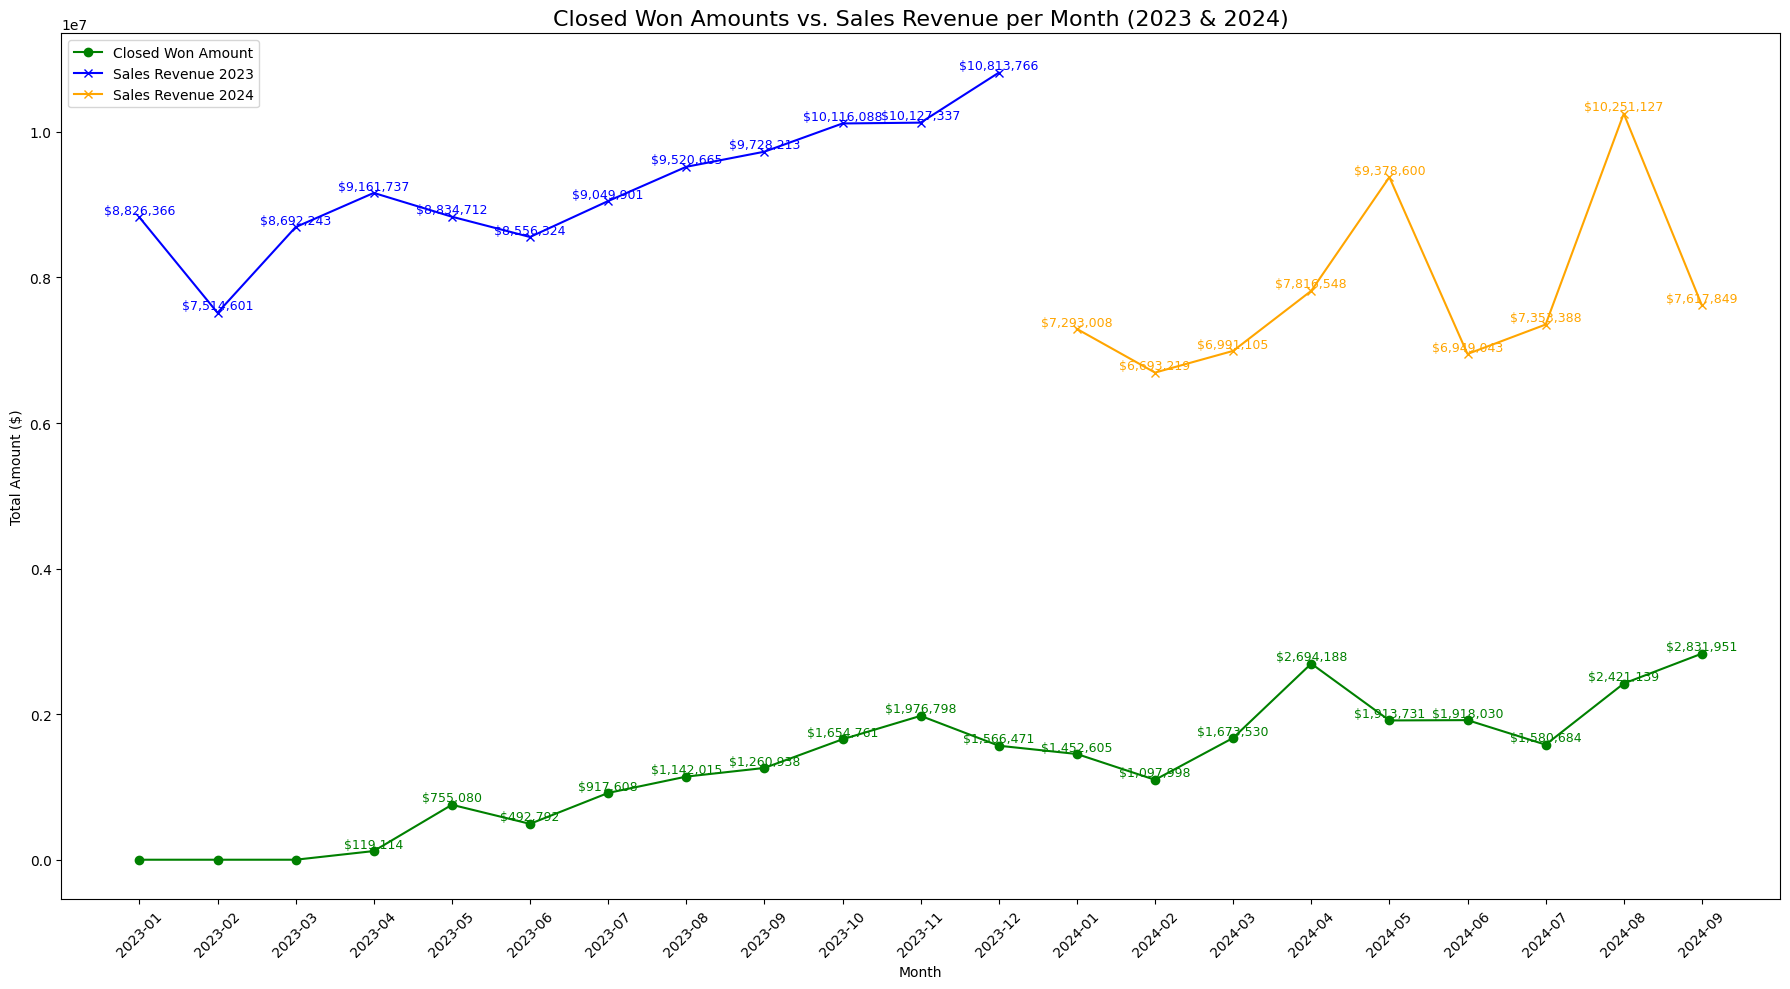

In [57]:
# Ensure CloseDate is in datetime format if necessary
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Closed Won opportunities
closed_won_df = df[df['Stage'] == 'Closed Won']

# Group by the month of CloseDate and sum the total Amount for Closed Won
monthly_closed_won_amount = closed_won_df.groupby(closed_won_df['CloseDate'].dt.to_period('M'))['Amount'].sum()

# Generate the full range of months starting from January 2023
all_months = pd.period_range(start='2023-01', end='2024-09', freq='M')  # Exclude October 2024 and later

# Reindex Closed Won data to ensure all months starting from January 2023 are represented, filling missing values with 0
monthly_closed_won_amount = monthly_closed_won_amount.reindex(all_months, fill_value=0)

# Prepare 2023 sales revenue data
SWX2023Revenuedf_melted = SWX2023Revenuedf.melt(id_vars=['BusinessUnit'], var_name='Month', value_name='Revenue2023')

# Prepare 2024 sales revenue data
SWX2024Revenuedf_melted = SWX2024Revenuedf.melt(id_vars=['BusinessUnit'], var_name='Month', value_name='Revenue2024')

# Convert Month to Period for 2023 and 2024
SWX2023Revenuedf_melted['Month'] = pd.to_datetime(SWX2023Revenuedf_melted['Month'], format='%b-%y').dt.to_period('M')
SWX2024Revenuedf_melted['Month'] = pd.to_datetime(SWX2024Revenuedf_melted['Month'], format='%b-%y').dt.to_period('M')

# Filter the 2024 revenue data to include only months with non-zero revenue (up to September 2024)
monthly_revenue_2023 = SWX2023Revenuedf_melted.groupby('Month')['Revenue2023'].sum()
monthly_revenue_2024 = SWX2024Revenuedf_melted.groupby('Month')['Revenue2024'].sum().loc[:'2024-09']  # Limit to September 2024

# Create a larger figure size
plt.figure(figsize=(18, 10))

# Plot Closed Won amounts per month starting from January 2023
plt.plot(monthly_closed_won_amount.index.strftime('%Y-%m'), monthly_closed_won_amount, label='Closed Won Amount', marker='o', color='green')

# Plot 2023 sales revenue per month
plt.plot(monthly_revenue_2023.index.strftime('%Y-%m'), monthly_revenue_2023, label='Sales Revenue 2023', marker='x', color='blue')

# Plot 2024 sales revenue per month (excluding October and later)
plt.plot(monthly_revenue_2024.index.strftime('%Y-%m'), monthly_revenue_2024, label='Sales Revenue 2024', marker='x', color='orange')

# Annotate the Closed Won amounts
for i, value in enumerate(monthly_closed_won_amount):
    if value > 0:  # Only annotate months with actual values
        plt.text(i, value + 5000, f'${value:,.0f}', ha='center', va='bottom', fontsize=9, color='green')

# Annotate the Sales Revenue 2023 amounts
for i, value in enumerate(monthly_revenue_2023):
    plt.text(i, value + 5000, f'${value:,.0f}', ha='center', va='bottom', fontsize=9, color='blue')

# Annotate the Sales Revenue 2024 amounts
for i, value in enumerate(monthly_revenue_2024):
    plt.text(i + len(monthly_revenue_2023), value + 5000, f'${value:,.0f}', ha='center', va='bottom', fontsize=9, color='orange')

# Add title, labels, and legend
plt.title('Closed Won Amounts vs. Sales Revenue per Month (2023 & 2024)', fontsize=16)
plt.ylabel('Total Amount ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


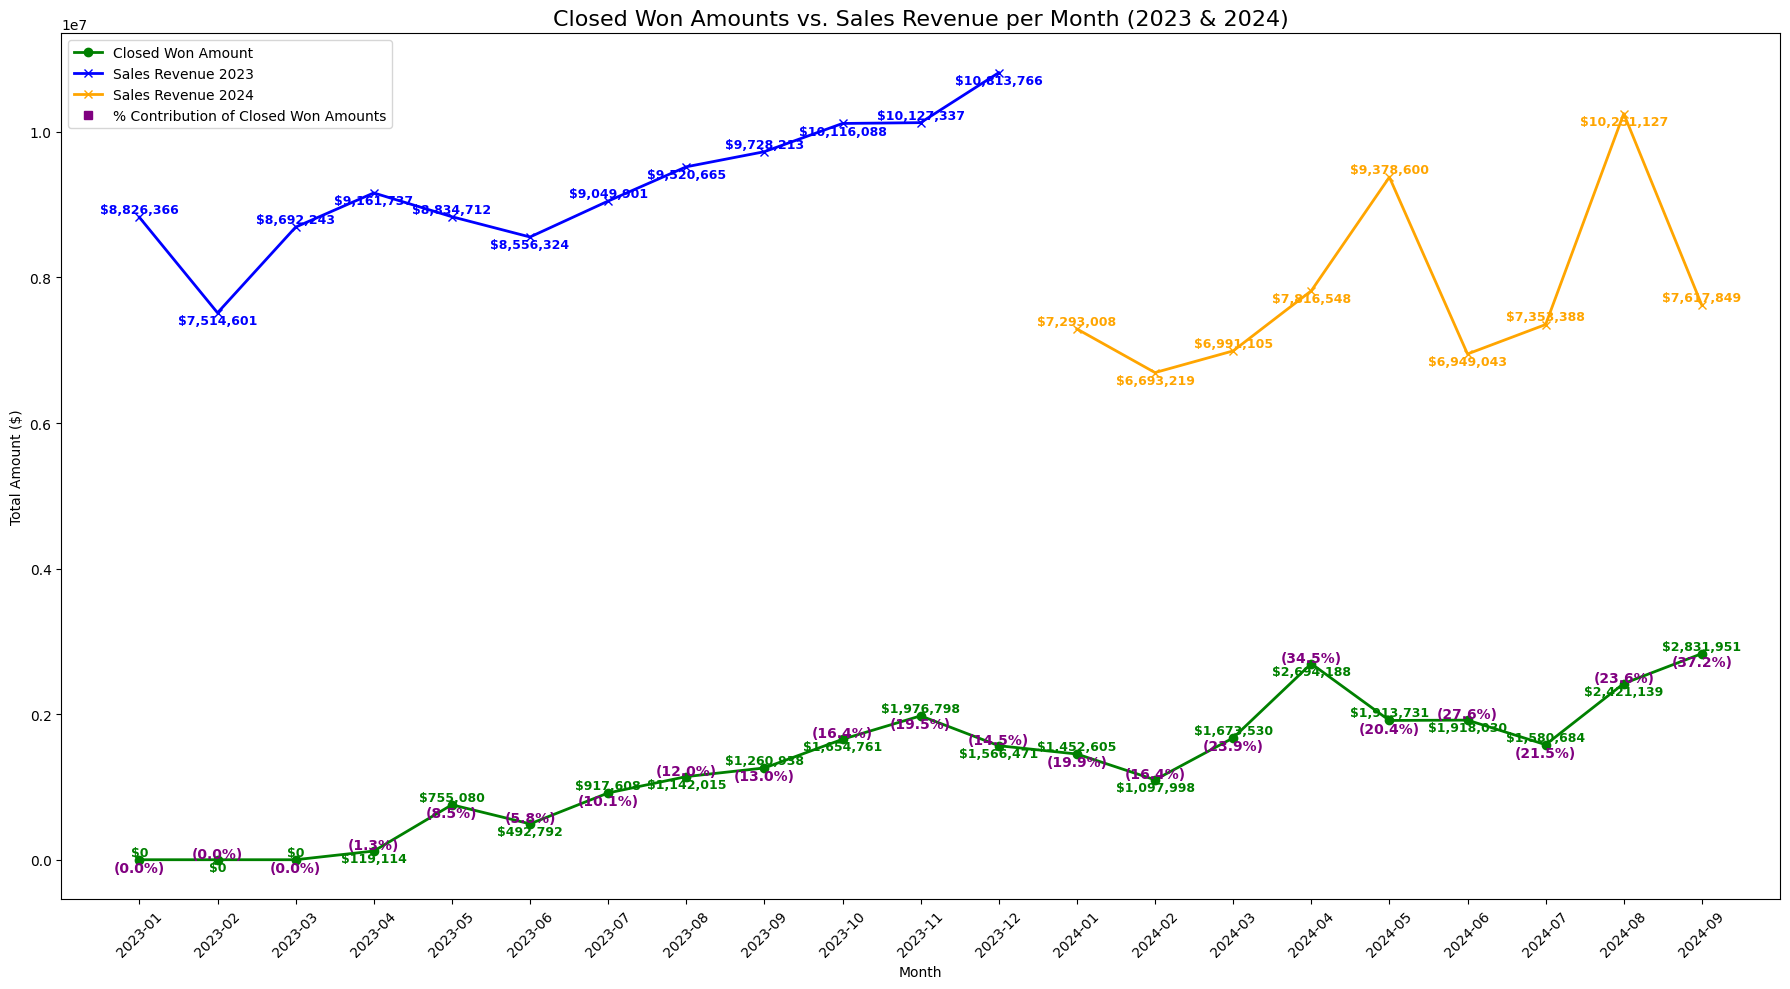

In [64]:
# Ensure CloseDate is in datetime format if necessary
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Closed Won opportunities
closed_won_df = df[df['Stage'] == 'Closed Won']

# Group by the month of CloseDate and sum the total Amount for Closed Won
monthly_closed_won_amount = closed_won_df.groupby(closed_won_df['CloseDate'].dt.to_period('M'))['Amount'].sum()

# Generate the full range of months starting from January 2023 to September 2024
all_months = pd.period_range(start='2023-01', end='2024-09', freq='M')

# Reindex Closed Won data to ensure all months are represented, filling missing values with 0
monthly_closed_won_amount = monthly_closed_won_amount.reindex(all_months, fill_value=0)

# Prepare 2023 sales revenue data
SWX2023Revenuedf_melted = SWX2023Revenuedf.melt(id_vars=['BusinessUnit'], var_name='Month', value_name='Revenue2023')

# Prepare 2024 sales revenue data
SWX2024Revenuedf_melted = SWX2024Revenuedf.melt(id_vars=['BusinessUnit'], var_name='Month', value_name='Revenue2024')

# Convert Month to Period for 2023 and 2024
SWX2023Revenuedf_melted['Month'] = pd.to_datetime(SWX2023Revenuedf_melted['Month']).dt.to_period('M')
SWX2024Revenuedf_melted['Month'] = pd.to_datetime(SWX2024Revenuedf_melted['Month']).dt.to_period('M')

# Sum monthly revenue data for 2023 and 2024, and limit 2024 to September
monthly_revenue_2023 = SWX2023Revenuedf_melted.groupby('Month')['Revenue2023'].sum()
monthly_revenue_2024 = SWX2024Revenuedf_melted.groupby('Month')['Revenue2024'].sum().loc[:'2024-09']

# Create a larger figure size
plt.figure(figsize=(18, 10))

# Plot Closed Won amounts per month
plt.plot(monthly_closed_won_amount.index.strftime('%Y-%m'), 
         monthly_closed_won_amount, label='Closed Won Amount', marker='o', color='green', linewidth=2)

# Plot 2023 sales revenue per month
plt.plot(monthly_revenue_2023.index.strftime('%Y-%m'), 
         monthly_revenue_2023, label='Sales Revenue 2023', marker='x', color='blue', linewidth=2)

# Plot 2024 sales revenue per month (limited to September)
plt.plot(monthly_revenue_2024.index.strftime('%Y-%m'), 
         monthly_revenue_2024, label='Sales Revenue 2024', marker='x', color='orange', linewidth=2)

# Annotate Closed Won amounts with value and percentage contribution
for i, (won_value, revenue_2023, revenue_2024) in enumerate(zip(
        monthly_closed_won_amount, 
        monthly_revenue_2023.reindex(all_months, fill_value=0), 
        monthly_revenue_2024.reindex(all_months, fill_value=0))):
    total_revenue = revenue_2023 + revenue_2024
    percentage = (won_value / total_revenue * 100) if total_revenue != 0 else 0
    va_position = 'bottom' if i % 2 == 0 else 'top'
    plt.text(i, won_value + (15000 if va_position == 'bottom' else -15000), 
             f'${won_value:,.0f}', ha='center', va=va_position, fontsize=9, color='green', fontweight='bold')
    plt.text(i, won_value - (15000 if va_position == 'top' else 20000), 
             f'({percentage:.1f}%)', ha='center', va='top' if va_position == 'bottom' else 'bottom', 
             fontsize=10, color='purple', fontweight='bold')

# Annotate Sales Revenue 2023
for i, value in enumerate(monthly_revenue_2023):
    va_position = 'bottom' if i % 2 == 0 else 'top'
    plt.text(i, value + (15000 if va_position == 'bottom' else -15000), 
             f'${value:,.0f}', ha='center', va=va_position, fontsize=9, color='blue', fontweight='bold')

# Annotate Sales Revenue 2024
for i, value in enumerate(monthly_revenue_2024):
    va_position = 'bottom' if i % 2 == 0 else 'top'
    plt.text(i + len(monthly_revenue_2023), value + (15000 if va_position == 'bottom' else -15000), 
             f'${value:,.0f}', ha='center', va=va_position, fontsize=9, color='orange', fontweight='bold')

# Add title, labels, and updated legend
plt.title('Closed Won Amounts vs. Sales Revenue per Month (2023 & 2024)', fontsize=16)
plt.ylabel('Total Amount ($)')
plt.xlabel('Month')
plt.xticks(ticks=range(len(all_months)), labels=all_months.strftime('%Y-%m'), rotation=45)

# Manually create legend entries with contribution explanation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', marker='o', linewidth=2, label='Closed Won Amount'),
    Line2D([0], [0], color='blue', marker='x', linewidth=2, label='Sales Revenue 2023'),
    Line2D([0], [0], color='orange', marker='x', linewidth=2, label='Sales Revenue 2024'),
    Line2D([0], [0], color='purple', marker='s', linewidth=0, label='% Contribution of Closed Won Amounts')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


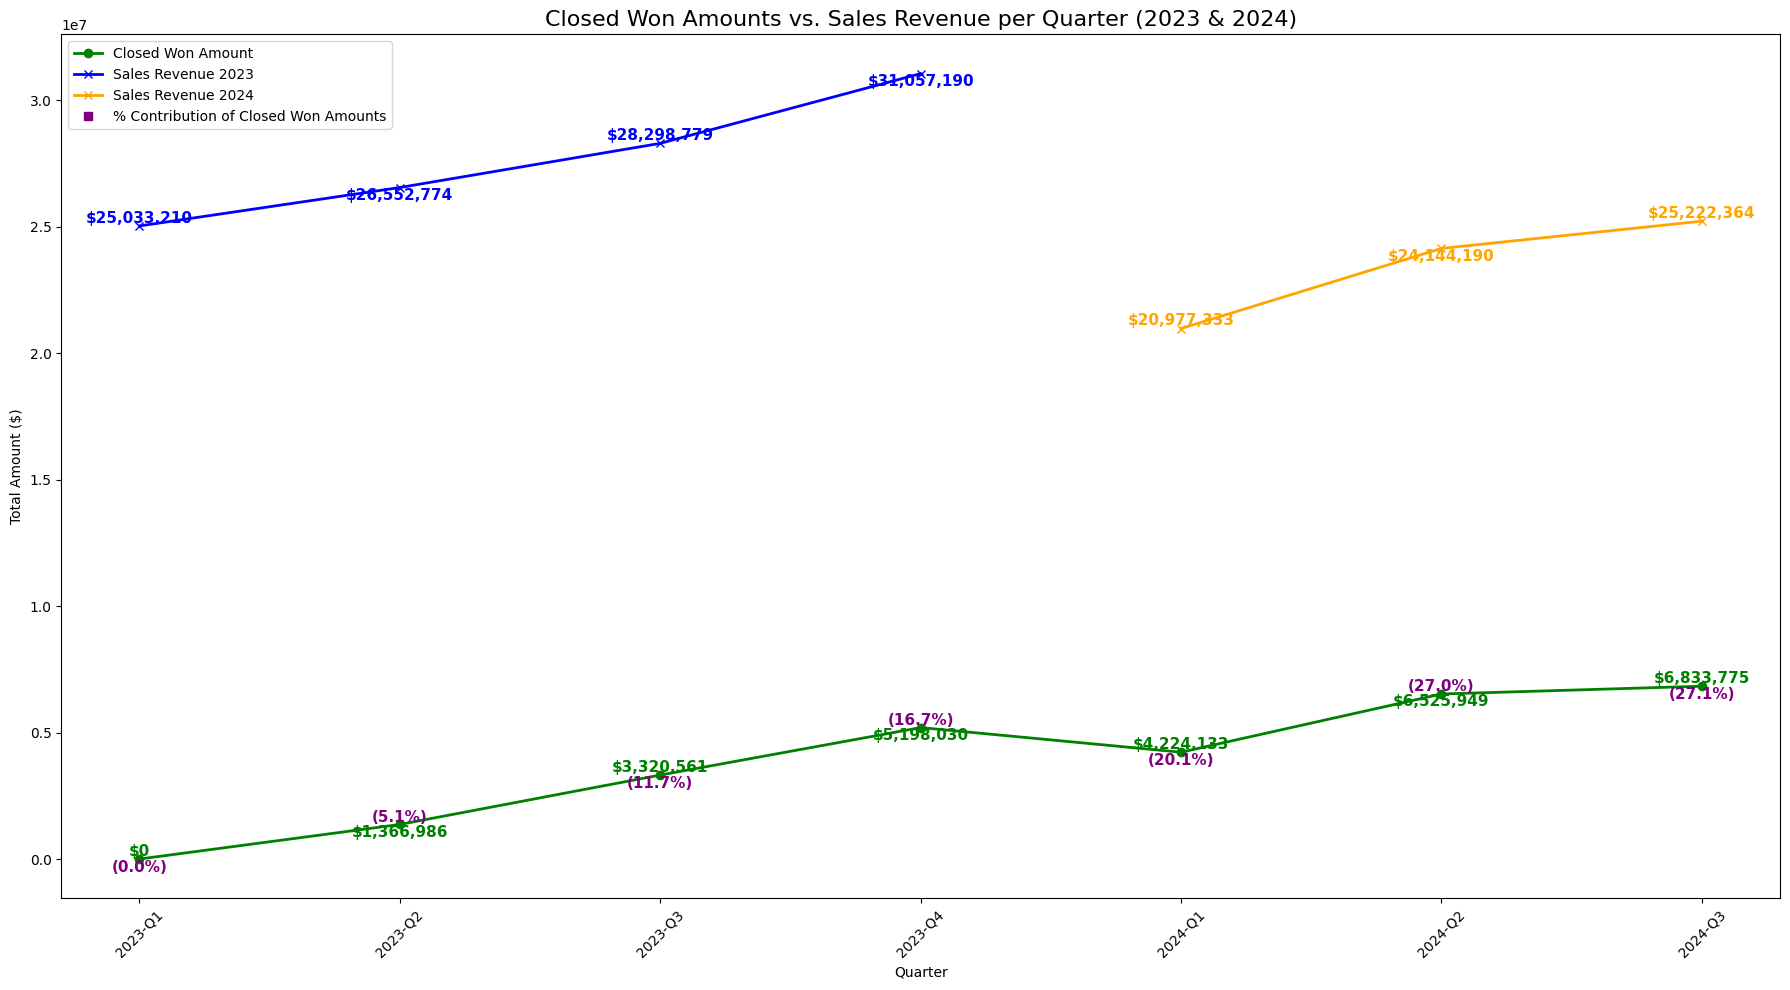

In [66]:
# Ensure CloseDate is in datetime format if necessary
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Filter for Closed Won opportunities
closed_won_df = df[df['Stage'] == 'Closed Won']

# Group by the quarter of CloseDate and sum the total Amount for Closed Won
quarterly_closed_won_amount = closed_won_df.groupby(closed_won_df['CloseDate'].dt.to_period('Q'))['Amount'].sum()

# Generate the full range of quarters from Q1 2023 to Q3 2024
all_quarters = pd.period_range(start='2023Q1', end='2024Q3', freq='Q')

# Reindex Closed Won data to ensure all quarters are represented, filling missing values with 0
quarterly_closed_won_amount = quarterly_closed_won_amount.reindex(all_quarters, fill_value=0)

# Prepare 2023 and 2024 revenue data
SWX2023Revenuedf_melted = SWX2023Revenuedf.melt(id_vars=['BusinessUnit'], var_name='Quarter', value_name='Revenue2023')
SWX2024Revenuedf_melted = SWX2024Revenuedf.melt(id_vars=['BusinessUnit'], var_name='Quarter', value_name='Revenue2024')

# Convert Quarter to Period for 2023 and 2024
SWX2023Revenuedf_melted['Quarter'] = pd.to_datetime(SWX2023Revenuedf_melted['Quarter']).dt.to_period('Q')
SWX2024Revenuedf_melted['Quarter'] = pd.to_datetime(SWX2024Revenuedf_melted['Quarter']).dt.to_period('Q')

# Sum revenue data by quarter
quarterly_revenue_2023 = SWX2023Revenuedf_melted.groupby('Quarter')['Revenue2023'].sum()
quarterly_revenue_2024 = SWX2024Revenuedf_melted.groupby('Quarter')['Revenue2024'].sum().loc[:'2024Q3']

# Create a larger figure size
plt.figure(figsize=(18, 10))

# Plot Closed Won amounts per quarter
plt.plot(quarterly_closed_won_amount.index.strftime('%Y-Q%q'), 
         quarterly_closed_won_amount, label='Closed Won Amount', marker='o', color='green', linewidth=2)

# Plot 2023 and 2024 sales revenue per quarter
plt.plot(quarterly_revenue_2023.index.strftime('%Y-Q%q'), 
         quarterly_revenue_2023, label='Sales Revenue 2023', marker='x', color='blue', linewidth=2)

plt.plot(quarterly_revenue_2024.index.strftime('%Y-Q%q'), 
         quarterly_revenue_2024, label='Sales Revenue 2024', marker='x', color='orange', linewidth=2)

# Annotate Closed Won amounts with value and percentage contribution
for i, (won_value, revenue_2023, revenue_2024) in enumerate(zip(
        quarterly_closed_won_amount, 
        quarterly_revenue_2023.reindex(all_quarters, fill_value=0), 
        quarterly_revenue_2024.reindex(all_quarters, fill_value=0))):
    total_revenue = revenue_2023 + revenue_2024
    percentage = (won_value / total_revenue * 100) if total_revenue != 0 else 0
    va_position = 'bottom' if i % 2 == 0 else 'top'
    plt.text(i, won_value + (15000 if va_position == 'bottom' else -15000), 
             f'${won_value:,.0f}', ha='center', va=va_position, fontsize=11, color='green', fontweight='bold')
    plt.text(i, won_value - (15000 if va_position == 'top' else 20000), 
             f'({percentage:.1f}%)', ha='center', va='top' if va_position == 'bottom' else 'bottom', 
             fontsize=11, color='purple', fontweight='bold')

# Annotate Sales Revenue 2023
for i, value in enumerate(quarterly_revenue_2023):
    va_position = 'bottom' if i % 2 == 0 else 'top'
    plt.text(i, value + (15000 if va_position == 'bottom' else -15000), 
             f'${value:,.0f}', ha='center', va=va_position, fontsize=11, color='blue', fontweight='bold')

# Annotate Sales Revenue 2024
for i, value in enumerate(quarterly_revenue_2024):
    va_position = 'bottom' if i % 2 == 0 else 'top'
    plt.text(i + len(quarterly_revenue_2023), value + (15000 if va_position == 'bottom' else -15000), 
             f'${value:,.0f}', ha='center', va=va_position, fontsize=11, color='orange', fontweight='bold')

# Add title, labels, and updated legend
plt.title('Closed Won Amounts vs. Sales Revenue per Quarter (2023 & 2024)', fontsize=16)
plt.ylabel('Total Amount ($)')
plt.xlabel('Quarter')
plt.xticks(ticks=range(len(all_quarters)), labels=all_quarters.strftime('%Y-Q%q'), rotation=45)

# Manually create legend entries with contribution explanation
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', marker='o', linewidth=2, label='Closed Won Amount'),
    Line2D([0], [0], color='blue', marker='x', linewidth=2, label='Sales Revenue 2023'),
    Line2D([0], [0], color='orange', marker='x', linewidth=2, label='Sales Revenue 2024'),
    Line2D([0], [0], color='purple', marker='s', linewidth=0, label='% Contribution of Closed Won Amounts')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


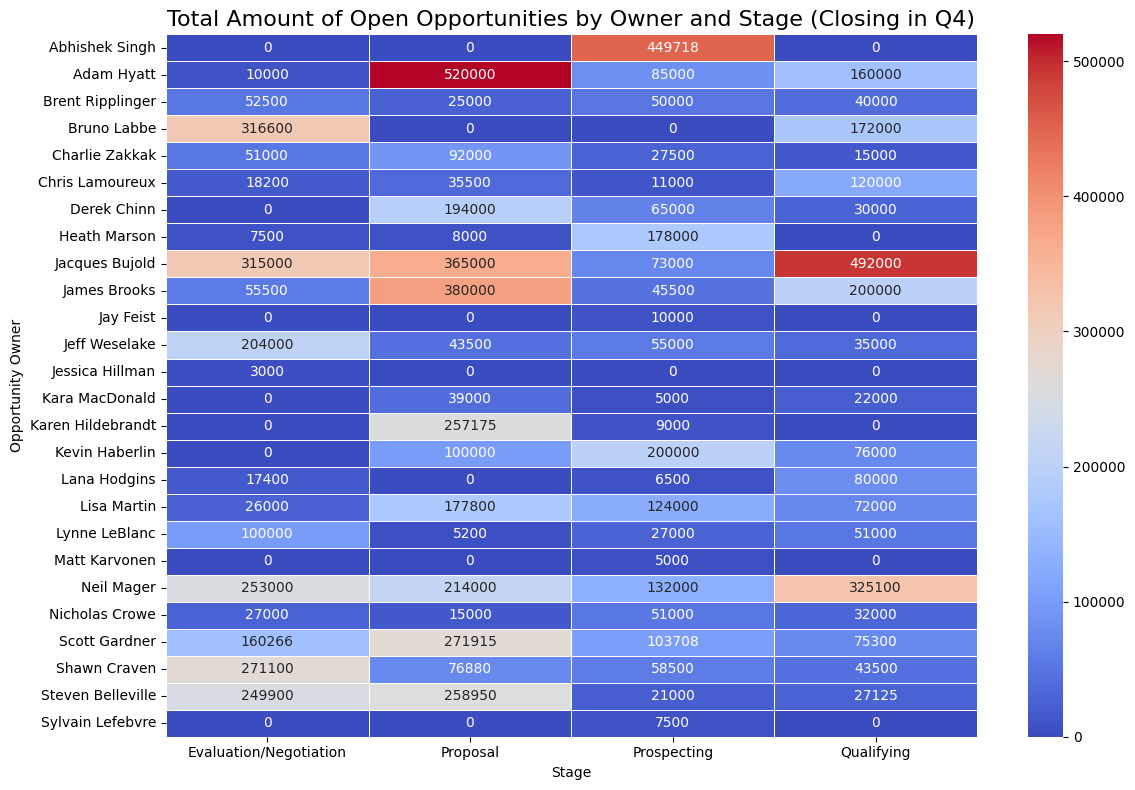

In [59]:
# Filter for Q4 opportunities that are not closed
q4_opps_open = df[(df['CloseDate'].dt.month >= 10) & (df['CloseDate'].dt.month <= 12) & (df['Stage'] != 'Closed Won') & (df['Stage'] != 'Closed Lost')]

# Group by OpportunityOwner and Stage, summing the total amount
q4_grouped = q4_opps_open.groupby(['OpportunityOwner', 'Stage'])['Amount'].sum().reset_index()

# Create a pivot table with owners as rows, stages as columns, and the total amounts
q4_pivot = q4_grouped.pivot(index='OpportunityOwner', columns='Stage', values='Amount').fillna(0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(q4_pivot, annot=True, fmt=".0f", cmap='coolwarm', linewidths=.5)

# Customizing the plot
plt.title('Total Amount of Open Opportunities by Owner and Stage (Closing in Q4)', fontsize=16)
plt.xlabel('Stage')
plt.ylabel('Opportunity Owner')

# Show the plot
plt.tight_layout()
plt.show()
